# <center> Traffic Sign Detection</center>

Traffic signs are important as they help the drivers to follow traffic rules and reduce the number of accidents on road. However, it is often very difficult for a driver to focus on the signs along with the other happenings on the road. In addition to this, traffic sign detection is also very important for the fast growing technology of automated driving and driverless cars.

In this notebook we use the [German Traffic Sign Recognition Benchmark](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign) dataset, which contains 43 traffic sign classes. We train a Convolutional Neural Network (CNN) to classify the signs and evaluate it on a held-out split.

Importing necessary libraries

In [ ]:
import sys
import numpy as np
import pandas as pd
import os
import importlib
import sys
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


Reading the Data

Firstly, we are setting the seeds in order to make the code reproductible

In [11]:
seed_value = 1 #set the seed for the data
random.seed(seed_value) #the seed for the random module
np.random.seed(seed_value) #this is the seed for NumPy functions
tf.random.set_seed(seed_value) # the samem but it is for TensorFlow

the function used to reset the seed for the models

In [12]:
from tensorflow.keras import backend as K
def reset_everything(seed=1):
    K.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


This code imports the .py file that the professor gave us to work on it (traffic_sign_load.py)

TASK 8: TRAFFIC SIGN RECOGNITION (with tqdm)
Classes    : 43
Loading data from folder structure...


Scanning class folders: 100%|██████████| 43/43 [00:00<00:00, 118.67it/s]



Total training images found: 39,209
Most common class     : Speed limit (50) (2250 imgs)
Least common class    : Speed limit (20) (210 imgs)

[Saved] eda_traffic.png


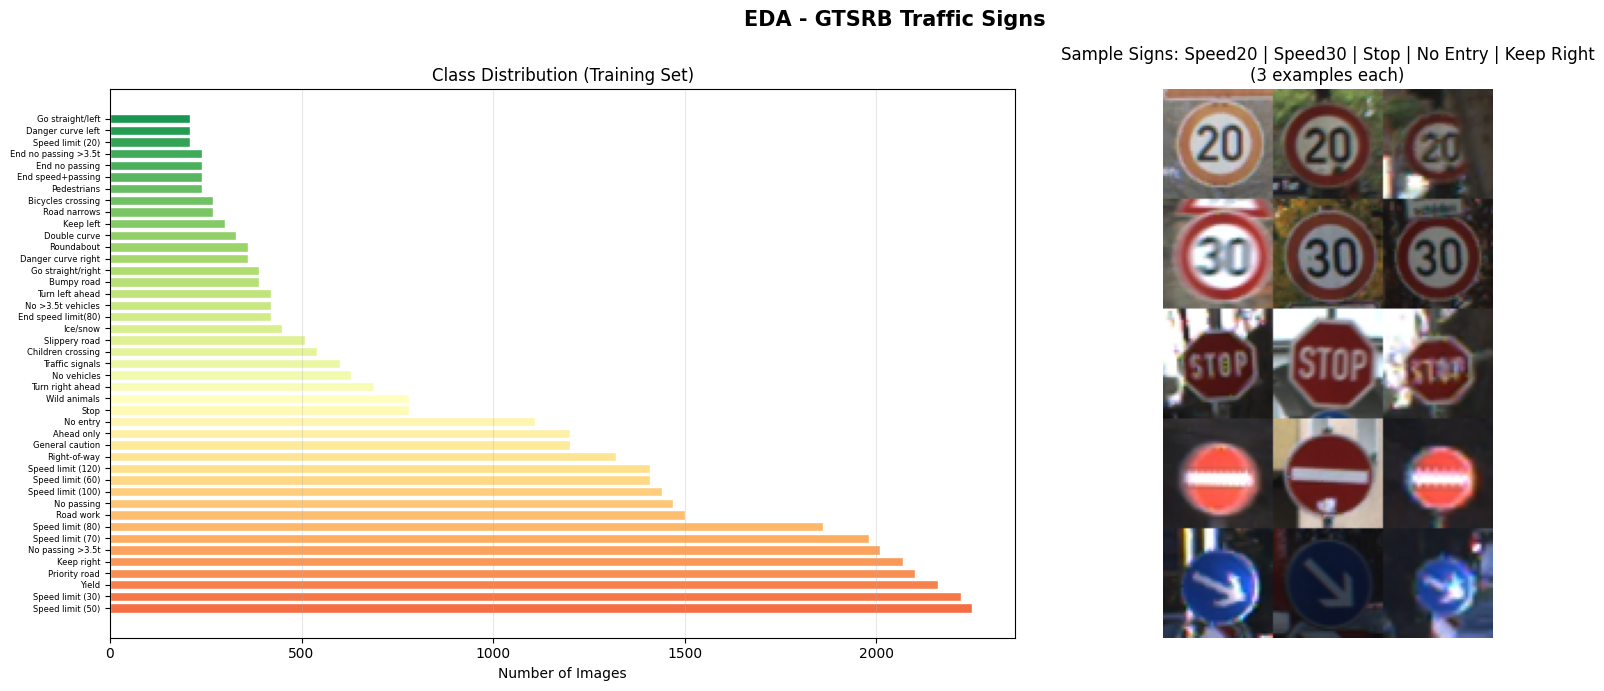

In [147]:
# this is the path to the folder that contains the file
project_path = "/Users/raresolteanu/Desktop/2026_Practical_Deep_learning_EIM12OB001/Individual_projects"
loader_path = os.path.join(project_path, "traffic_sign_load.py")

#  this is teh path to the GTSRB dataset folder
dataset_path = "/Users/raresolteanu/Desktop/2026_Practical_Deep_learning_EIM12OB001/archive-2"

# this makes the traffic_sign_load.py importable
if project_path not in sys.path:
    sys.path.append(project_path)

# this makes the dataset path available if the script uses this variable style
os.environ["GTSRB_DATA_PATH"] = dataset_path

# this line check that the files exist before importing
if not os.path.exists(loader_path):
    raise FileNotFoundError(f"Missing loader file: {loader_path}")

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Missing dataset folder: {dataset_path}")

import traffic_sign_load


In [ ]:
#project_path = os.getcwd() #this get me the corrent working director to save the folder where is the notebook
#dataset_path = os.path.join(project_path, 'archive-2') # this is merging the current projrct folder and archive2
#train_path = os.path.join(dataset_path, 'Train') #this builds the path to the traing images folder within the dataset
#loader_path = os.path.join(project_path, 'traffic_sign_load.py') #this builds the path to the .py files that we receive to open the data

The function used to import the datasets in the notebookm both train and test datasets

In [146]:
train_csv_path = os.path.join(dataset_path, "Train.csv")
test_csv_path = os.path.join(dataset_path, "Test.csv")
meta_csv_path = os.path.join(dataset_path, "Meta.csv")

required_paths = [
    os.path.join(dataset_path, "Train"),
    os.path.join(dataset_path, "Test"),
    train_csv_path,
    test_csv_path,
    meta_csv_path
]

for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing path: {path}")

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
meta_df = pd.read_csv(meta_csv_path)

print("Using dataset from:", dataset_path)
print("Train csv shape:", train_df.shape)
print("Test csv shape:", test_df.shape)
print("Meta csv shape:", meta_df.shape)


Using dataset from: /Users/raresolteanu/Desktop/2026_Practical_Deep_learning_EIM12OB001/archive-2
Train csv shape: (39209, 8)
Test csv shape: (12630, 8)
Meta csv shape: (43, 5)


This function complemnets the other one is better for the actual training pipeline because it loads images using Train.csv and Test.cs

In [ ]:
from PIL import Image

In [ ]:
def load_images_from_csv(df, dataset_root, image_size=(32, 32), show_progress_every=5000):
    data = np.empty((len(df), image_size[0], image_size[1], 3), dtype=np.uint8)
    labels = np.empty(len(df), dtype=np.int64)

    for i, row in enumerate(df.itertuples(index=False)):
        img_rel_path = str(row.Path).replace("\\", "/")
        img_path = os.path.join(dataset_root, img_rel_path)

        image = Image.open(img_path).convert("RGB")
        image = image.resize(image_size)

        data[i] = np.array(image, dtype=np.uint8)
        labels[i] = int(row.ClassId)

        if (i + 1) % show_progress_every == 0 or (i + 1) == len(df):
            print(f"Loaded {i + 1}/{len(df)} images")

    return data, labels

In [16]:
data_train, labels_train_full = load_images_from_csv(train_df, dataset_path, image_size=(32, 32))
data_test, labels_test = load_images_from_csv(test_df, dataset_path, image_size=(32, 32))


Loaded 5000/39209 images
Loaded 10000/39209 images
Loaded 15000/39209 images
Loaded 20000/39209 images
Loaded 25000/39209 images
Loaded 30000/39209 images
Loaded 35000/39209 images
Loaded 39209/39209 images
Loaded 5000/12630 images
Loaded 10000/12630 images
Loaded 12630/12630 images


In [148]:
class_names = traffic_sign_load.CLASS_NAMES

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 43
{0: 'Speed limit (20)', 1: 'Speed limit (30)', 2: 'Speed limit (50)', 3: 'Speed limit (60)', 4: 'Speed limit (70)', 5: 'Speed limit (80)', 6: 'End speed limit(80)', 7: 'Speed limit (100)', 8: 'Speed limit (120)', 9: 'No passing', 10: 'No passing >3.5t', 11: 'Right-of-way', 12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 16: 'No >3.5t vehicles', 17: 'No entry', 18: 'General caution', 19: 'Danger curve left', 20: 'Danger curve right', 21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows', 25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Ice/snow', 31: 'Wild animals', 32: 'End speed+passing', 33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight/right', 37: 'Go straight/left', 38: 'Keep right', 39: 'Keep left', 40: 'Roundabout', 41: 'End no passing', 42: 'End no passing >3.5t'}


Data Visualization

This step visualizes sample training images and the class distribution. Although `traffic_sign_load.py` already gives an initial distribution plot, I plotted it again from `Train.csv` so the EDA is based on the same CSV-loaded data used later for training and evaluation.


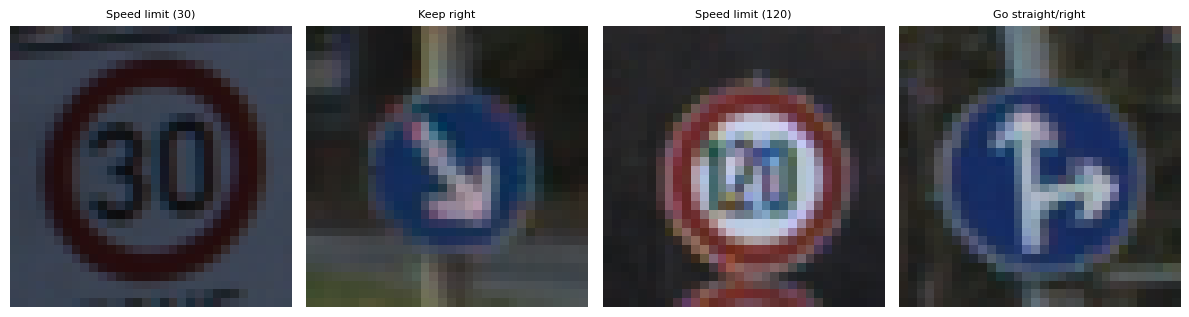

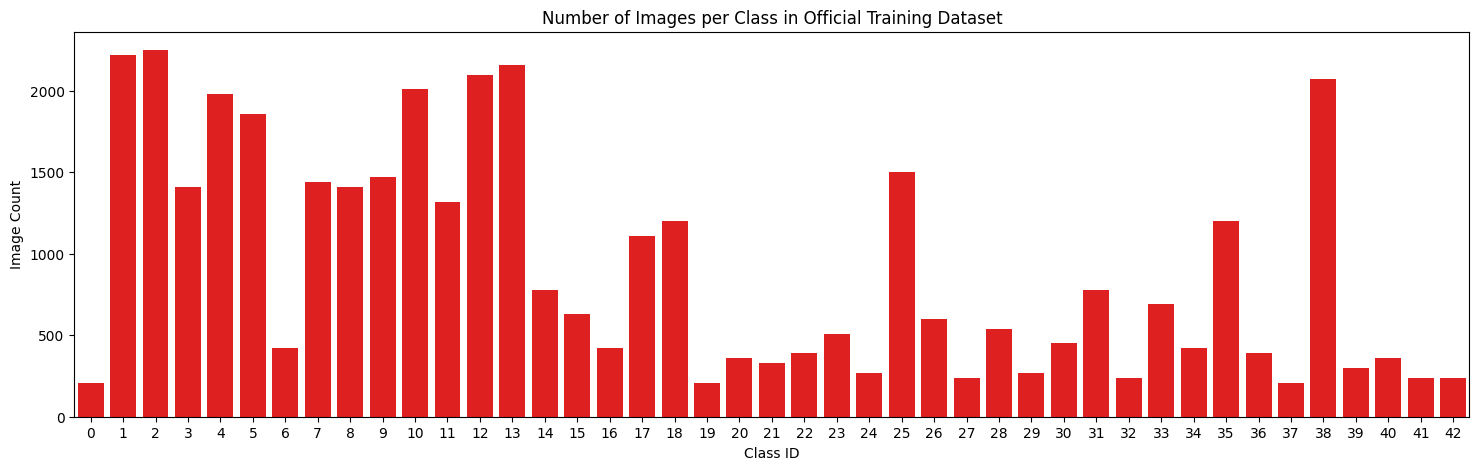

In [149]:
sample_indices = random.sample(range(len(data_train)), 4)  # 4 random images from the training dataset

plt.figure(figsize=(12,4))  # this lets us plot the 4 images next to each other
for plot_index, data_index in enumerate(sample_indices):  # this loops through them, namely the image index and position in the plot
    plt.subplot(1, 4, plot_index + 1)  # the layout is 1 row and 4 columns
    plt.imshow(data_train[data_index])
    plt.title(class_names[int(labels_train_full[data_index])], fontsize=8)
    plt.axis('off')

plt.tight_layout()  # this makes it cleaner
plt.show()

class_count_df = pd.Series(labels_train_full).value_counts().sort_index().reset_index()  # converts into pd, counts them, sorts them and turns them into df
class_count_df.columns = ['ClassId', 'Image Count']  # only for readability of the names

# the bar plotting code
plt.figure(figsize=(18,5))
sns.barplot(data=class_count_df, x='ClassId', y='Image Count', color='red')
plt.title('Number of Images per Class in Official Training Dataset')
plt.xlabel('Class ID')
plt.ylabel('Image Count')
plt.show()


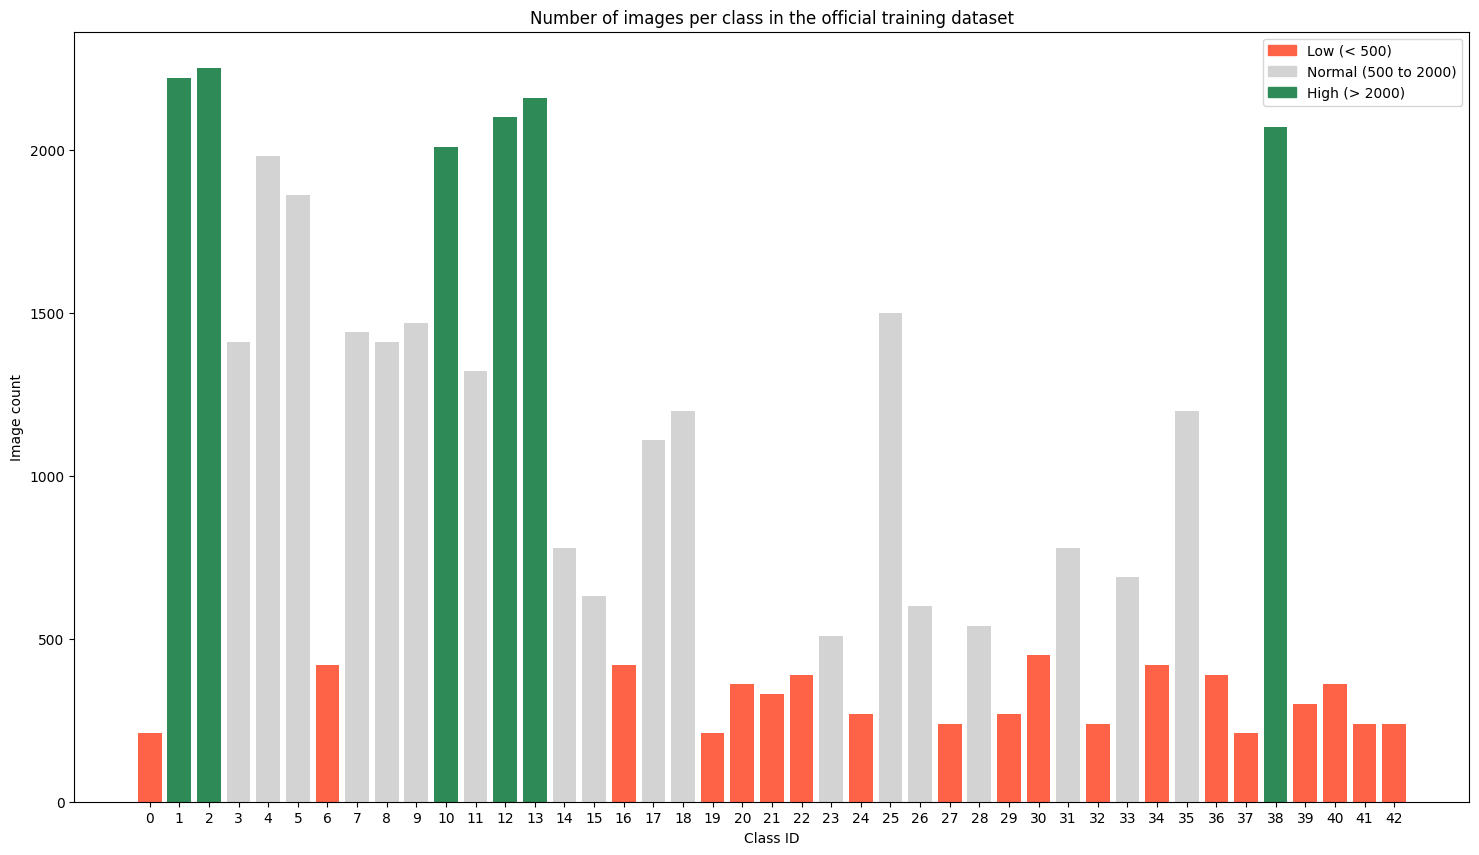

Low classes (<500 images):
    ClassId  Image Count
0         0          210
37       37          210
19       19          210
32       32          240
41       41          240
27       27          240
42       42          240
24       24          270
29       29          270
39       39          300
21       21          330
20       20          360
40       40          360
36       36          390
22       22          390
16       16          420
34       34          420
6         6          420
30       30          450

High classes (>2000 images):
    ClassId  Image Count
10       10         2010
38       38         2070
12       12         2100
13       13         2160
1         1         2220
2         2         2250


In [151]:
# count how many training images belong to each class in the official training dataset
class_count_df = pd.Series(labels_train_full).value_counts().sort_index().reset_index()
class_count_df.columns = ['ClassId', 'Image Count']

# a function that sets thresholds
def get_class_group(count):
    if count < 500:
        return 'Low'
    elif count > 2000:
        return 'High'
    else:
        return 'Normal'

class_count_df['Group'] = class_count_df['Image Count'].apply(get_class_group)  # this applies the function to the Image Count

# the colors for the graph
color_map = {
    'Low': 'tomato',
    'High': 'seagreen',
    'Normal': 'lightgrey'
}

bar_colors = class_count_df['Group'].map(color_map)  # converts each group label into its color

plt.figure(figsize=(18,10))  # height bigger than before
plt.bar(class_count_df['ClassId'], class_count_df['Image Count'], color=bar_colors)
plt.title('Number of images per class in the official training dataset')
plt.xlabel('Class ID')
plt.ylabel('Image count')
plt.xticks(class_count_df['ClassId'])

# this creates the legend, only for visual scope and for graph readability
from matplotlib.patches import Patch
legend_items = [
    Patch(color='tomato', label='Low (< 500)'),
    Patch(color='lightgrey', label='Normal (500 to 2000)'),
    Patch(color='seagreen', label='High (> 2000)')
]
plt.legend(handles=legend_items)  # this adds the legend to the chart

plt.show()

# this shows all the classes (their ClassId and Image Count) with below 500 entries sorted
print("Low classes (<500 images):")
print(class_count_df[class_count_df['Group'] == 'Low'][['ClassId', 'Image Count']].sort_values('Image Count', ascending=True))

# this shows the ones (their ClassId and Image Count) with over 2000 entries sorted
print("\nHigh classes (>2000 images):")
print(
    class_count_df[class_count_df['Group'] == 'High'][['ClassId', 'Image Count']].sort_values('Image Count', ascending=True)
)


We calculate the relative frequency

In [20]:
class_count_df['Relative Frequency'] = class_count_df['Image Count'] / class_count_df['Image Count'].sum()


Percetage

In [21]:
class_count_df['Relative Frequency (%)'] = 100 * class_count_df['Image Count'] / class_count_df['Image Count'].sum()


We plot it

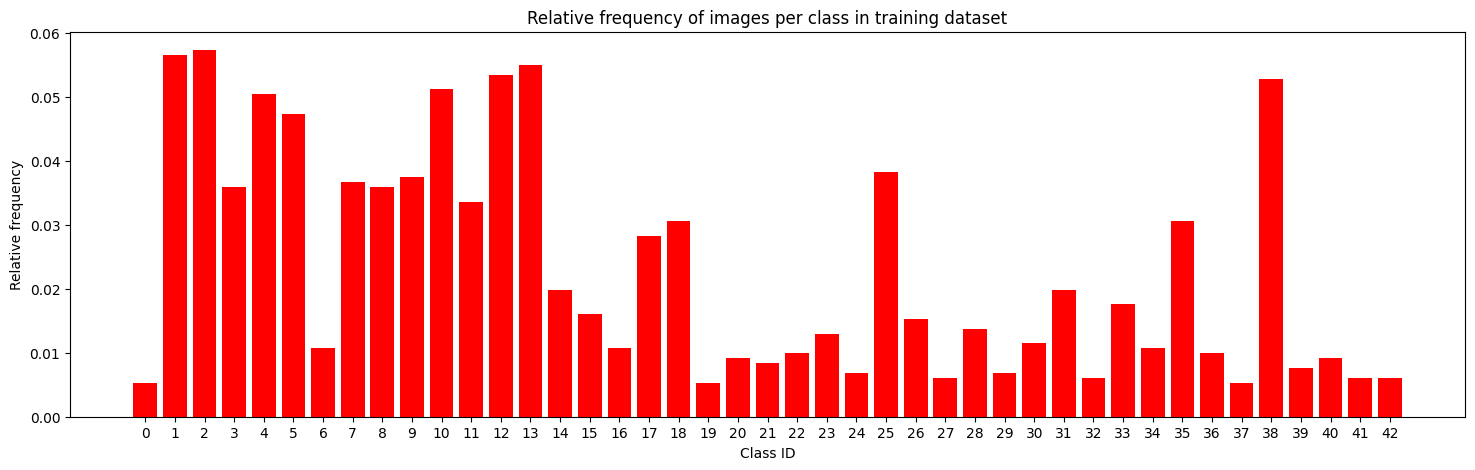

In [22]:
plt.figure(figsize=(18,5))
plt.bar(class_count_df['ClassId'], class_count_df['Relative Frequency'], color='red')
plt.title('Relative frequency of images per class in training dataset')
plt.xlabel('Class ID')
plt.ylabel('Relative frequency')
plt.xticks(class_count_df['ClassId'])
plt.show()


The data seems pretty realistic which is a very good sign

we check for the missing values

For train

In [23]:
print("Any missing in training data?", np.isnan(data_train).any())  # this checks if the training images have missing values
print("Any missing in training labels?", np.isnan(labels_train_full).any())  # this checks if the training labels have missing values


Any missing in training data? False
Any missing in training labels? False


For test

In [24]:
print("Any missing in test data?", np.isnan(data_test).any())  # this checks if the test images have missing values
print("Any missing in test labels?", np.isnan(labels_test).any())  # this checks if the test labels have missing values

Any missing in test data? False
Any missing in test labels? False


we check for the dublicate values and if there are conflict of image and its label

For train 

In [25]:
import hashlib  # creates unique fingerprints for each image
from collections import defaultdict

duplicate_groups = defaultdict(list)  # this creates an empty dictionary

for idx, img in enumerate(data_train):  # this loops through the training data
    image_hash = hashlib.md5(img.tobytes()).hexdigest()  # this creates fingerprints for each image
    duplicate_groups[image_hash].append(idx)  # this stores the current image in the dictionary under its hash

duplicates = [idxs for idxs in duplicate_groups.values() if len(idxs) > 1]  # this creates a list with the duplicate groups
print(f"Number of duplicate groups in training data: {len(duplicates)}")
print(f"Total duplicated training images: {sum(len(g) for g in duplicates)}")

conflicts = 0
for idxs in duplicates:  # this loops through duplicate groups
    unique_labels = set(labels_train_full[idxs])
    if len(unique_labels) > 1:
        conflicts += 1
        print(f"Identical training images have labels: {sorted(unique_labels)} at indices {idxs}")

print(f"\nDuplicate groups with conflicting labels in training data: {conflicts}")


Number of duplicate groups in training data: 0
Total duplicated training images: 0

Duplicate groups with conflicting labels in training data: 0


For test

In [26]:
test_duplicate_groups = defaultdict(list)

for idx, img in enumerate(data_test):
    image_hash = hashlib.md5(img.tobytes()).hexdigest()
    test_duplicate_groups[image_hash].append(idx)

test_duplicates = [idxs for idxs in test_duplicate_groups.values() if len(idxs) > 1]
print(f"Number of duplicate groups in test data: {len(test_duplicates)}")
print(f"Total duplicated test images: {sum(len(g) for g in test_duplicates)}")

test_conflicts = 0
for idxs in test_duplicates:
    unique_labels = set(labels_test[idxs])
    if len(unique_labels) > 1:
        test_conflicts += 1
        print(f"Identical test images have labels: {sorted(unique_labels)} at indices {idxs}")

print(f"\nDuplicate groups with conflicting labels in test data: {test_conflicts}")


Number of duplicate groups in test data: 0
Total duplicated test images: 0

Duplicate groups with conflicting labels in test data: 0


We verify the pixels value

For train

In [27]:
print("Min pixel value in training data:", data_train.min())
print("Max pixel value in training data:", data_train.max())


Min pixel value in training data: 0
Max pixel value in training data: 255


For test

In [28]:
print("Min pixel value in test data:", data_test.min())
print("Max pixel value in test data:", data_test.max())


Min pixel value in test data: 0
Max pixel value in test data: 255


Preparing the Dataset

We convert the images into arrays, normalise them and encode the labels before training the model.


In [31]:
def prep_dataset(X, y):  # X is the images and y is the labels
    X_prep = X.astype('float32') / 255.0  # converts X to float and scales the pixel values from 0-255 to 0-1
    y_prep = to_categorical(np.array(y), num_classes=43)  # encodes the class labels into one-hot encoded vectors
    return X_prep, y_prep


In [33]:
X_full_train, Y_full_train = prep_dataset(data_train, labels_train_full)
X_test, Y_test = prep_dataset(data_test, labels_test)

We split only the train into train and validation, since we already have a test

In [34]:
X_train, X_val, Y_train, Y_val, labels_train, labels_val = train_test_split(
    X_full_train,
    Y_full_train,
    labels_train_full,
    test_size=0.20,
    shuffle=True,
    stratify=labels_train_full,
    random_state=seed_value
)


This is used to see how the shape of the new data is looking like

In [35]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (31367, 32, 32, 3)
X_val shape: (7842, 32, 32, 3)
X_test shape: (12630, 32, 32, 3)
Y_train shape: (31367, 43)
Y_val shape: (7842, 43)
Y_test shape: (12630, 43)


This is the sanity check for the prep_data function we implemented above

In [36]:
print("Min pixel value in X_train:", X_train.min())
print("Max pixel value in X_train:", X_train.max())

print("Min pixel value in X_test:", X_test.min())
print("Max pixel value in X_test:", X_test.max())


Min pixel value in X_train: 0.0
Max pixel value in X_train: 1.0
Min pixel value in X_test: 0.0
Max pixel value in X_test: 1.0


brightness of the images

Minimum brightness: 6.63671875
Maximum brightness: 247.49153645833334
Average brightness: 82.71219236043808


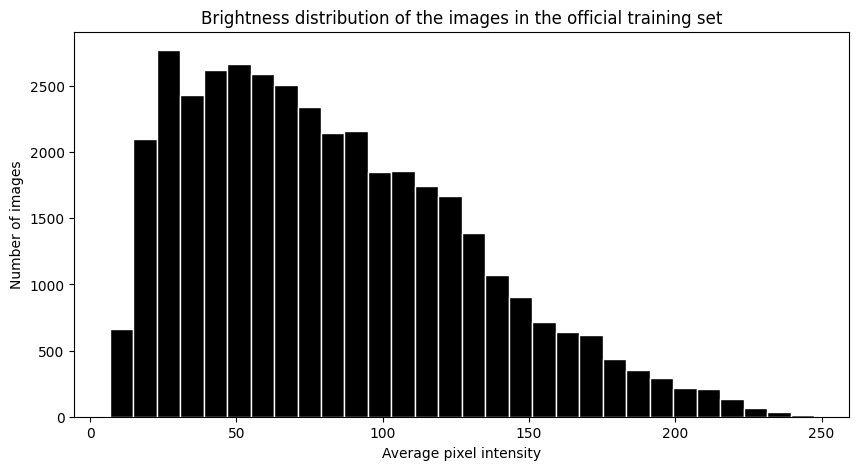

In [37]:
brightness = data_train.mean(axis=(1, 2, 3))  # average brightness per image

print("Minimum brightness:", brightness.min())  # the minimum
print("Maximum brightness:", brightness.max())  # the maximum
print("Average brightness:", brightness.mean())  # the average

plt.figure(figsize=(10,5))
plt.hist(brightness, bins=30, color='black', edgecolor='white')
plt.title('Brightness distribution of the images in the official training set')
plt.xlabel('Average pixel intensity')
plt.ylabel('Number of images')
plt.show()


This is the brightness of the test only to see with what we are dealing

In [38]:
brightness_test = data_test.mean(axis=(1, 2, 3))

print("Minimum test brightness:", brightness_test.min())
print("Maximum test brightness:", brightness_test.max())
print("Average test brightness:", brightness_test.mean())


Minimum test brightness: 9.4765625
Maximum test brightness: 238.25032552083334
Average test brightness: 82.19625429388526


This code help us visualise the brightest and darkest images

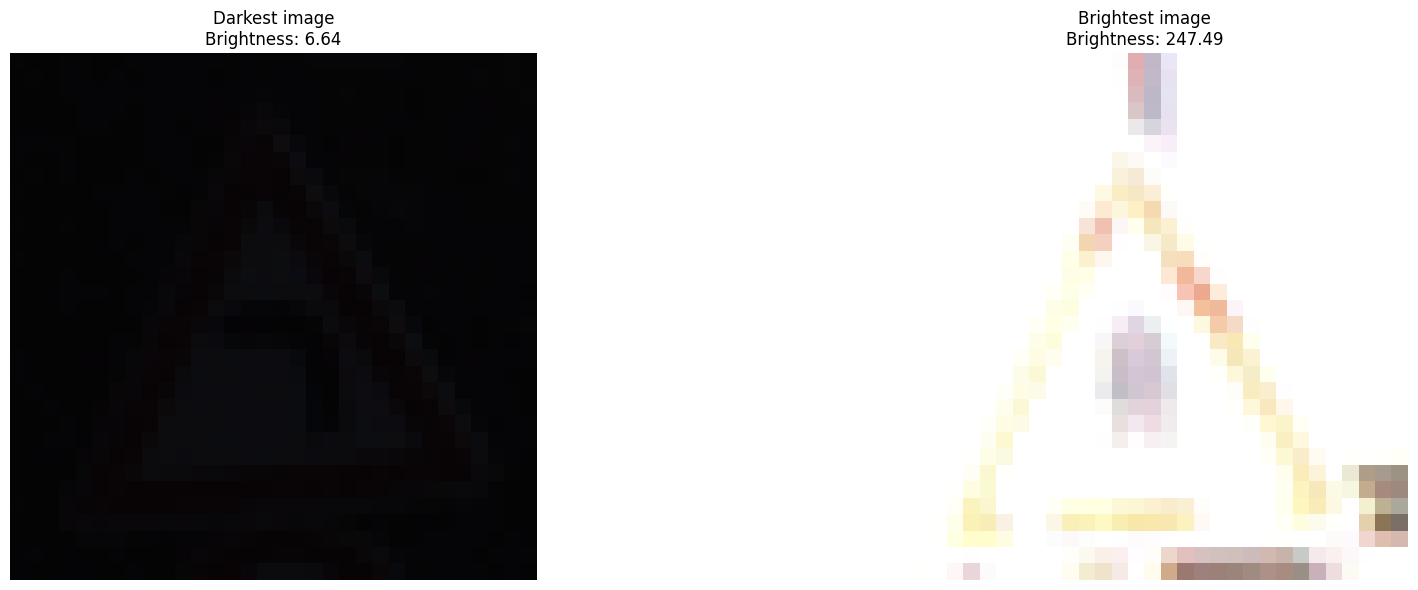

In [39]:
darkest_i = np.argmin(brightness)  # this finds the index of the image with the smallest brightness value
brightest_i = np.argmax(brightness)  # this does the same, but for the highest brightness value

plt.figure(figsize=(20,6))

# this plots the darkest image
plt.subplot(1,2,1)  # the first is for rows, the second is the columns and the third is the position
plt.imshow(data_train[darkest_i])
plt.title(f'Darkest image\nBrightness: {brightness[darkest_i]:.2f}')
plt.axis('off')  # this helps us to see the images better without the coordinates

# this plots the brightest image
plt.subplot(1,2,2)
plt.imshow(data_train[brightest_i])
plt.title(f'Brightest image\nBrightness: {brightness[brightest_i]:.2f}')
plt.axis('off')  # this helps us to see the images better without the coordinates

plt.tight_layout()
plt.show()


This may be a problem for the dataset, since from this images you cannot distiguised the traffic sign and can affect the performance of the model

The next problem that I want to address is how many of this images are, we want to get all the pictures over 200 and below 50

In [40]:
too_dark = np.where(brightness < 50)[0] #count the images below 50 brightness
too_bright = np.where(brightness > 200)[0] #count the images above 200 brightness

print("Very dark images:", len(too_dark))
print("Very bright images:", len(too_bright))


Very dark images: 11691
Very bright images: 655


the solution to the previous problem

We create a data augmentation

In [41]:
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(factor=0.15, value_range=(0, 1)), #this adds random brightness by making it brighter or darker and they can vary by 15%, the values range is given to tell Keras that the values are normalised already
    layers.RandomContrast(factor=0.15) #this does the same thingm but with contrast
], name='data_augmentation') # this gives its name


2026-04-27 16:09:08.115094: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-27 16:09:08.115647: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-27 16:09:08.116543: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-27 16:09:08.117135: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-27 16:09:08.117714: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



This code checks whether the same image appears in more than one dataset split.

In [42]:
import hashlib

def image_hashes(X):
    return [hashlib.md5(img.tobytes()).hexdigest() for img in X]

train_hashes = set(image_hashes(X_train))
val_hashes = set(image_hashes(X_val))
test_hashes = set(image_hashes(X_test))

print("Train/Val overlap:", len(train_hashes & val_hashes))
print("Train/Test overlap:", len(train_hashes & test_hashes))
print("Val/Test overlap:", len(val_hashes & test_hashes))



Train/Val overlap: 0
Train/Test overlap: 5
Val/Test overlap: 3


We remove from X_train and X_val any images whose hash also appears in X_test.

In [43]:
import hashlib

def image_hashes(X):
    return [hashlib.md5(img.tobytes()).hexdigest() for img in X]

train_hashes = image_hashes(X_train)
val_hashes = image_hashes(X_val)
test_hashes = set(image_hashes(X_test))

train_keep_mask = np.array([h not in test_hashes for h in train_hashes])
val_keep_mask = np.array([h not in test_hashes for h in val_hashes])

print("Training images removed:", np.sum(~train_keep_mask))
print("Validation images removed:", np.sum(~val_keep_mask))

X_train = X_train[train_keep_mask]
Y_train = Y_train[train_keep_mask]
labels_train = labels_train[train_keep_mask]

X_val = X_val[val_keep_mask]
Y_val = Y_val[val_keep_mask]
labels_val = labels_val[val_keep_mask]

print("New X_train shape:", X_train.shape)
print("New X_val shape:", X_val.shape)


Training images removed: 5
Validation images removed: 3
New X_train shape: (31362, 32, 32, 3)
New X_val shape: (7839, 32, 32, 3)


Recheck

In [44]:
train_hashes = set(image_hashes(X_train))
val_hashes = set(image_hashes(X_val))
test_hashes = set(image_hashes(X_test))

print("Train/Val overlap:", len(train_hashes & val_hashes))
print("Train/Test overlap:", len(train_hashes & test_hashes))
print("Val/Test overlap:", len(val_hashes & test_hashes))


Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


This code checks for near-duplicate or very similar images between splits.

In [45]:
from sklearn.neighbors import NearestNeighbors
# convert each image into a small grayscale feature vector
# this is not a classifier feature, only a quick similarity representation
def to_feature(img, size=(16, 16)):
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).clip(0, 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

    img_small = Image.fromarray(img).convert('L').resize(size)
    return np.array(img_small, dtype=np.float32).flatten() / 255.0


def find_similar_pairs(X_source, y_source, X_target, y_target, source_name='train', target_name='test'):
    X_source_feat = np.array([to_feature(img) for img in X_source])
    X_target_feat = np.array([to_feature(img) for img in X_target])

    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(X_source_feat)

    distances, indices = nn.kneighbors(X_target_feat)

    similar_df = pd.DataFrame({
        f'{target_name}_index': np.arange(len(X_target)),
        f'{source_name}_index': indices[:, 0],
        'distance': distances[:, 0],
        f'{target_name}_label': y_target,
        f'{source_name}_label': y_source[indices[:, 0]]
    }).sort_values('distance', ascending=True)

    return similar_df


# this run it for validation vs train
similar_val_df = find_similar_pairs(
    X_train, labels_train,
    X_val, labels_val,
    source_name='train',
    target_name='val'
)

# this run it for test vs train
similar_test_df = find_similar_pairs(
    X_train, labels_train,
    X_test, labels_test,
    source_name='train',
    target_name='test'
)

print("Closest validation images to train:")
display(similar_val_df.head(20))

print("Closest test images to train:")
display(similar_test_df.head(20))



Closest validation images to train:


,val_index,train_index,distance,val_label,train_label
285,285,7394,0.042237,10,10
5135,5135,23282,0.042959,10,10
2649,2649,14959,0.043137,10,10
906,906,19938,0.044020,10,10
5904,5904,28702,0.044713,4,4
46,46,6191,0.044884,19,19
2874,2874,15609,0.045733,19,19
7613,7613,10022,0.045901,3,3
2730,2730,14635,0.046235,8,8
286,286,741,0.046235,4,4


Closest test images to train:


,test_index,train_index,distance,test_label,train_label
3633,3633,5672,0.095012,5,5
5651,5651,6330,0.102112,5,5
10816,10816,9590,0.103086,5,5
11683,11683,9590,0.103829,5,5
1755,1755,9590,0.107182,5,5
2999,2999,16255,0.107397,5,5
3891,3891,19792,0.110502,14,14
7681,7681,30453,0.114668,4,4
5542,5542,14447,0.117712,5,5
11954,11954,14474,0.119656,14,14


This plot the images that are very close

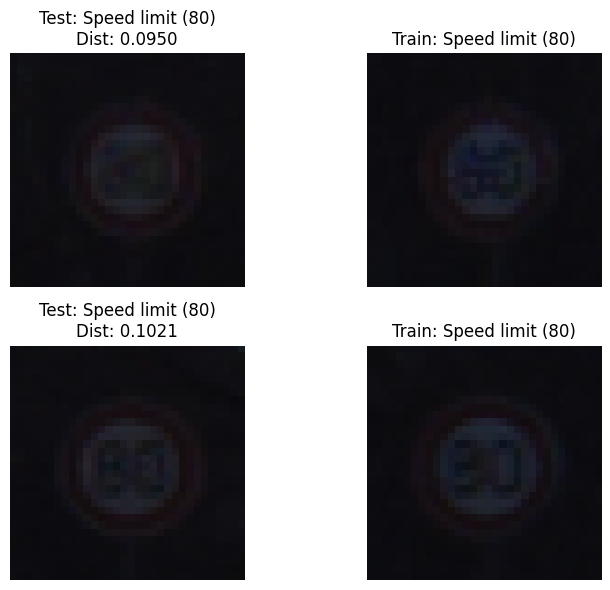

In [153]:
top_pairs = similar_test_df.head(2)

fig, axes = plt.subplots(len(top_pairs), 2, figsize=(8, 3 * len(top_pairs)))

for row, (_, pair) in enumerate(top_pairs.iterrows()):
    test_idx = int(pair['test_index'])
    train_idx = int(pair['train_index'])

    axes[row, 0].imshow(X_test[test_idx])
    axes[row, 0].set_title(f"Test: {class_names[labels_test[test_idx]]}\nDist: {pair['distance']:.4f}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(X_train[train_idx])
    axes[row, 1].set_title(f"Train: {class_names[labels_train[train_idx]]}")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


We plot the distances 

Nearest-neighbour distance summary for test vs train:
count    12630.000000
mean         1.523810
std          0.929632
min          0.095012
25%          0.722149
50%          1.375730
75%          2.236054
max          4.655019
Name: distance, dtype: float64


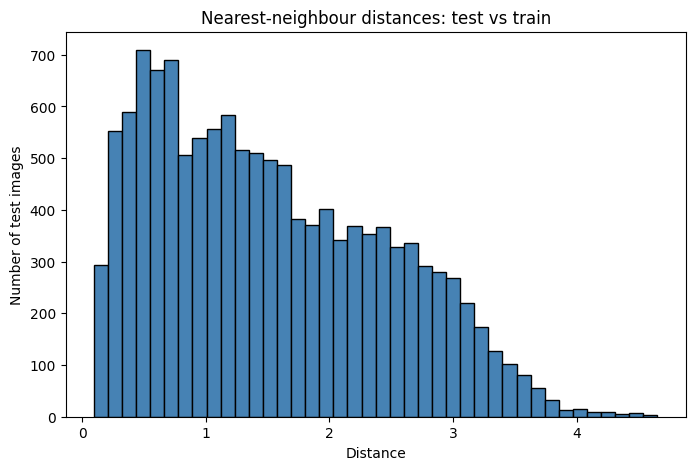

In [47]:
print("Nearest-neighbour distance summary for test vs train:")
print(similar_test_df['distance'].describe())

plt.figure(figsize=(8,5))
plt.hist(similar_test_df['distance'], bins=40, color='steelblue', edgecolor='black')
plt.title('Nearest-neighbour distances: test vs train')
plt.xlabel('Distance')
plt.ylabel('Number of test images')
plt.show()


We check the data by setting a threshold of below 0.1 for distance (we only flag the pair)

In [48]:
very_close_test_df = similar_test_df[similar_test_df['distance'] < 0.1]
print("Number of very close test/train pairs:", len(very_close_test_df))
very_close_test_df.head(20)


Number of very close test/train pairs: 1


,test_index,train_index,distance,test_label,train_label
3633,3633,5672,0.095012,5,5


This is the next part of the code where we implemnet the arhitectures and look which one is the best

**CNN Model**

The AlexNet is the first model that I wanted to try and it will be used as the baseline

In [ ]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

AlexNet = models.Sequential()  # AlexNet-style sequential neural network adapted for 32x32 images

AlexNet.add(layers.Input(shape=X_train.shape[1:]))

# Block 1
# ConvLayer(96 filters, 3x3) + Normalization + MaxPooling
# the original AlexNet uses 11x11 with stride 4, but for 32x32 images this is reduced to 3x3
# so that too much spatial information is not lost at the beginning
AlexNet.add(layers.Conv2D(filters=96, kernel_size=3, strides=1, activation='relu', padding='same'))
AlexNet.add(layers.Lambda(lambda x: tf.nn.local_response_normalization(x)))  # normalization layer
AlexNet.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Block 2
# ConvLayer(256 filters, 5x5) + Normalization + MaxPooling
# this follows the second AlexNet convolution block, adapted to small images
AlexNet.add(layers.Conv2D(filters=256, kernel_size=5, strides=1, activation='relu', padding='same'))
AlexNet.add(layers.Lambda(lambda x: tf.nn.local_response_normalization(x)))  #this is a normalization layer
AlexNet.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Block 3
# ConvLayer(384 filters, 3x3)
AlexNet.add(layers.Conv2D(filters=384, kernel_size=3, strides=1, activation='relu', padding='same'))

# Block 4
# ConvLayer(384 filters, 3x3)
AlexNet.add(layers.Conv2D(filters=384, kernel_size=3, strides=1, activation='relu', padding='same'))

# Block 5
# ConvLayer(256 filters, 3x3) + MaxPooling
AlexNet.add(layers.Conv2D(filters=256, kernel_size=3, strides=1, activation='relu', padding='same'))
AlexNet.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Flatten
# after the last pooling layer the feature maps are flattened into one vector
AlexNet.add(layers.Flatten())

# 1st Fully Connected layer with 4096 hidden units + Dropout
AlexNet.add(layers.Dense(4096, activation='relu'))
AlexNet.add(layers.Dropout(0.5))

# 2nd Fully Connected layer with 4096 hidden units + Dropout
AlexNet.add(layers.Dense(4096, activation='relu'))
AlexNet.add(layers.Dropout(0.5))

# Softmax layer for output
# the final layer has 43 units because the dataset has 43 traffic sign classes
AlexNet.add(layers.Dense(43, activation='softmax'))

AlexNet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │       176,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,453,739 (142.87 MB)

 Trainable params: 37,453,739 (142.87 MB)

 Non-trainable params: 0 (0.00 B)

This is the baseline compiler I want to usem namely simple ADAM and crossentropy, 20 epochs and bactch size of 64 will be used for all the models to make them comparable

In [ ]:
AlexNet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_AlexNet = AlexNet.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 86s 171ms/step - accuracy: 0.2081 - loss: 3.9602 - val_accuracy: 0.3725 - val_loss: 12.2720
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - accuracy: 0.3848 - loss: 74.6390 - val_accuracy: 0.3513 - val_loss: 125.3695
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - accuracy: 0.3980 - loss: 169.0818 - val_accuracy: 0.4369 - val_loss: 359.2997
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.5140 - loss: 933.4449 - val_accuracy: 0.5808 - val_loss: 1379.0604
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.6057 - loss: 2916.6741 - val_accuracy: 0.6537 - val_loss: 3426.9421
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.6936 - loss: 3682.4456 - val_accuracy: 0.7255 - val_loss: 3747.3030
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 162ms/step - accuracy: 0.7475 - loss: 5190.6646 - val_accuracy: 0.8000 - val_loss: 4369.8999
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 79s 161ms/st

This is the same arhitecture AlexNet stylem but it is added also the augmented data to it 

In [ ]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

AlexNetA = models.Sequential()  # AlexNet-style sequential neural network adapted for 32x32 images

AlexNetA.add(layers.Input(shape=X_train.shape[1:]))
AlexNetA.add(data_augmentation)  # augmented data

# Block 1
# ConvLayer(96 filters, 3x3) + Normalization + MaxPooling
# the original AlexNet uses 11x11 with stride 4, but for 32x32 images this is reduced to 3x3
# so that too much spatial information is not lost at the beginning
AlexNetA.add(layers.Conv2D(filters=96, kernel_size=3, strides=1, activation='relu', padding='same'))
AlexNetA.add(layers.Lambda(lambda x: tf.nn.local_response_normalization(x)))  # normalization layer
AlexNetA.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Block 2
# ConvLayer(256 filters, 5x5) + Normalization + MaxPooling
# this follows the second AlexNet convolution block, adapted to small images
AlexNetA.add(layers.Conv2D(filters=256, kernel_size=5, strides=1, activation='relu', padding='same'))
AlexNetA.add(layers.Lambda(lambda x: tf.nn.local_response_normalization(x)))  # normalization layer
AlexNetA.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Block 3
# ConvLayer(384 filters, 3x3)
AlexNetA.add(layers.Conv2D(filters=384, kernel_size=3, strides=1, activation='relu', padding='same'))

# Block 4
# ConvLayer(384 filters, 3x3)
AlexNetA.add(layers.Conv2D(filters=384, kernel_size=3, strides=1, activation='relu', padding='same'))

# Block 5
# ConvLayer(256 filters, 3x3) + MaxPooling
AlexNetA.add(layers.Conv2D(filters=256, kernel_size=3, strides=1, activation='relu', padding='same'))
AlexNetA.add(layers.MaxPool2D(pool_size=(2, 2), strides=2))

# Flatten
# after the last pooling layer the feature maps are flattened into one vector
AlexNetA.add(layers.Flatten())

# 1st Fully Connected layer with 4096 hidden units + Dropout
AlexNetA.add(layers.Dense(4096, activation='relu'))
AlexNetA.add(layers.Dropout(0.5))

# 2nd Fully Connected layer with 4096 hidden units + Dropout
AlexNetA.add(layers.Dense(4096, activation='relu'))
AlexNetA.add(layers.Dropout(0.5))

# Softmax layer for output
# the final layer has 43 units because the dataset has 43 traffic sign classes
AlexNetA.add(layers.Dense(43, activation='softmax'))

AlexNetA.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │       176,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,453,739 (142.87 MB)

 Trainable params: 37,453,739 (142.87 MB)

 Non-trainable params: 0 (0.00 B)

This was implemented to check if the augmented data was added correctly

In [ ]:
for i, layer in enumerate(AlexNetA.layers):
    print(i, layer.name, type(layer).__name__)

0 data_augmentation Sequential
1 conv2d Conv2D
2 lambda Lambda
3 max_pooling2d MaxPooling2D
4 conv2d_1 Conv2D
5 lambda_1 Lambda
6 max_pooling2d_1 MaxPooling2D
7 conv2d_2 Conv2D
8 conv2d_3 Conv2D
9 conv2d_4 Conv2D
10 max_pooling2d_2 MaxPooling2D
11 flatten Flatten
12 dense Dense
13 dropout Dropout
14 dense_1 Dense
15 dropout_1 Dropout
16 dense_2 Dense


This is the same compiler as before

In [ ]:
AlexNetA.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_AlexNetA = AlexNetA.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 90s 177ms/step - accuracy: 0.1463 - loss: 3.9788 - val_accuracy: 0.2407 - val_loss: 13.7711
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 89s 182ms/step - accuracy: 0.2681 - loss: 29.0054 - val_accuracy: 0.3655 - val_loss: 84.3996
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 85s 173ms/step - accuracy: 0.3457 - loss: 1908.5062 - val_accuracy: 0.5017 - val_loss: 3075.3765
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 84s 170ms/step - accuracy: 0.4927 - loss: 7257.1675 - val_accuracy: 0.5977 - val_loss: 9064.0645
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 84s 170ms/step - accuracy: 0.6143 - loss: 17703.2363 - val_accuracy: 0.7028 - val_loss: 20539.5371
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 85s 174ms/step - accuracy: 0.7065 - loss: 26631.6367 - val_accuracy: 0.7671 - val_loss: 29559.3926
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 83s 168ms/step - accuracy: 0.7693 - loss: 29804.5820 - val_accuracy: 0.8172 - val_loss: 20359.8691
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 82s 

First arhitecture

This model is a custom CNN baseline with three convolutional feature-extraction blocks followed by a large fully connected classifier. It was used to test whether a deeper dense head could improve performance before moving to smaller and more efficient VGG-style models.


In [ ]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model1 = models.Sequential()  # a sequential neural network

model1.add(layers.Input(shape=X_train.shape[1:]))
model1.add(data_augmentation)  # augmented data

# Block 1
# ConvLayer(32 filters) + MaxPooling + BatchNormalization + Dropout
model1.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.3))

# Block 2
# ConvLayer(128 filters) + MaxPooling + BatchNormalization + Dropout
model1.add(layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())
model1.add(layers.Dropout(0.3))

# Block 3
# ConvLayer(512 filters) + Dropout + ConvLayer(512 filters) + MaxPooling + BatchNormalization
model1.add(layers.Conv2D(filters=512, kernel_size=3, activation='relu', padding='same'))
model1.add(layers.Dropout(0.3))
model1.add(layers.Conv2D(filters=512, kernel_size=3, activation='relu', padding='same'))
model1.add(layers.MaxPool2D(strides=2))
model1.add(layers.BatchNormalization())

# Flatten
model1.add(layers.Flatten())

# 2 Dense layers with 4000 hidden units
model1.add(layers.Dense(4000, activation='relu'))
model1.add(layers.Dense(4000, activation='relu'))

# Dense layer with 1000 hidden units
model1.add(layers.Dense(1000, activation='relu'))

# Softmax layer for output
model1.add(layers.Dense(43, activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4000)           │    32,772,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4000)           │    16,004,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        43,043 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,810,763 (212.90 MB)

 Trainable params: 55,809,419 (212.90 MB)

 Non-trainable params: 1,344 (5.25 KB)

Same compiler as before

In [ ]:
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.0546 - loss: 2493.6094 - val_accuracy: 0.0161 - val_loss: 6671.8564
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.1521 - loss: 40143.8086 - val_accuracy: 0.0791 - val_loss: 56625.9336
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 81s 164ms/step - accuracy: 0.2430 - loss: 31066.8613 - val_accuracy: 0.1934 - val_loss: 38272.2578
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.3201 - loss: 48418.0352 - val_accuracy: 0.2847 - val_loss: 104418.1172
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 81s 164ms/step - accuracy: 0.4357 - loss: 67501.3594 - val_accuracy: 0.4487 - val_loss: 97099.0547
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 164ms/step - accuracy: 0.5245 - loss: 80990.8125 - val_accuracy: 0.5298 - val_loss: 263151.7500
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 80s 164ms/step - accuracy: 0.6033 - loss: 76615.6562 - val_accuracy: 0.4910 - val_loss: 205520.1875
Epoch 8/20
491/491 ━━━━━━━

Second arhitecture- this is a VGG inspired arhitecture that was did in order to match the 32x32 sized imges

In [73]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2 = models.Sequential()  # smaller VGG-style CNN
model2.add(layers.Input(shape=X_train.shape[1:]))
model2.add(data_augmentation)  # augmented data

# Block 1
model2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.25))

# Block 2
model2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.25))

# Block 3
model2.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

# Block 4
model2.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2.add(layers.MaxPool2D((2, 2)))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

# Classifier
model2.add(layers.Flatten())
model2.add(layers.Dense(512, activation='relu'))
model2.add(layers.Dropout(0.5))
model2.add(layers.Dense(43, activation='softmax'))

model2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,80

 Total params: 1,721,035 (6.57 MB)

 Trainable params: 1,720,075 (6.56 MB)

 Non-trainable params: 960 (3.75 KB)

Fitting the model as before

In [74]:
model2.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history2= model2.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 47s 86ms/step - accuracy: 0.3375 - loss: 3.8313 - val_accuracy: 0.6813 - val_loss: 1.0636
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - accuracy: 0.8359 - loss: 0.6152 - val_accuracy: 0.9474 - val_loss: 0.1854
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9163 - loss: 0.3232 - val_accuracy: 0.9814 - val_loss: 0.0685
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.9405 - loss: 0.2455 - val_accuracy: 0.9890 - val_loss: 0.0449
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 64s 129ms/step - accuracy: 0.9589 - loss: 0.1725 - val_accuracy: 0.9894 - val_loss: 0.0421
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.9467 - loss: 0.2432 - val_accuracy: 0.9842 - val_loss: 0.0602
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 53s 107ms/step - accuracy: 0.9612 - loss: 0.1715 - val_accuracy: 0.9939 - val_loss: 0.0217
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.9632 - loss: 0.1870

This model is using the same arhitecture as the previous model, only difference being the classifer that was changed to GobalAverage pooling

In [71]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2c = models.Sequential()  # smaller VGG-style CNN with a lighter classifier
model2c.add(layers.Input(shape=X_train.shape[1:]))
model2c.add(data_augmentation)  # augmented data

# Block 1
model2c.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2c.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2c.add(layers.MaxPool2D((2, 2)))
model2c.add(layers.BatchNormalization())
model2c.add(layers.Dropout(0.25))

# Block 2
model2c.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2c.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2c.add(layers.MaxPool2D((2, 2)))
model2c.add(layers.BatchNormalization())
model2c.add(layers.Dropout(0.25))

# Block 3
model2c.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2c.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2c.add(layers.MaxPool2D((2, 2)))
model2c.add(layers.BatchNormalization())
model2c.add(layers.Dropout(0.3))

# Block 4
model2c.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2c.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
model2c.add(layers.MaxPool2D((2, 2)))
model2c.add(layers.BatchNormalization())
model2c.add(layers.Dropout(0.3))

# Classifier
model2c.add(layers.GlobalAveragePooling2D())
model2c.add(layers.Dense(128, activation='relu'))
model2c.add(layers.Dropout(0.5))
model2c.add(layers.Dense(43, activation='softmax'))

model2c.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,212,619 (4.63 MB)

 Trainable params: 1,211,659 (4.62 MB)

 Non-trainable params: 960 (3.75 KB)

Again this is the same as before

In [72]:
model2c.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history2c= model2c.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 64ms/step - accuracy: 0.4509 - loss: 2.0880 - val_accuracy: 0.4369 - val_loss: 2.1977
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.8969 - loss: 0.3552 - val_accuracy: 0.9809 - val_loss: 0.0630
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9386 - loss: 0.2229 - val_accuracy: 0.9890 - val_loss: 0.0329
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9600 - loss: 0.1552 - val_accuracy: 0.9932 - val_loss: 0.0192
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9548 - loss: 0.1655 - val_accuracy: 0.9871 - val_loss: 0.0422
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9641 - loss: 0.1349 - val_accuracy: 0.9944 - val_loss: 0.0166
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9733 - loss: 0.1034 - val_accuracy: 0.9952 - val_loss: 0.0160
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9763 - loss: 0.0983 - 

This is using the same arhitecture besides the block 4 which is using less convolutional filters from 256 to 128, which was implemented to see the trade off between the computation expensiveness and accuracy

In [69]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2cl = models.Sequential()  # smaller VGG-style CNN with a lighter classifier
model2cl.add(layers.Input(shape=X_train.shape[1:]))
model2cl.add(data_augmentation)  # augmented data

# Block 1
model2cl.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.MaxPool2D((2, 2)))
model2cl.add(layers.BatchNormalization())
model2cl.add(layers.Dropout(0.25))

# Block 2
model2cl.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.MaxPool2D((2, 2)))
model2cl.add(layers.BatchNormalization())
model2cl.add(layers.Dropout(0.25))

# Block 3
model2cl.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.MaxPool2D((2, 2)))
model2cl.add(layers.BatchNormalization())
model2cl.add(layers.Dropout(0.3))

# Block 4
model2cl.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl.add(layers.MaxPool2D((2, 2)))
model2cl.add(layers.BatchNormalization())
model2cl.add(layers.Dropout(0.3))

# Classifier
model2cl.add(layers.GlobalAveragePooling2D())
model2cl.add(layers.Dense(128, activation='relu'))
model2cl.add(layers.Dropout(0.5))
model2cl.add(layers.Dense(43, activation='softmax'))

model2cl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 605,643 (2.31 MB)

 Trainable params: 604,939 (2.31 MB)

 Non-trainable params: 704 (2.75 KB)

In [70]:
model2cl.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history2cl= model2cl.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.3716 - loss: 2.3315 - val_accuracy: 0.6790 - val_loss: 1.0648
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.8492 - loss: 0.5031 - val_accuracy: 0.9619 - val_loss: 0.1334
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9250 - loss: 0.2578 - val_accuracy: 0.9699 - val_loss: 0.0971
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9332 - loss: 0.2364 - val_accuracy: 0.9866 - val_loss: 0.0445
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9441 - loss: 0.2194 - val_accuracy: 0.9925 - val_loss: 0.0276
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9639 - loss: 0.1467 - val_accuracy: 0.9940 - val_loss: 0.0209
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9664 - loss: 0.1352 - val_accuracy: 0.9932 - val_loss: 0.0219
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9760 - loss: 0.0982 - 

The previous experiment showed as that maybe we can reduce even further the convolutional filters to make the model even less computational  expensive, we reduce to half all convolutional filters of the convolutional layers

In [94]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2cll = models.Sequential()  # smaller VGG-style CNN with a lighter classifier
model2cll.add(layers.Input(shape=X_train.shape[1:]))
model2cll.add(data_augmentation)  # augmented data

# Block 1
model2cll.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.MaxPool2D((2, 2)))
model2cll.add(layers.BatchNormalization())
model2cll.add(layers.Dropout(0.25))

# Block 2
model2cll.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.MaxPool2D((2, 2)))
model2cll.add(layers.BatchNormalization())
model2cll.add(layers.Dropout(0.25))

# Block 3
model2cll.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.MaxPool2D((2, 2)))
model2cll.add(layers.BatchNormalization())
model2cll.add(layers.Dropout(0.3))

# Block 4
model2cll.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cll.add(layers.MaxPool2D((2, 2)))
model2cll.add(layers.BatchNormalization())
model2cll.add(layers.Dropout(0.3))

# Classifier
model2cll.add(layers.GlobalAveragePooling2D())
model2cll.add(layers.Dense(128, activation='relu'))
model2cll.add(layers.Dropout(0.5))
model2cll.add(layers.Dense(43, activation='softmax'))

model2cll.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,507 (626.98 KB)

 Trainable params: 160,155 (625.61 KB)

 Non-trainable params: 352 (1.38 KB)

In [95]:
model2cll.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

history2cll= model2cll.fit(X_train,Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val,Y_val))

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.2909 - loss: 2.5654 - val_accuracy: 0.4064 - val_loss: 2.1780
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.7204 - loss: 0.8900 - val_accuracy: 0.9103 - val_loss: 0.2645
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.8621 - loss: 0.4537 - val_accuracy: 0.9601 - val_loss: 0.1305
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9074 - loss: 0.3220 - val_accuracy: 0.9763 - val_loss: 0.0770
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9224 - loss: 0.2688 - val_accuracy: 0.9800 - val_loss: 0.0583
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9330 - loss: 0.2331 - val_accuracy: 0.9911 - val_loss: 0.0341
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9366 - loss: 0.2288 - val_accuracy: 0.9906 - val_loss: 0.0332
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9446 - loss: 0.2073 - 

This arhitecture implement to each convolutional layers also He initialisation

In [ ]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

modelcllh = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and He initialization
modelcllh.add(layers.Input(shape=X_train.shape[1:]))
modelcllh.add(data_augmentation)  # augmented data

# Block 1
modelcllh.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.MaxPool2D((2, 2)))
modelcllh.add(layers.BatchNormalization())
modelcllh.add(layers.Dropout(0.25))

# Block 2
modelcllh.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.MaxPool2D((2, 2)))
modelcllh.add(layers.BatchNormalization())
modelcllh.add(layers.Dropout(0.25))

# Block 3
modelcllh.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.MaxPool2D((2, 2)))
modelcllh.add(layers.BatchNormalization())
modelcllh.add(layers.Dropout(0.3))

# Block 4
modelcllh.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh.add(layers.MaxPool2D((2, 2)))
modelcllh.add(layers.BatchNormalization())
modelcllh.add(layers.Dropout(0.3))

# Classifier
modelcllh.add(layers.GlobalAveragePooling2D())
modelcllh.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
modelcllh.add(layers.Dropout(0.5))
modelcllh.add(layers.Dense(43, activation='softmax'))

modelcllh.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,507 (626.98 KB)

 Trainable params: 160,155 (625.61 KB)

 Non-trainable params: 352 (1.38 KB)

In [ ]:
modelcllh.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historycllh = modelcllh.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.1318 - loss: 3.4077 - val_accuracy: 0.2717 - val_loss: 2.4674
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.4357 - loss: 1.7966 - val_accuracy: 0.6958 - val_loss: 0.9316
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.7029 - loss: 0.9143 - val_accuracy: 0.8951 - val_loss: 0.3041
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.8411 - loss: 0.5011 - val_accuracy: 0.9653 - val_loss: 0.1189
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.8880 - loss: 0.3632 - val_accuracy: 0.9812 - val_loss: 0.0590
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9171 - loss: 0.2763 - val_accuracy: 0.9906 - val_loss: 0.0309
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9338 - loss: 0.2337 - val_accuracy: 0.9912 - val_loss: 0.0312
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9414 - loss: 0.2036 - 

This is the same only the fitting will be changed

In [51]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

modelcllh2 = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and He initialization
modelcllh2.add(layers.Input(shape=X_train.shape[1:]))
modelcllh2.add(data_augmentation)  # augmented data

# Block 1
modelcllh2.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.MaxPool2D((2, 2)))
modelcllh2.add(layers.BatchNormalization())
modelcllh2.add(layers.Dropout(0.25))

# Block 2
modelcllh2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.MaxPool2D((2, 2)))
modelcllh2.add(layers.BatchNormalization())
modelcllh2.add(layers.Dropout(0.25))

# Block 3
modelcllh2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.MaxPool2D((2, 2)))
modelcllh2.add(layers.BatchNormalization())
modelcllh2.add(layers.Dropout(0.3))

# Block 4
modelcllh2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2.add(layers.MaxPool2D((2, 2)))
modelcllh2.add(layers.BatchNormalization())
modelcllh2.add(layers.Dropout(0.3))

# Classifier
modelcllh2.add(layers.GlobalAveragePooling2D())
modelcllh2.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
modelcllh2.add(layers.Dropout(0.5))
modelcllh2.add(layers.Dense(43, activation='softmax'))

modelcllh2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,507 (626.98 KB)

 Trainable params: 160,155 (625.61 KB)

 Non-trainable params: 352 (1.38 KB)

As the compiler we choose to change from simple ADAM to ADAMW which is using also weight deecay

In [52]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=1e-4
)

modelcllh2.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historycllh2 = modelcllh2.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.1226 - loss: 3.4612 - val_accuracy: 0.3243 - val_loss: 2.3226
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4173 - loss: 1.8710 - val_accuracy: 0.6501 - val_loss: 1.0138
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.6888 - loss: 0.9611 - val_accuracy: 0.8826 - val_loss: 0.3674
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.8358 - loss: 0.5214 - val_accuracy: 0.9575 - val_loss: 0.1316
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.8830 - loss: 0.3702 - val_accuracy: 0.9728 - val_loss: 0.0874
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9103 - loss: 0.2918 - val_accuracy: 0.9745 - val_loss: 0.0744
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9244 - loss: 0.2584 - val_accuracy: 0.9857 - val_loss: 0.0467
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.9290 - loss: 0.2393 - 

This is tring different lr and wd to see which one is the best

In [ ]:
search_configs = [
    {"lr": 1e-4, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-5},
    {"lr": 1e-5, "wd": 1e-5},
]

def build_modelcllh2():
    reset_everything(seed_value)

    model = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and He initialization
    model.add(layers.Input(shape=X_train.shape[1:]))
    model.add(data_augmentation)  # augmented data

    # Block 1
    model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.MaxPool2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.MaxPool2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.MaxPool2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Block 4
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
    model.add(layers.MaxPool2D((2, 2)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Classifier
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(43, activation='softmax'))

    return model

search_results = []

for config in search_configs:
    print(f"\nRunning lr={config['lr']}, wd={config['wd']}")

    model = build_modelcllh2()

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config["lr"],
        weight_decay=config["wd"]
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, Y_train,
        epochs=5,
        batch_size=64,
        validation_data=(X_val, Y_val),
        verbose=1
    )

    best_epoch = np.argmax(history.history['val_accuracy']) + 1

    search_results.append({
        "lr": config["lr"],
        "wd": config["wd"],
        "best_epoch": best_epoch,
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "best_val_loss": min(history.history["val_loss"]),
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_val_accuracy": history.history["val_accuracy"][-1]
    })

results_df = pd.DataFrame(search_results).sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
)

results_df


Running lr=0.0001, wd=0.0001
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 129s 242ms/step - accuracy: 0.0398 - loss: 4.3430 - val_accuracy: 0.0804 - val_loss: 3.5736
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 163s 332ms/step - accuracy: 0.0735 - loss: 3.8479 - val_accuracy: 0.1406 - val_loss: 3.2045
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 110s 223ms/step - accuracy: 0.1127 - loss: 3.5537 - val_accuracy: 0.1763 - val_loss: 2.9908
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 118s 241ms/step - accuracy: 0.1448 - loss: 3.3167 - val_accuracy: 0.2401 - val_loss: 2.7861
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 77s 155ms/step - accuracy: 0.1855 - loss: 3.0677 - val_accuracy: 0.2907 - val_loss: 2.5309

Running lr=0.0001, wd=1e-05
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 87s 153ms/step - accuracy: 0.0400 - loss: 4.3403 - val_accuracy: 0.0721 - val_loss: 3.5740
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 128s 260ms/step - accuracy: 0.0721 - loss: 3.8712 - val_accuracy: 0.1430 - val_loss: 3.2183
Epoch 3/5
491/491 ━━━━━━━━

,lr,wd,best_epoch,best_val_accuracy,best_val_loss,final_train_accuracy,final_val_accuracy
1,0.00010,0.00001,5,0.293532,2.553774,0.186691,0.293532
0,0.00010,0.00010,5,0.290726,2.530868,0.185543,0.290726
2,0.00001,0.00001,5,0.050517,3.750503,0.036956,0.050517


The same as before again only the compiler was changed

In [49]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

modelcllh2l = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and He initialization
modelcllh2l.add(layers.Input(shape=X_train.shape[1:]))
modelcllh2l.add(data_augmentation)  # augmented data

# Block 1
modelcllh2l.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.MaxPool2D((2, 2)))
modelcllh2l.add(layers.BatchNormalization())
modelcllh2l.add(layers.Dropout(0.25))

# Block 2
modelcllh2l.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.MaxPool2D((2, 2)))
modelcllh2l.add(layers.BatchNormalization())
modelcllh2l.add(layers.Dropout(0.25))

# Block 3
modelcllh2l.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.MaxPool2D((2, 2)))
modelcllh2l.add(layers.BatchNormalization())
modelcllh2l.add(layers.Dropout(0.3))

# Block 4
modelcllh2l.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l.add(layers.MaxPool2D((2, 2)))
modelcllh2l.add(layers.BatchNormalization())
modelcllh2l.add(layers.Dropout(0.3))

# Classifier
modelcllh2l.add(layers.GlobalAveragePooling2D())
modelcllh2l.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
modelcllh2l.add(layers.Dropout(0.5))
modelcllh2l.add(layers.Dense(43, activation='softmax'))

modelcllh2l.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,507 (626.98 KB)

 Trainable params: 160,155 (625.61 KB)

 Non-trainable params: 352 (1.38 KB)

This time we decreased the wd and lr to see if the model can reach the 100% accuracy

In [50]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-5,
    weight_decay=1e-5
)

modelcllh2l.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historycllh2l = modelcllh2l.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20


2026-04-27 16:10:43.624708: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.0256 - loss: 4.8738 - val_accuracy: 0.0111 - val_loss: 4.1472
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.0282 - loss: 4.5837 - val_accuracy: 0.0291 - val_loss: 3.9759
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.0322 - loss: 4.4674 - val_accuracy: 0.0389 - val_loss: 3.8853
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.0322 - loss: 4.3974 - val_accuracy: 0.0461 - val_loss: 3.8148
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.0372 - loss: 4.3133 - val_accuracy: 0.0500 - val_loss: 3.7607
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.0390 - loss: 4.2598 - val_accuracy: 0.0551 - val_loss: 3.7106
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.0443 - loss: 4.2073 - val_accuracy: 0.0615 - val_loss: 3.6590
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.0476 - loss: 4.1627 - val_accurac

Again the same arhitecture

In [53]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

modelcllh2l_SGD = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and He initialization
modelcllh2l_SGD.add(layers.Input(shape=X_train.shape[1:]))
modelcllh2l_SGD.add(data_augmentation)  # augmented data

# Block 1
modelcllh2l_SGD.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.MaxPool2D((2, 2)))
modelcllh2l_SGD.add(layers.BatchNormalization())
modelcllh2l_SGD.add(layers.Dropout(0.25))

# Block 2
modelcllh2l_SGD.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.MaxPool2D((2, 2)))
modelcllh2l_SGD.add(layers.BatchNormalization())
modelcllh2l_SGD.add(layers.Dropout(0.25))

# Block 3
modelcllh2l_SGD.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.MaxPool2D((2, 2)))
modelcllh2l_SGD.add(layers.BatchNormalization())
modelcllh2l_SGD.add(layers.Dropout(0.3))

# Block 4
modelcllh2l_SGD.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.MaxPool2D((2, 2)))
modelcllh2l_SGD.add(layers.BatchNormalization())
modelcllh2l_SGD.add(layers.Dropout(0.3))

# Classifier
modelcllh2l_SGD.add(layers.GlobalAveragePooling2D())
modelcllh2l_SGD.add(layers.Dense(128, activation='relu', kernel_initializer='he_normal'))
modelcllh2l_SGD.add(layers.Dropout(0.5))
modelcllh2l_SGD.add(layers.Dense(43, activation='softmax'))

modelcllh2l_SGD.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 160,507 (626.98 KB)

 Trainable params: 160,155 (625.61 KB)

 Non-trainable params: 352 (1.38 KB)

This compiler is using SGD instead of ADAM

In [55]:
optimizer_sgd = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

modelcllh2l_SGD.compile(
    optimizer=optimizer_sgd,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.F1Score(name='f1_macro', average='macro', threshold=None),
        tf.keras.metrics.F1Score(name='f1_weighted', average='weighted', threshold=None)
    ]
)

historycllh2l_SGD = modelcllh2l_SGD.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3402 - f1_macro: 0.2084 - f1_weighted: 0.3091 - loss: 2.1806 - val_accuracy: 0.4663 - val_f1_macro: 0.2738 - val_f1_weighted: 0.3985 - val_loss: 1.6316
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.5100 - f1_macro: 0.3639 - f1_weighted: 0.4877 - loss: 1.5003 - val_accuracy: 0.7019 - val_f1_macro: 0.5335 - val_f1_weighted: 0.6756 - val_loss: 0.8778
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.6758 - f1_macro: 0.5638 - f1_weighted: 0.6653 - loss: 0.9837 - val_accuracy: 0.6775 - val_f1_macro: 0.5619 - val_f1_weighted: 0.6656 - val_loss: 0.9800
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7701 - f1_macro: 0.6862 - f1_weighted: 0.7657 - loss: 0.7042 - val_accuracy: 0.7640 - val_f1_macro: 0.6853 - val_f1_weighted: 0.7583 - val_loss: 0.8223
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7883 - f1_macro: 0.7100 - f1_weighted: 0.7847 - loss

This models tests L2 regularization on the Model 2cl architecture

In [56]:
l2_reg = tf.keras.regularizers.l2(1e-4)

reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2cl_reg = models.Sequential()  # smaller VGG-style CNN with a lighter classifier and L2 regularization
model2cl_reg.add(layers.Input(shape=X_train.shape[1:]))
model2cl_reg.add(data_augmentation)  # augmented data

# Block 1
model2cl_reg.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.MaxPool2D((2, 2)))
model2cl_reg.add(layers.BatchNormalization())
model2cl_reg.add(layers.Dropout(0.25))

# Block 2
model2cl_reg.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.MaxPool2D((2, 2)))
model2cl_reg.add(layers.BatchNormalization())
model2cl_reg.add(layers.Dropout(0.25))

# Block 3
model2cl_reg.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.MaxPool2D((2, 2)))
model2cl_reg.add(layers.BatchNormalization())
model2cl_reg.add(layers.Dropout(0.3))

# Block 4
model2cl_reg.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.MaxPool2D((2, 2)))
model2cl_reg.add(layers.BatchNormalization())
model2cl_reg.add(layers.Dropout(0.3))

# Classifier
model2cl_reg.add(layers.GlobalAveragePooling2D())
model2cl_reg.add(layers.Dense(128, activation='relu', kernel_regularizer=l2_reg))
model2cl_reg.add(layers.Dropout(0.5))
model2cl_reg.add(layers.Dense(43, activation='softmax'))

model2cl_reg.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 605,643 (2.31 MB)

 Trainable params: 604,939 (2.31 MB)

 Non-trainable params: 704 (2.75 KB)

We get back to ADAM since its performance was better than the last SGD

In [57]:
optimizer_adam = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model2cl_reg.compile(
    optimizer=optimizer_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2cl_reg = model2cl_reg.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val)
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.3282 - loss: 2.5873 - val_accuracy: 0.4789 - val_loss: 2.0359
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8431 - loss: 0.6210 - val_accuracy: 0.9339 - val_loss: 0.3260
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9381 - loss: 0.3254 - val_accuracy: 0.9839 - val_loss: 0.1597
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9280 - loss: 0.3869 - val_accuracy: 0.9871 - val_loss: 0.1633
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9598 - loss: 0.2763 - val_accuracy: 0.9936 - val_loss: 0.1433
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9688 - loss: 0.2491 - val_accuracy: 0.9969 - val_loss: 0.1364
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9714 - loss: 0.2408 - val_accuracy: 0.9952 - val_loss: 0.1434
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9715 - loss: 0.2478 - 

This is the same arhitecture, only we implemented lr decay to the compiler

In [58]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2cl_lrdecay = models.Sequential()  # smaller VGG-style CNN with a lighter classifier
model2cl_lrdecay.add(layers.Input(shape=X_train.shape[1:]))
model2cl_lrdecay.add(data_augmentation)  # augmented data

# Block 1
model2cl_lrdecay.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.MaxPool2D((2, 2)))
model2cl_lrdecay.add(layers.BatchNormalization())
model2cl_lrdecay.add(layers.Dropout(0.25))

# Block 2
model2cl_lrdecay.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.MaxPool2D((2, 2)))
model2cl_lrdecay.add(layers.BatchNormalization())
model2cl_lrdecay.add(layers.Dropout(0.25))

# Block 3
model2cl_lrdecay.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.MaxPool2D((2, 2)))
model2cl_lrdecay.add(layers.BatchNormalization())
model2cl_lrdecay.add(layers.Dropout(0.3))

# Block 4
model2cl_lrdecay.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_lrdecay.add(layers.MaxPool2D((2, 2)))
model2cl_lrdecay.add(layers.BatchNormalization())
model2cl_lrdecay.add(layers.Dropout(0.3))

# Classifier
model2cl_lrdecay.add(layers.GlobalAveragePooling2D())
model2cl_lrdecay.add(layers.Dense(128, activation='relu'))
model2cl_lrdecay.add(layers.Dropout(0.5))
model2cl_lrdecay.add(layers.Dense(43, activation='softmax'))

model2cl_lrdecay.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 605,643 (2.31 MB)

 Trainable params: 604,939 (2.31 MB)

 Non-trainable params: 704 (2.75 KB)

This compiler is using the lr decay, which no before models used

In [ ]:
optimizer_adam = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

#this is the lr decay 
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model2cl_lrdecay.compile(
    optimizer=optimizer_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2cl_lrdecay = model2cl_lrdecay.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[lr_scheduler]
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 39s 69ms/step - accuracy: 0.3555 - loss: 2.4195 - val_accuracy: 0.6446 - val_loss: 1.1287 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.8615 - loss: 0.4643 - val_accuracy: 0.9496 - val_loss: 0.1536 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9224 - loss: 0.2738 - val_accuracy: 0.9837 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9504 - loss: 0.1836 - val_accuracy: 0.9902 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9580 - loss: 0.1632 - val_accuracy: 0.9880 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9605 - loss: 0.1511 - val_accuracy: 0.9943 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9695 - l

The same arhitecture only the compiler optimiser was changed

In [61]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

model2cl_RMS = models.Sequential()  # smaller VGG-style CNN with a lighter classifier
model2cl_RMS.add(layers.Input(shape=X_train.shape[1:]))
model2cl_RMS.add(data_augmentation)  # augmented data

# Block 1
model2cl_RMS.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.MaxPool2D((2, 2)))
model2cl_RMS.add(layers.BatchNormalization())
model2cl_RMS.add(layers.Dropout(0.25))

# Block 2
model2cl_RMS.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.MaxPool2D((2, 2)))
model2cl_RMS.add(layers.BatchNormalization())
model2cl_RMS.add(layers.Dropout(0.25))

# Block 3
model2cl_RMS.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.MaxPool2D((2, 2)))
model2cl_RMS.add(layers.BatchNormalization())
model2cl_RMS.add(layers.Dropout(0.3))

# Block 4
model2cl_RMS.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model2cl_RMS.add(layers.MaxPool2D((2, 2)))
model2cl_RMS.add(layers.BatchNormalization())
model2cl_RMS.add(layers.Dropout(0.3))

# Classifier
model2cl_RMS.add(layers.GlobalAveragePooling2D())
model2cl_RMS.add(layers.Dense(128, activation='relu'))
model2cl_RMS.add(layers.Dropout(0.5))
model2cl_RMS.add(layers.Dense(43, activation='softmax'))

model2cl_RMS.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 605,643 (2.31 MB)

 Trainable params: 604,939 (2.31 MB)

 Non-trainable params: 704 (2.75 KB)

We changed the optimeser from ADAM to RMS

In [62]:
optimizer_rms = tf.keras.optimizers.RMSprop(
    learning_rate=0.001
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model2cl_RMS.compile(
    optimizer=optimizer_rms,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2cl_RMS = model2cl_RMS.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[lr_scheduler]
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.4761 - loss: 1.9470 - val_accuracy: 0.1180 - val_loss: 6.5084 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9037 - loss: 0.3322 - val_accuracy: 0.8547 - val_loss: 0.5105 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9536 - loss: 0.1753 - val_accuracy: 0.9444 - val_loss: 0.1740 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.9650 - loss: 0.1305 - val_accuracy: 0.9929 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9733 - loss: 0.1037 - val_accuracy: 0.9809 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9761 - loss: 0.0959 - val_accuracy: 0.9857 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9803 - l

This is using the last model pipeline, since it gets the highest val accuracy of 99.95%, but it is implementing the residual connections this is a ResNet inspired arhitecture

In [63]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

inputs = layers.Input(shape=X_train.shape[1:])
x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = residual_block(x, 64)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3
x = residual_block(x, 128)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

# Block 4
x = residual_block(x, 128)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(43, activation='softmax')(x)

model2cl_RMS_res = tf.keras.Model(inputs=inputs, outputs=outputs)

model2cl_RMS_res.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,432 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      2,048 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ activation_1[0][

 Total params: 617,291 (2.35 MB)

 Trainable params: 615,563 (2.35 MB)

 Non-trainable params: 1,728 (6.75 KB)

The same compiler as before used in the last model

In [64]:
optimizer_rms = tf.keras.optimizers.RMSprop(
    learning_rate=0.001
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model2cl_RMS_res.compile(
    optimizer=optimizer_rms,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2cl_RMS_res = model2cl_RMS_res.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[lr_scheduler]
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.1254 - loss: 6.7891 - val_accuracy: 0.1920 - val_loss: 4.2173 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - accuracy: 0.4192 - loss: 2.8556 - val_accuracy: 0.6455 - val_loss: 1.2701 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.6995 - loss: 1.0470 - val_accuracy: 0.7603 - val_loss: 0.8368 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.8408 - loss: 0.5120 - val_accuracy: 0.7505 - val_loss: 0.9207 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9086 - loss: 0.3031 - val_accuracy: 0.8493 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9404 - loss: 0.2017 - val_accuracy: 0.9398 - val_loss: 0.2296 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9547 - l

This is using again the same arhitecture as previous model, but here we wanted to implement the arhitecture with inceptions GoogLeNet inspiered arhitecture

In [65]:
reset_everything(seed_value)  # to not let the model performance depend on already learned weights and to make the two performances comparable

def inception_block(x, f1, f3_reduce, f3, f5_reduce, f5, fpool):
    # 1x1 branch
    b1 = layers.Conv2D(f1, (1, 1), activation='relu', padding='same')(x)

    # 1x1 -> 3x3 branch
    b2 = layers.Conv2D(f3_reduce, (1, 1), activation='relu', padding='same')(x)
    b2 = layers.Conv2D(f3, (3, 3), activation='relu', padding='same')(b2)

    # 1x1 -> 5x5 branch
    b3 = layers.Conv2D(f5_reduce, (1, 1), activation='relu', padding='same')(x)
    b3 = layers.Conv2D(f5, (5, 5), activation='relu', padding='same')(b3)

    # pool -> 1x1 branch
    b4 = layers.MaxPool2D((3, 3), strides=1, padding='same')(x)
    b4 = layers.Conv2D(fpool, (1, 1), activation='relu', padding='same')(b4)

    return layers.Concatenate()([b1, b2, b3, b4])

inputs = layers.Input(shape=X_train.shape[1:])
x = data_augmentation(inputs)

# Stem
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPool2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

# Inception block 1
x = inception_block(x, 16, 16, 24, 8, 8, 8)
x = layers.MaxPool2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

# Inception block 2
x = inception_block(x, 32, 24, 48, 8, 16, 16)
x = layers.MaxPool2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Inception block 3
x = inception_block(x, 48, 32, 64, 16, 24, 24)
x = layers.MaxPool2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Classifier
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(43, activation='softmax')(x)

model2cl_RMS_inception = tf.keras.Model(inputs=inputs, outputs=outputs)

model2cl_RMS_inception.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │        528 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16, 8) │        264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        528 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      3,480 │ conv2d_3[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16, 8) │      1,608 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16, 8) │        264 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 56)               │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_6[0][0],   │
│                     │                   │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 56)  │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 56)  │        224 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 104,283 (407.36 KB)

 Trainable params: 103,563 (404.54 KB)

 Non-trainable params: 720 (2.81 KB)

The same compiler as before

In [66]:
optimizer_rms = tf.keras.optimizers.RMSprop(
    learning_rate=0.001
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model2cl_RMS_inception.compile(
    optimizer=optimizer_rms,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2cl_RMS_inception = model2cl_RMS_inception.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[lr_scheduler]
)


Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 60s 108ms/step - accuracy: 0.1887 - loss: 3.1061 - val_accuracy: 0.1685 - val_loss: 3.0367 - learning_rate: 0.0010
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 48s 98ms/step - accuracy: 0.4975 - loss: 1.6150 - val_accuracy: 0.2771 - val_loss: 2.8601 - learning_rate: 0.0010
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.7252 - loss: 0.8528 - val_accuracy: 0.7847 - val_loss: 0.6732 - learning_rate: 0.0010
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.8380 - loss: 0.5122 - val_accuracy: 0.8046 - val_loss: 0.6789 - learning_rate: 0.0010
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 50s 102ms/step - accuracy: 0.8905 - loss: 0.3557 - val_accuracy: 0.9013 - val_loss: 0.2859 - learning_rate: 0.0010
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 46s 94ms/step - accuracy: 0.9159 - loss: 0.2781 - val_accuracy: 0.9030 - val_loss: 0.3394 - learning_rate: 0.0010
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 52s 106ms/step - accuracy: 0.9325 

Visualisation of accuracy and loss

This is the function I will use to plot the accuracy and loss below

In [75]:
from matplotlib.lines import Line2D

def plot_training_history(history, model_name):
    fig, ax = plt.subplots(2, 1, figsize=(19, 15))  # the configuration with 2,1 makes the plots one below the other
    fig.suptitle(f'{model_name} train evaluation')

    # accuracy
    sns.lineplot(
        ax=ax[0],
        x=np.arange(0, len(history.history['accuracy'])),
        y=history.history['accuracy'],
        color='blue',
        legend=False
    )
    sns.lineplot(
        ax=ax[0],
        x=np.arange(0, len(history.history['val_accuracy'])),
        y=history.history['val_accuracy'],
        color='red',
        legend=False
    )

    ax[0].set_title('Accuracy')
    ax[0].legend(handles=[
        Line2D([0], [0], color='blue', lw=2, label='Train'),
        Line2D([0], [0], color='red', lw=2, label='Validation')
    ])

    # loss
    sns.lineplot(
        ax=ax[1],
        x=np.arange(0, len(history.history['loss'])),
        y=history.history['loss'],
        color='blue',
        legend=False
    )
    sns.lineplot(
        ax=ax[1],
        x=np.arange(0, len(history.history['val_loss'])),
        y=history.history['val_loss'],
        color='red',
        legend=False
    )

    ax[1].set_title('Loss')
    ax[1].legend(handles=[
        Line2D([0], [0], color='blue', lw=2, label='Train'),
        Line2D([0], [0], color='red', lw=2, label='Validation')
    ])

    plt.show()


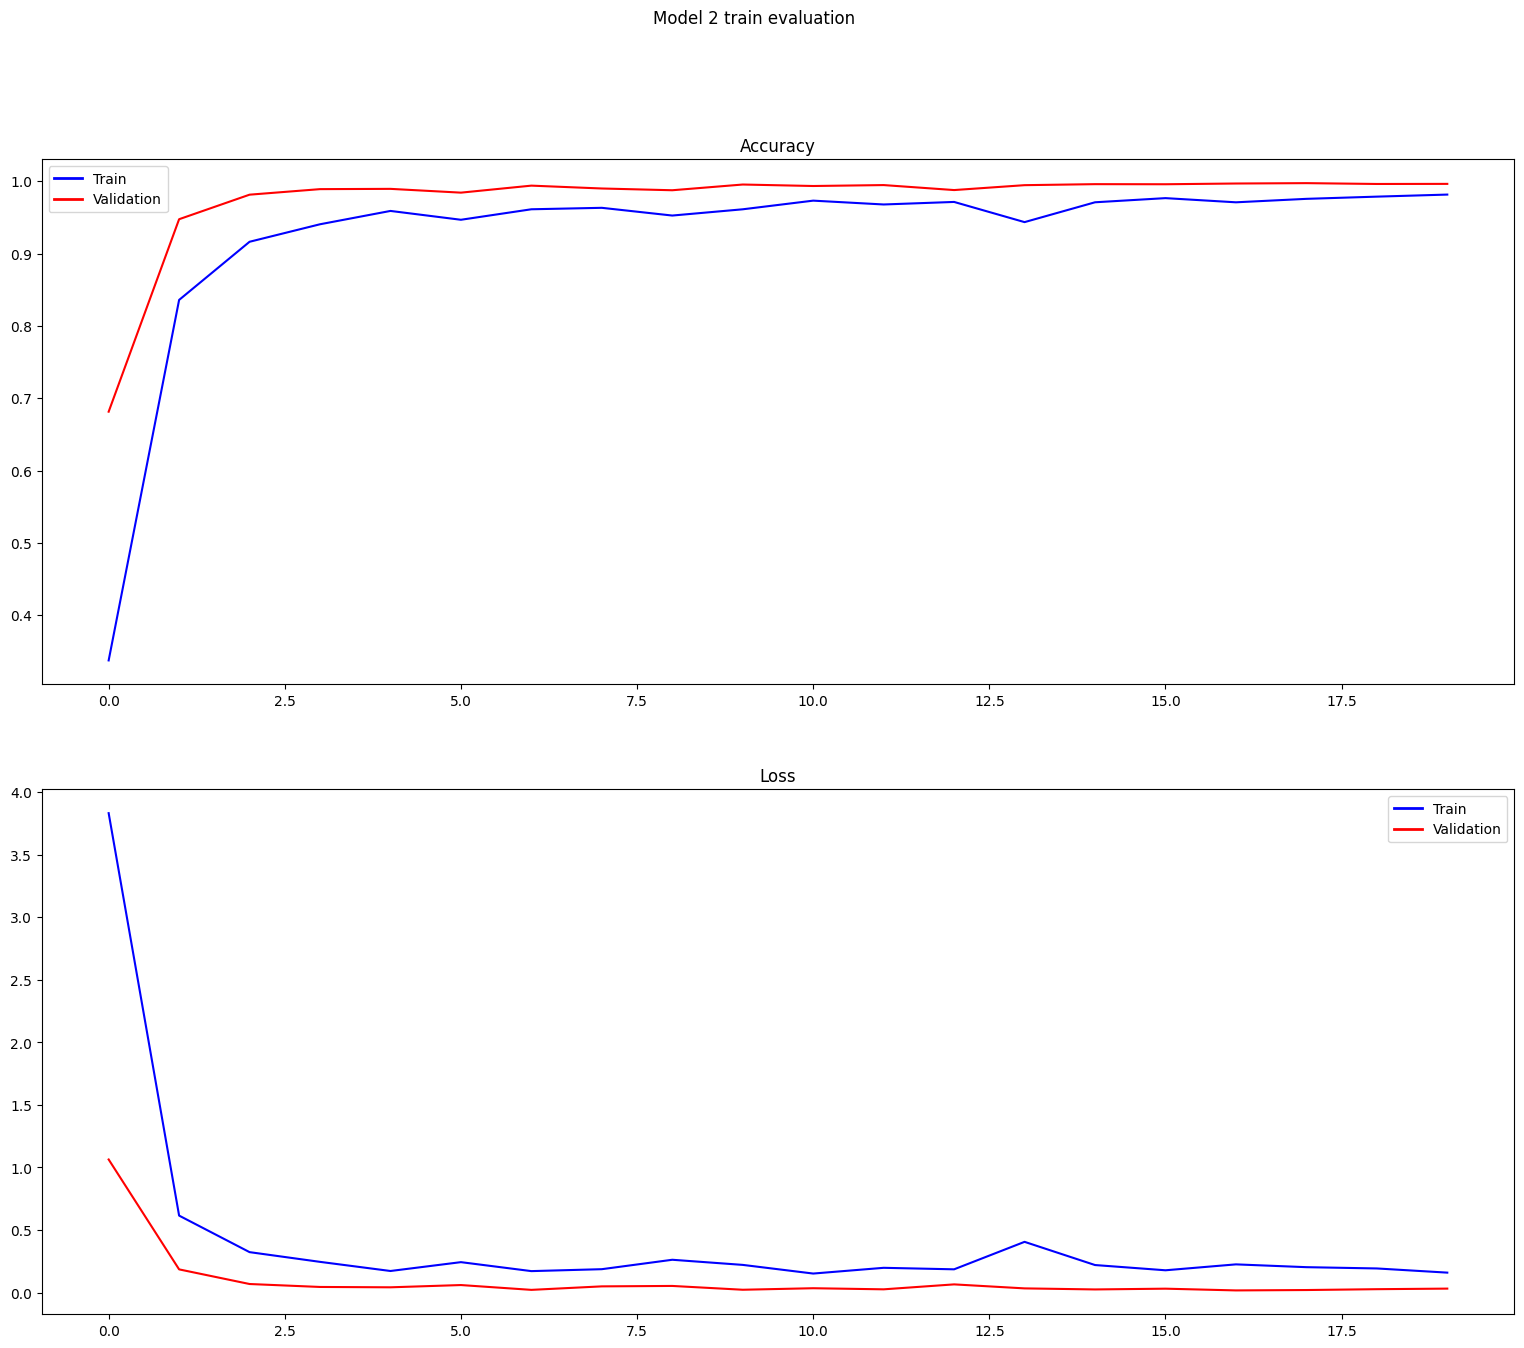

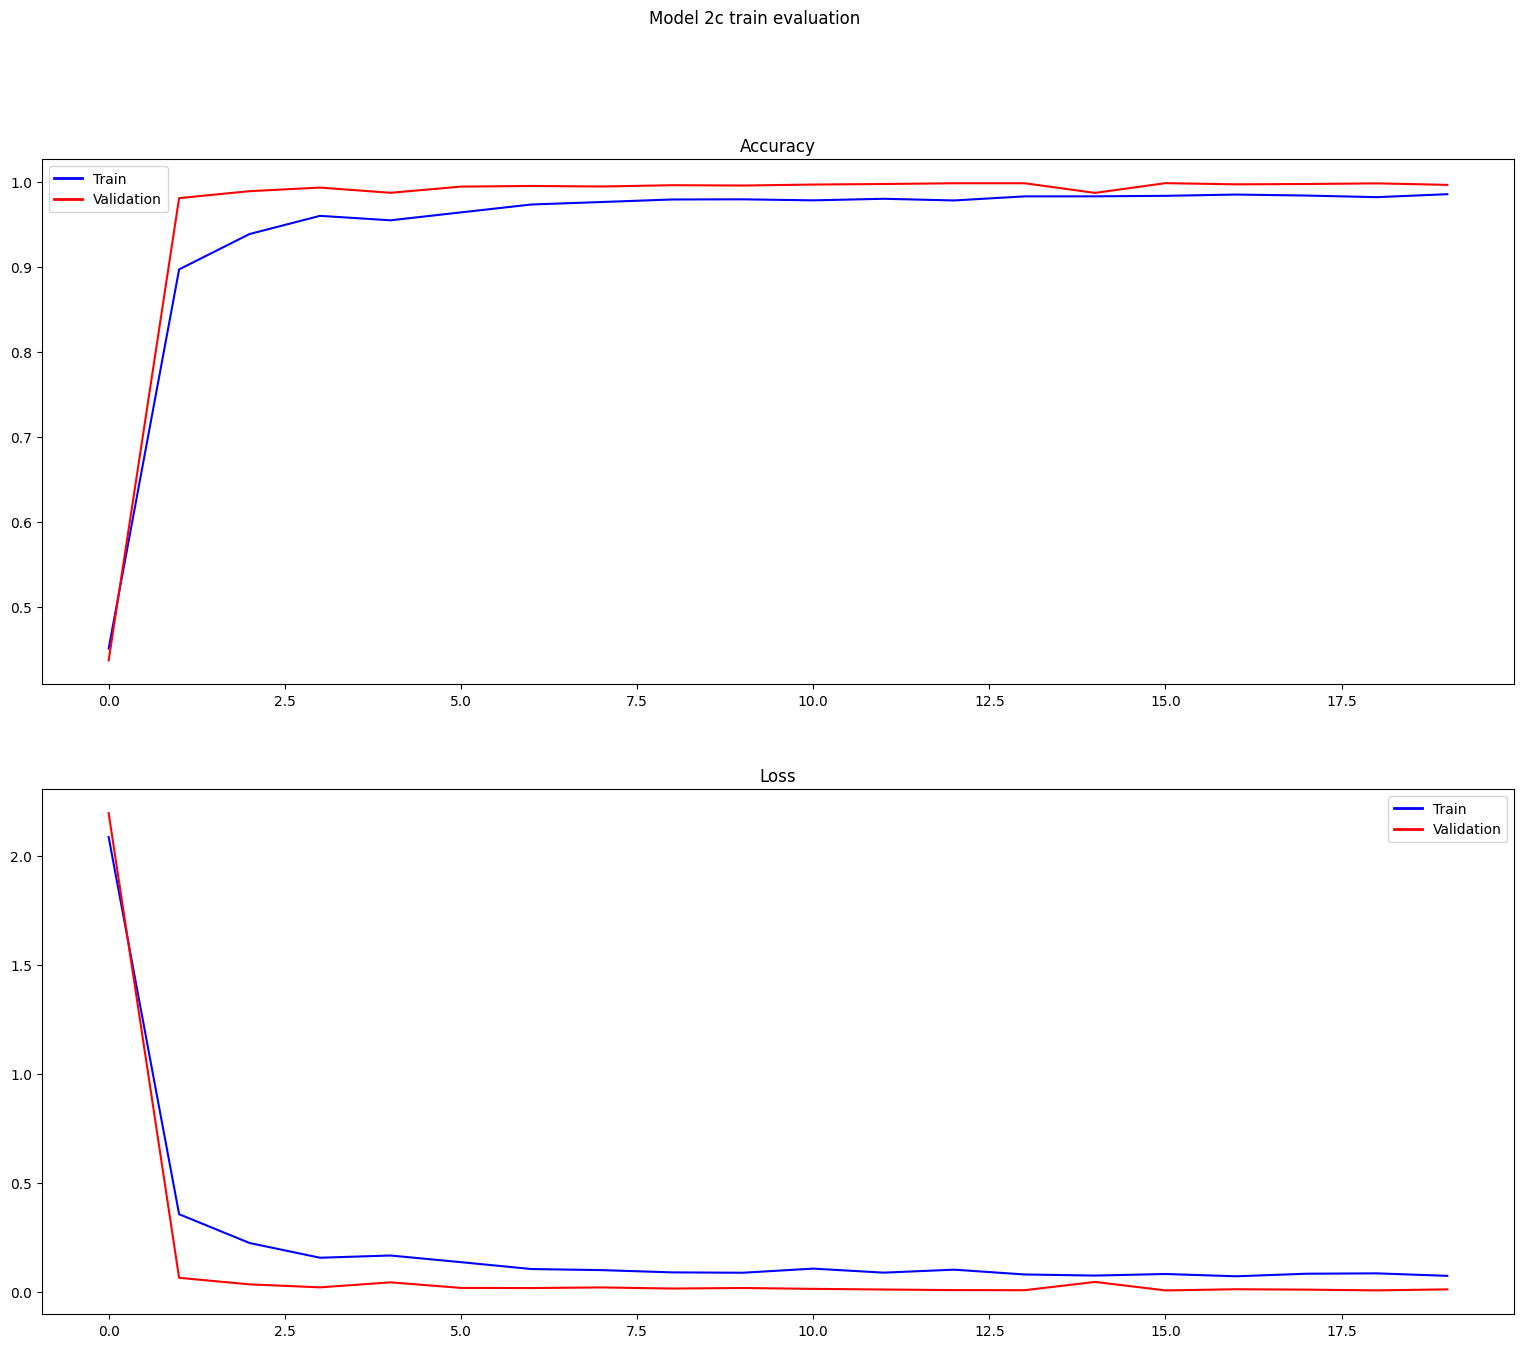

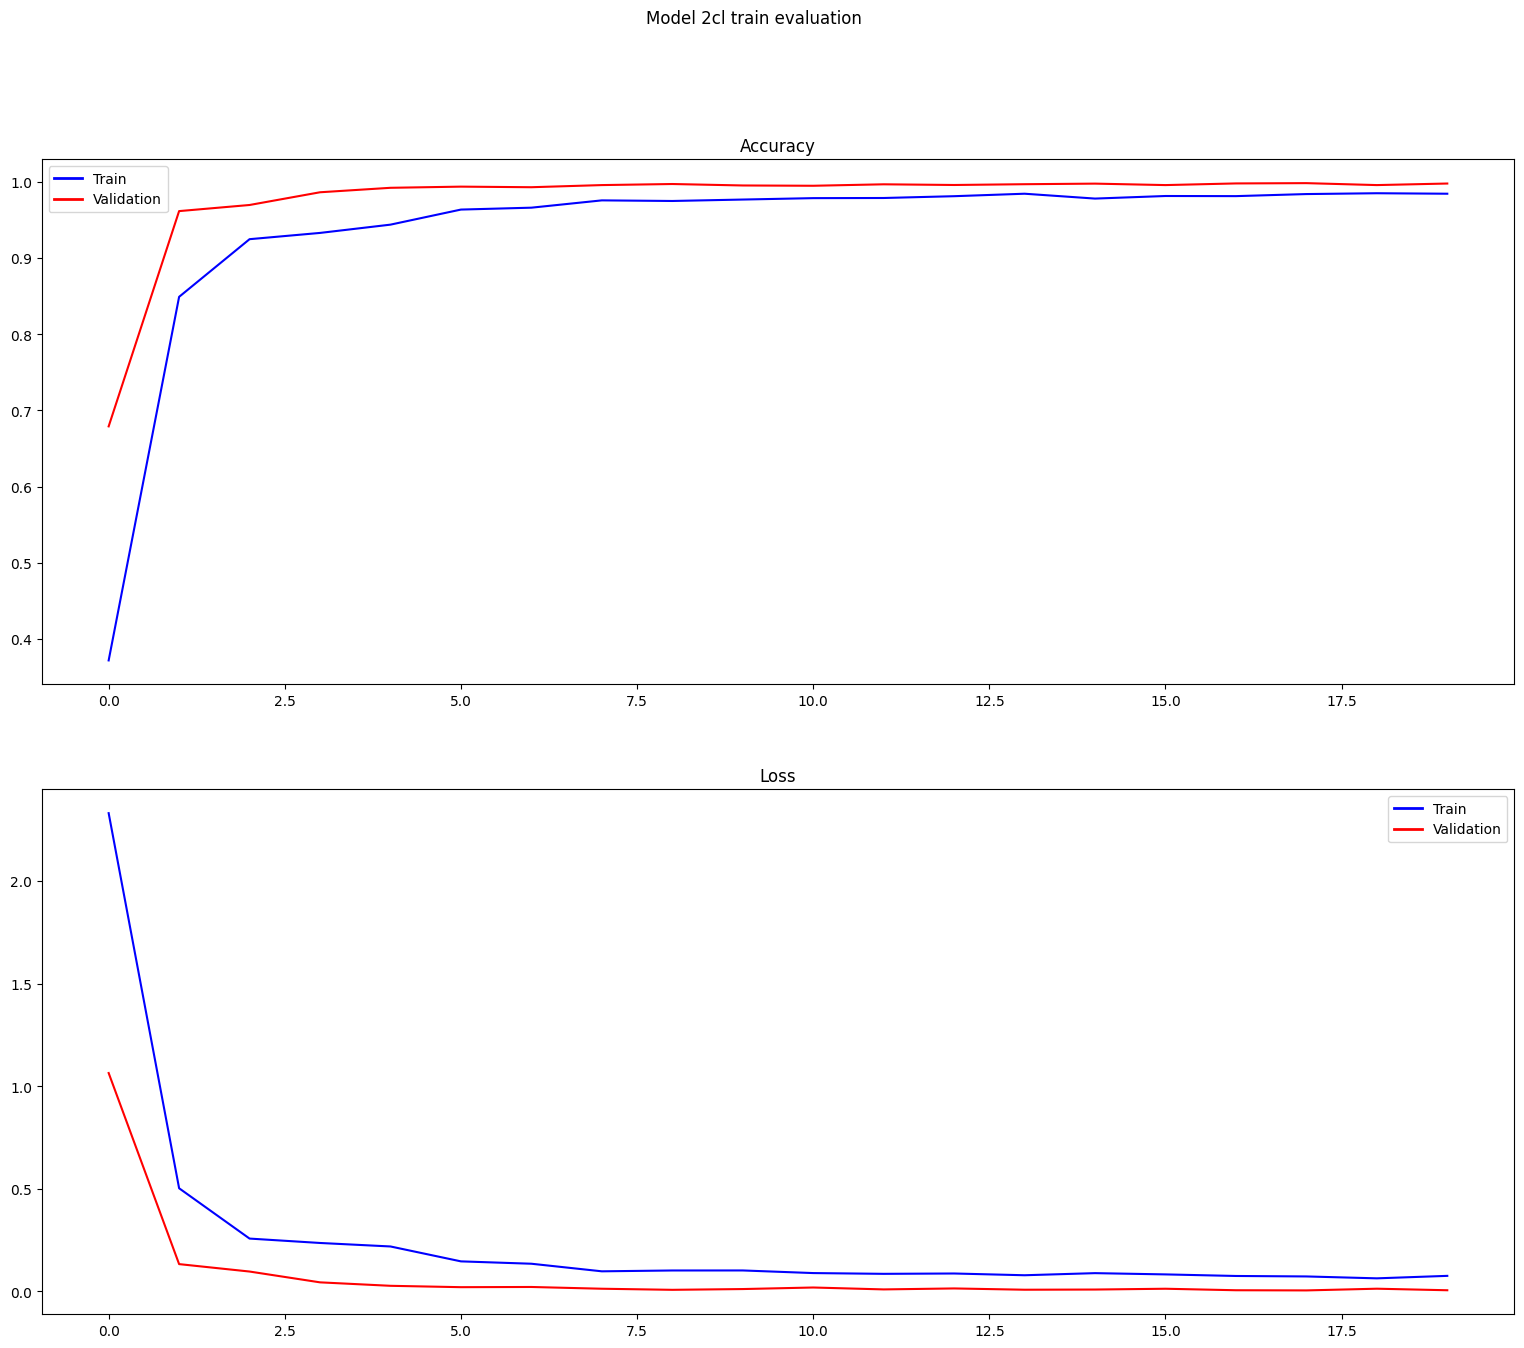

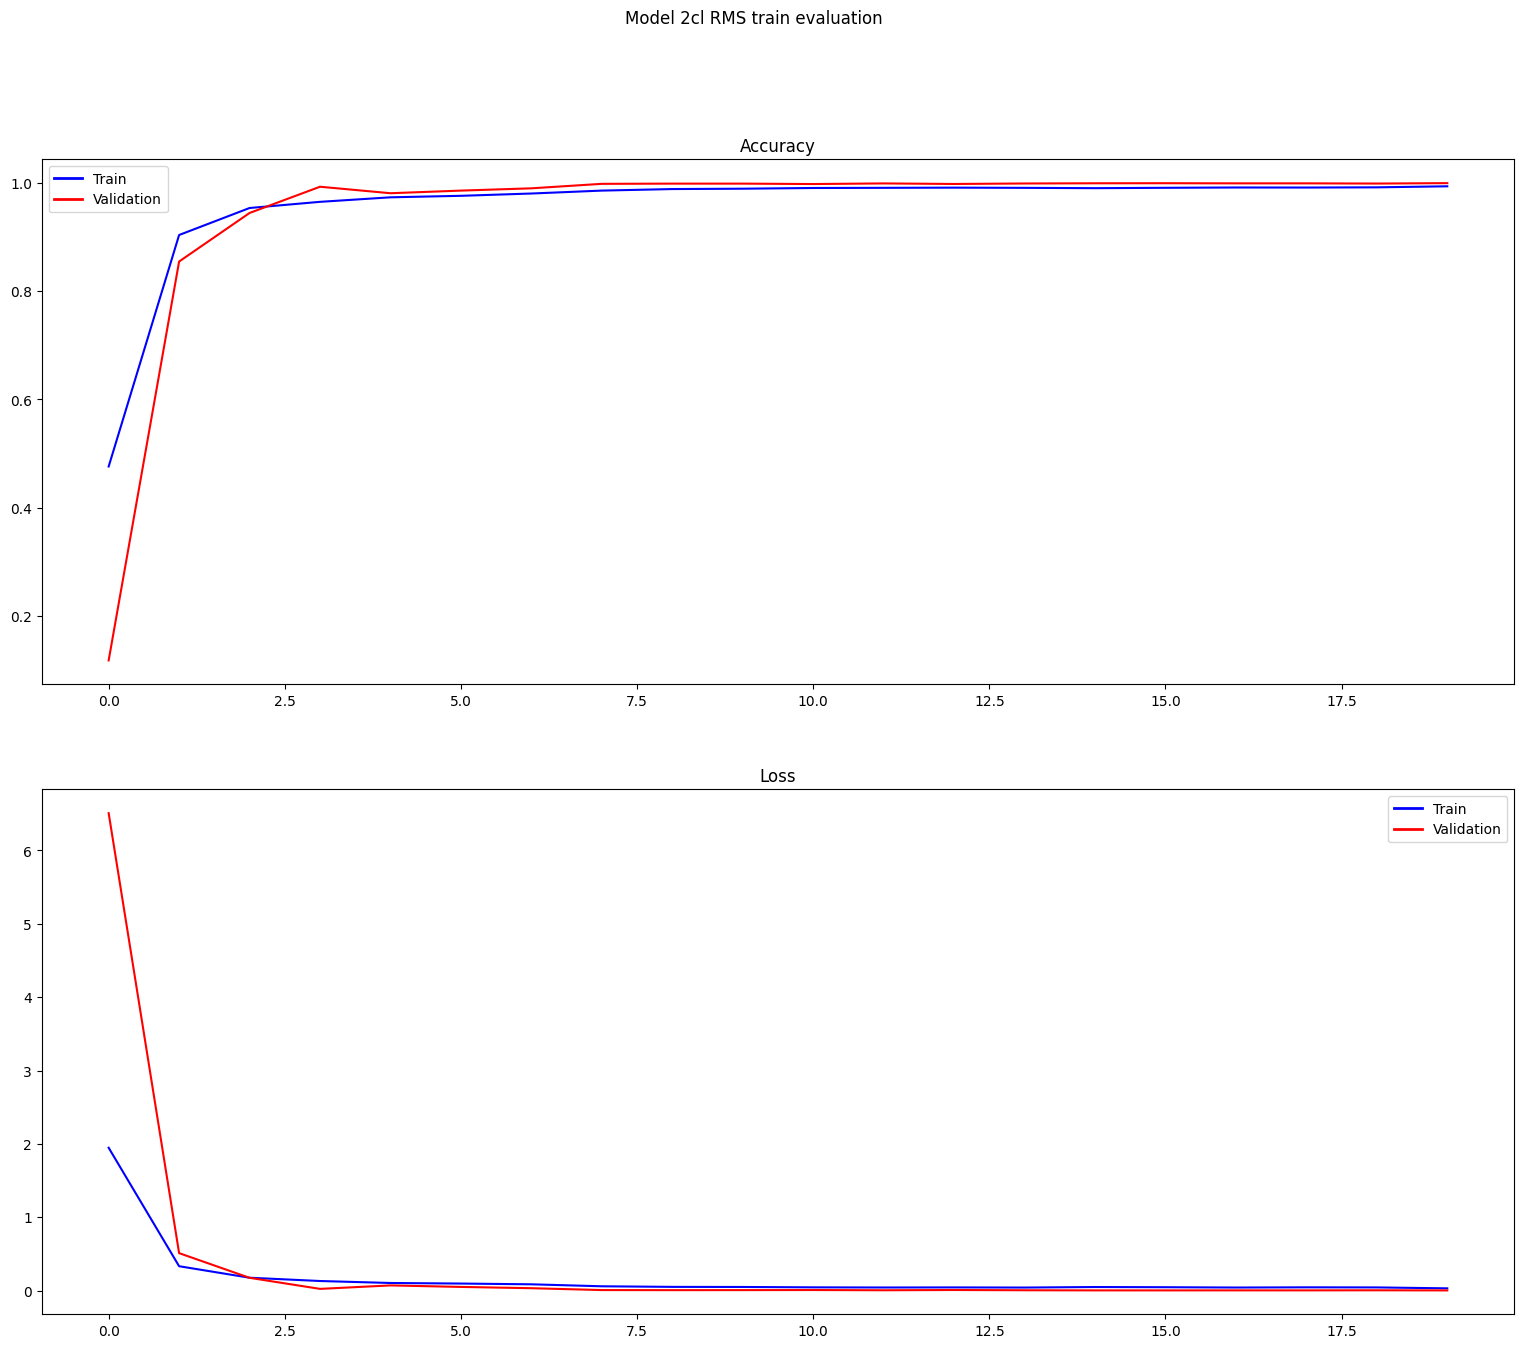

In [76]:
plot_training_history(history2, 'Model 2')
plot_training_history(history2c, 'Model 2c')
plot_training_history(history2cl, 'Model 2cl')
plot_training_history(history2cl_RMS, 'Model 2cl RMS')


This is plotting the accuracy and loss of 4 models that I found the most important from previous arhitectures 

this is the training

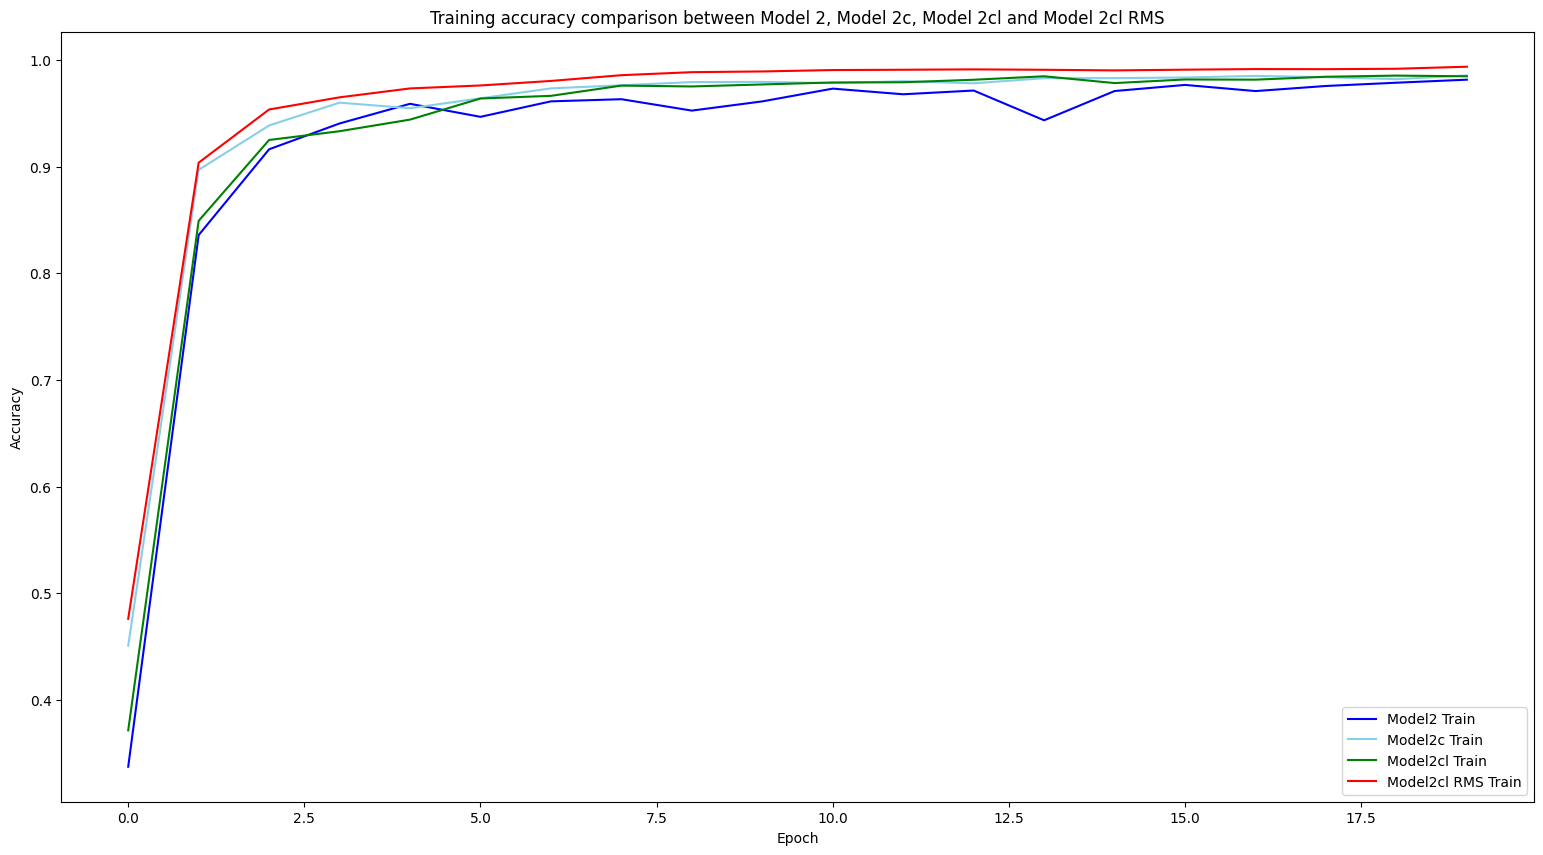

In [77]:
plt.figure(figsize=(19,10))

plt.plot(np.arange(0, len(history2.history['accuracy'])), history2.history['accuracy'], color='blue')
plt.plot(np.arange(0, len(history2c.history['accuracy'])), history2c.history['accuracy'], color='skyblue')
plt.plot(np.arange(0, len(history2cl.history['accuracy'])), history2cl.history['accuracy'], color='green')
plt.plot(np.arange(0, len(history2cl_RMS.history['accuracy'])), history2cl_RMS.history['accuracy'], color='red')

plt.title('Training accuracy comparison between Model 2, Model 2c, Model 2cl and Model 2cl RMS')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Model2 Train', 'Model2c Train', 'Model2cl Train', 'Model2cl RMS Train'])
plt.show()



This is the validation

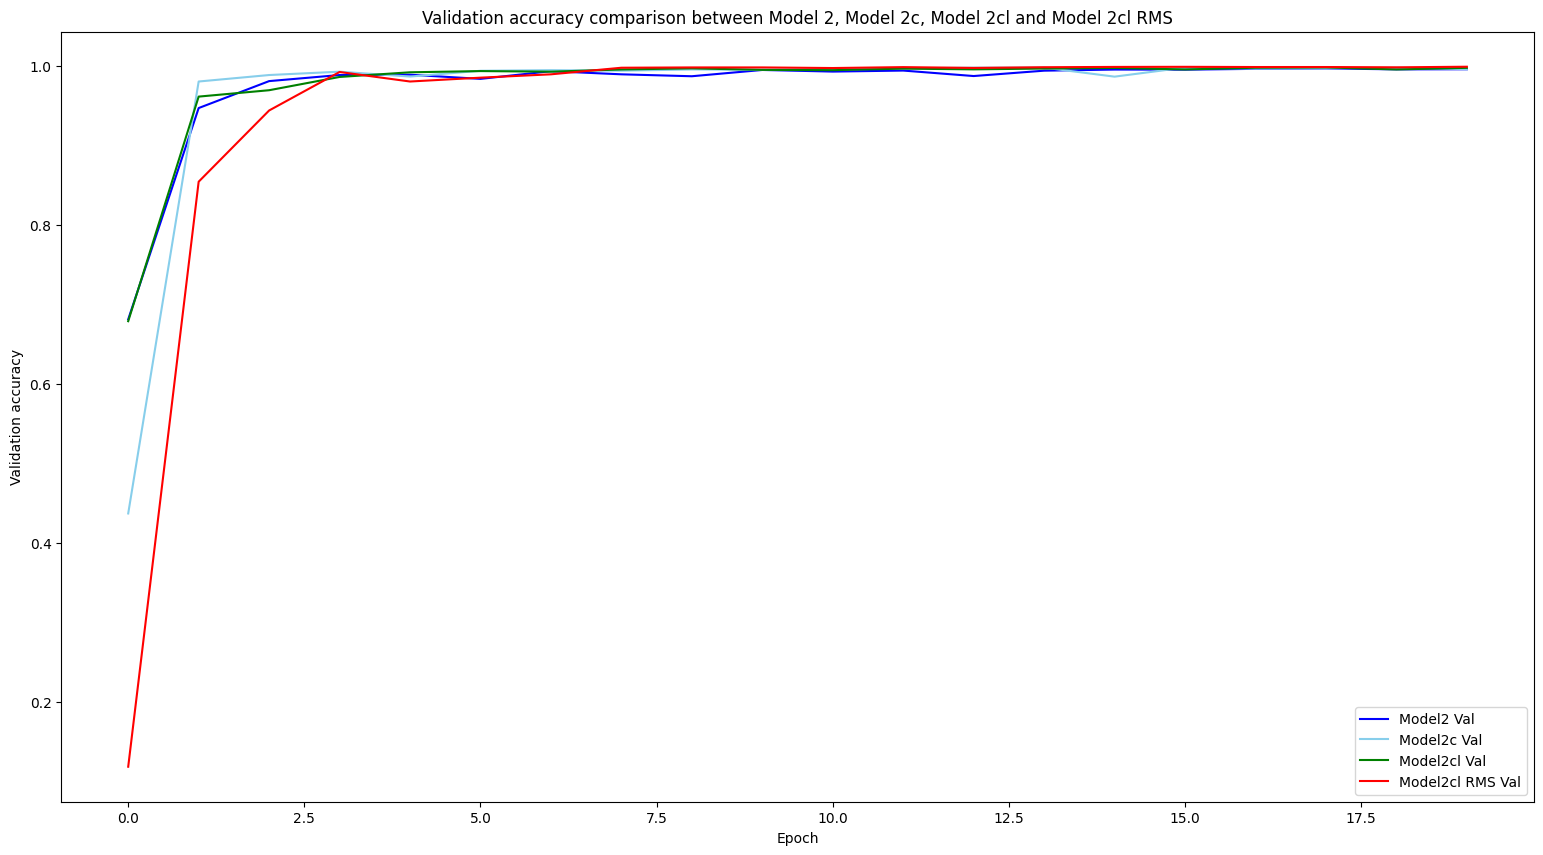

In [78]:
plt.figure(figsize=(19,10))

plt.plot(np.arange(0, len(history2.history['val_accuracy'])), history2.history['val_accuracy'], color='blue')
plt.plot(np.arange(0, len(history2c.history['val_accuracy'])), history2c.history['val_accuracy'], color='skyblue')
plt.plot(np.arange(0, len(history2cl.history['val_accuracy'])), history2cl.history['val_accuracy'], color='green')
plt.plot(np.arange(0, len(history2cl_RMS.history['val_accuracy'])), history2cl_RMS.history['val_accuracy'], color='red')

plt.title('Validation accuracy comparison between Model 2, Model 2c, Model 2cl and Model 2cl RMS')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.legend(['Model2 Val', 'Model2c Val', 'Model2cl Val', 'Model2cl RMS Val'])
plt.show()



we calculated the f1 score

In [79]:
from sklearn.metrics import f1_score

y_true = np.argmax(Y_test, axis=1)

y_pred2 = np.argmax(model2.predict(X_test), axis=1)
y_pred2c = np.argmax(model2c.predict(X_test), axis=1)
y_pred2cl = np.argmax(model2cl.predict(X_test), axis=1)
y_pred2cl_RMS = np.argmax(model2cl_RMS.predict(X_test), axis=1)

f1_results = pd.DataFrame({
    'Model': ['Model 2', 'Model 2c', 'Model 2cl', 'Model 2cl RMS'],
    'F1 Macro': [
        f1_score(y_true, y_pred2, average='macro'),
        f1_score(y_true, y_pred2c, average='macro'),
        f1_score(y_true, y_pred2cl, average='macro'),
        f1_score(y_true, y_pred2cl_RMS, average='macro')
    ],
    # this is for class imbalance which suits best, since our dataset is imbalanced
    'F1 Weighted': [
        f1_score(y_true, y_pred2, average='weighted'),
        f1_score(y_true, y_pred2c, average='weighted'),
        f1_score(y_true, y_pred2cl, average='weighted'),
        f1_score(y_true, y_pred2cl_RMS, average='weighted')
    ]
})

f1_results



395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


,Model,F1 Macro,F1 Weighted
0,Model 2,0.956836,0.972467
1,Model 2c,0.955787,0.972079
2,Model 2cl,0.966954,0.979955
3,Model 2cl RMS,0.979394,0.988191


confusion matrix for the models

This is again the function that is helping me plot the confusion matrices for each model

In [80]:
from sklearn.metrics import confusion_matrix

def get_confusion_df(model, X_test, Y_test, normalize='true'):
    y_true = np.argmax(Y_test, axis=1)  # from one-hot encoding back to class numbers
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)  # predicted class for the test images

    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    cm_df = pd.DataFrame(cm)

    return cm_df, y_true, y_pred


This is the plot for all 4 models I used (the same as before)

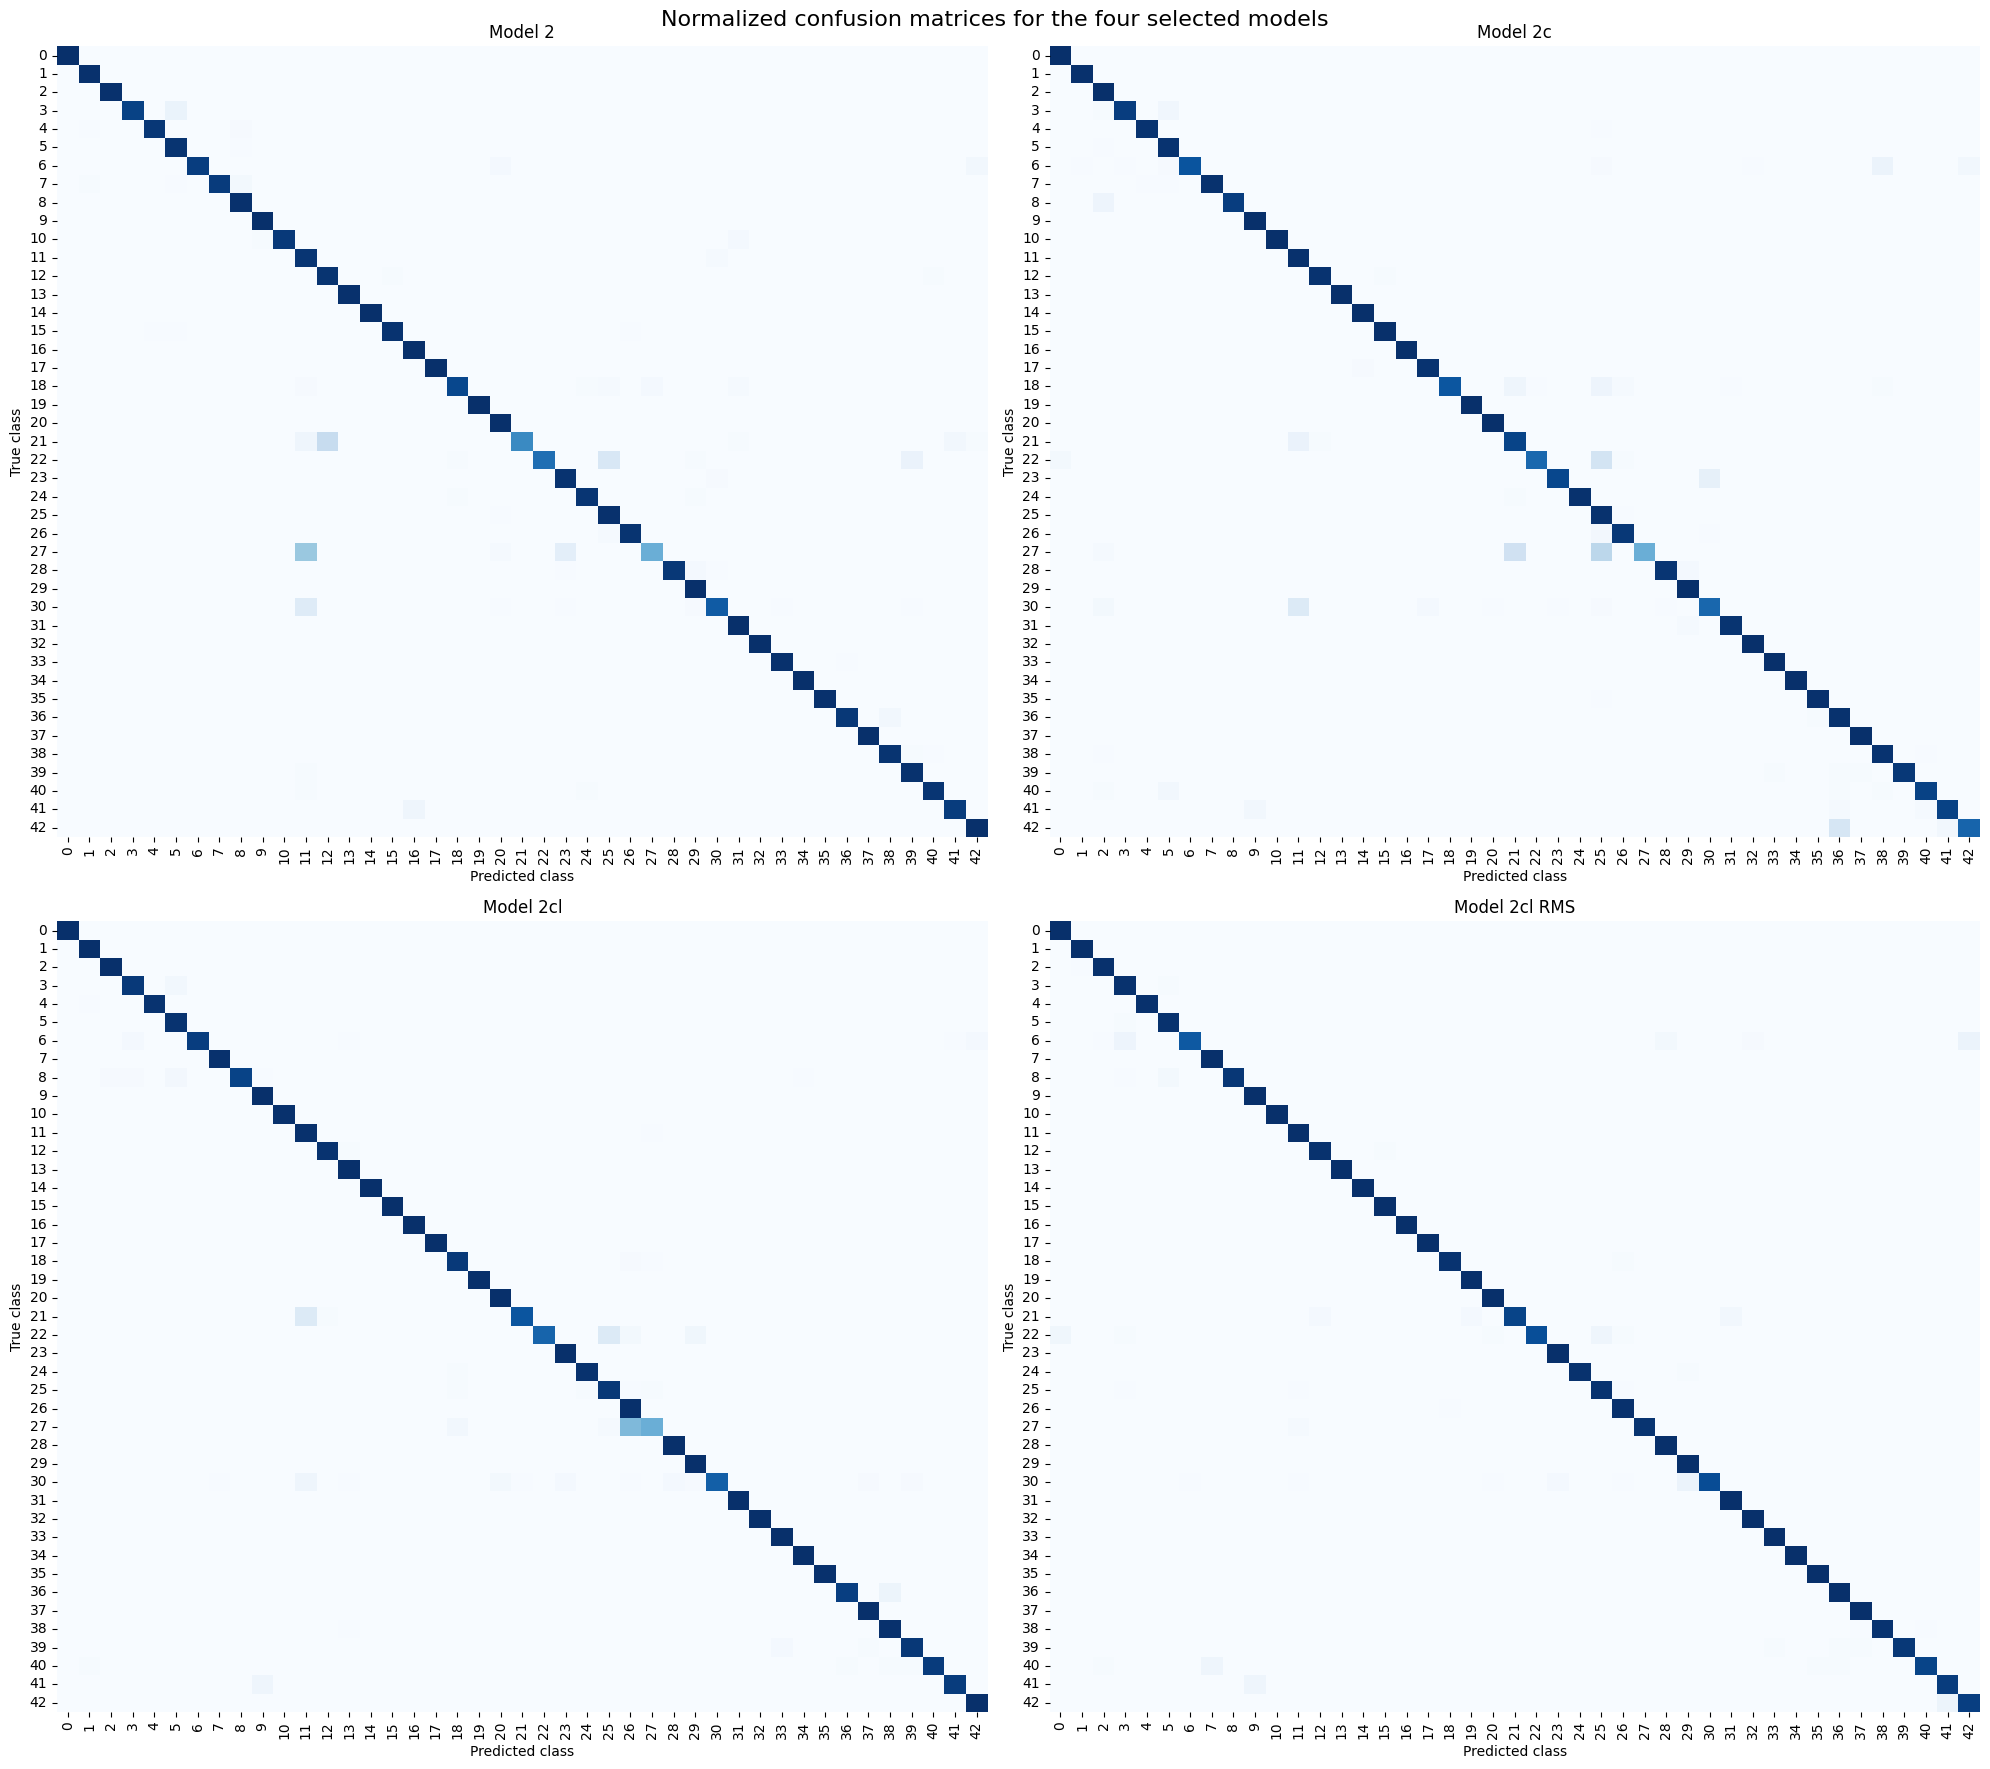

In [81]:
models_to_compare = [
    ('Model 2', model2),
    ('Model 2c', model2c),
    ('Model 2cl', model2cl),
    ('Model 2cl RMS', model2cl_RMS)
]

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('Normalized confusion matrices for the four selected models', fontsize=16)

for ax, (model_name, model) in zip(axes.flat, models_to_compare):
    cm_df, y_true, y_pred = get_confusion_df(model, X_test, Y_test, normalize='true')

    sns.heatmap(
        cm_df,
        ax=ax,
        cmap='Blues',
        cbar=False
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')

plt.tight_layout()
plt.show()


This plots it with numbers

In [82]:
cm2cl_RMS_df, y_true, y_pred2cl_RMS = get_confusion_df(model2cl_RMS, X_test, Y_test, normalize=None)
cm2cl_RMS_df


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,60,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,720,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,3,746,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,445,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,0,0,656,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,1,5,0,623,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,1,8,0,0,126,0,0,0,...,0,0,0,0,0,0,0,0,0,9
7,0,0,0,0,0,1,0,449,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,2,0,12,0,0,436,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,480,...,0,0,0,0,0,0,0,0,0,0


The table with the actual class name, with the predicted class name and how many it mistakes happened for the model

This is the function that will help us plot all the tables for the models we specify

In [83]:
def get_wrong_predictions_df(model, X_test, Y_test, class_names):
    y_true = np.argmax(Y_test, axis=1)  # from one-hot encoding back to the class numbers
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)  # predicted class for the test images

    cm = confusion_matrix(y_true, y_pred)

    wrong_predictions = []

    for actual_class in range(cm.shape[0]):  # this loops through all rows of confusion matrix
        for predicted_class in range(cm.shape[1]):  # this loops through all the columns of the confusion matrix
            count = cm[actual_class, predicted_class]  # this counts how many times actual class was predicted as predicted class

            if actual_class != predicted_class and count > 0:  # keep only the wrong ones
                wrong_predictions.append({
                    'Actual ClassId': actual_class,
                    'Predicted ClassId': predicted_class,
                    'Actual Class Name': class_names[actual_class],
                    'Predicted Class Name': class_names[predicted_class],
                    'Count': count
                })

    wrong_df = pd.DataFrame(wrong_predictions).sort_values('Count', ascending=False)

    return wrong_df, y_true, y_pred


In [84]:
wrong_df_2, y_true, y_pred2 = get_wrong_predictions_df(model2, X_test, Y_test, class_names)
wrong_df_2c, _, y_pred2c = get_wrong_predictions_df(model2c, X_test, Y_test, class_names)
wrong_df_2cl, _, y_pred2cl = get_wrong_predictions_df(model2cl, X_test, Y_test, class_names)
wrong_df_2cl_RMS, _, y_pred2cl_RMS = get_wrong_predictions_df(model2cl_RMS, X_test, Y_test, class_names)


This prints it

In [86]:
print("Model 2")
display(wrong_df_2.head(10))

print("Model 2c")
display(wrong_df_2c.head(10))

print("Model 2cl")
display(wrong_df_2cl.head(10))

print("Model 2cl RMS")
display(wrong_df_2cl_RMS.head(10))


Model 2


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
5,3,5,Speed limit (60),Speed limit (80),29
69,27,11,Pedestrians,Right-of-way,23
55,21,12,Double curve,Priority road,22
60,22,25,Bumpy road,Road work,19
75,30,11,Ice/snow,Right-of-way,19
34,10,31,No passing >3.5t,Wild animals,13
27,7,8,Speed limit (100),Speed limit (120),12
10,4,8,Speed limit (70),Speed limit (120),10
86,38,39,Keep right,Keep left,8
37,11,30,Right-of-way,Ice/snow,8


Model 2c


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
28,8,2,Speed limit (120),Speed limit (50),23
55,22,25,Bumpy road,Road work,22
69,30,11,Ice/snow,Right-of-way,20
47,18,25,General caution,Road work,20
66,27,25,Pedestrians,Road work,17
5,3,5,Speed limit (60),Speed limit (80),17
44,18,21,General caution,Double curve,17
93,42,36,End no passing >3.5t,Go straight/right,15
57,23,30,Slippery road,Ice/snow,13
65,27,21,Pedestrians,Double curve,12


Model 2cl


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
56,27,26,Pedestrians,Traffic signals,27
46,22,25,Bumpy road,Road work,16
1,3,5,Speed limit (60),Speed limit (80),15
23,8,5,Speed limit (120),Speed limit (80),13
44,21,11,Double curve,Right-of-way,12
30,12,13,Priority road,Yield,8
22,8,3,Speed limit (120),Speed limit (60),7
21,8,2,Speed limit (120),Speed limit (50),7
71,36,38,Go straight/right,Keep right,7
58,30,11,Ice/snow,Right-of-way,7


Model 2cl RMS


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
17,8,5,Speed limit (120),Speed limit (80),12
44,30,29,Ice/snow,Bicycles crossing,9
14,6,42,End speed limit(80),End no passing >3.5t,9
11,6,3,End speed limit(80),Speed limit (60),8
30,22,25,Bumpy road,Road work,6
19,12,15,Priority road,No vehicles,6
9,5,3,Speed limit (80),Speed limit (60),5
27,22,0,Bumpy road,Speed limit (20),5
59,42,41,End no passing >3.5t,End no passing,5
23,18,26,General caution,Traffic signals,4


This is only to see all the complete tables

In [87]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Model 2")
display(wrong_df_2)

print("Model 2c")
display(wrong_df_2c)

print("Model 2cl")
display(wrong_df_2cl)

print("Model 2cl RMS")
display(wrong_df_2cl_RMS)



Model 2


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
5,3,5,Speed limit (60),Speed limit (80),29
69,27,11,Pedestrians,Right-of-way,23
55,21,12,Double curve,Priority road,22
60,22,25,Bumpy road,Road work,19
75,30,11,Ice/snow,Right-of-way,19
34,10,31,No passing >3.5t,Wild animals,13
27,7,8,Speed limit (100),Speed limit (120),12
10,4,8,Speed limit (70),Speed limit (120),10
86,38,39,Keep right,Keep left,8
37,11,30,Right-of-way,Ice/snow,8


Model 2c


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
28,8,2,Speed limit (120),Speed limit (50),23
55,22,25,Bumpy road,Road work,22
69,30,11,Ice/snow,Right-of-way,20
47,18,25,General caution,Road work,20
66,27,25,Pedestrians,Road work,17
5,3,5,Speed limit (60),Speed limit (80),17
44,18,21,General caution,Double curve,17
93,42,36,End no passing >3.5t,Go straight/right,15
57,23,30,Slippery road,Ice/snow,13
65,27,21,Pedestrians,Double curve,12


Model 2cl


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
56,27,26,Pedestrians,Traffic signals,27
46,22,25,Bumpy road,Road work,16
1,3,5,Speed limit (60),Speed limit (80),15
23,8,5,Speed limit (120),Speed limit (80),13
44,21,11,Double curve,Right-of-way,12
30,12,13,Priority road,Yield,8
22,8,3,Speed limit (120),Speed limit (60),7
21,8,2,Speed limit (120),Speed limit (50),7
71,36,38,Go straight/right,Keep right,7
58,30,11,Ice/snow,Right-of-way,7


Model 2cl RMS


,Actual ClassId,Predicted ClassId,Actual Class Name,Predicted Class Name,Count
17,8,5,Speed limit (120),Speed limit (80),12
44,30,29,Ice/snow,Bicycles crossing,9
14,6,42,End speed limit(80),End no passing >3.5t,9
11,6,3,End speed limit(80),Speed limit (60),8
30,22,25,Bumpy road,Road work,6
19,12,15,Priority road,No vehicles,6
9,5,3,Speed limit (80),Speed limit (60),5
27,22,0,Bumpy road,Speed limit (20),5
59,42,41,End no passing >3.5t,End no passing,5
23,18,26,General caution,Traffic signals,4


In [88]:
wrong_by_actual_class_2 = wrong_df_2.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)
wrong_by_actual_class_2c = wrong_df_2c.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)
wrong_by_actual_class_2cl = wrong_df_2cl.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)
wrong_by_actual_class_2cl_RMS = wrong_df_2cl_RMS.groupby('Actual Class Name')['Count'].sum().sort_values(ascending=False)



Compared with the wrong-prediction table that shows specific confusion pairs, this tables shows the total number of mistakes for each actual class. This separates “what was confused with what” from “which classes were hardest overall”.


In [89]:
wrong_by_actual_class_df = pd.concat([
    wrong_by_actual_class_2.rename('Model 2'),
    wrong_by_actual_class_2c.rename('Model 2c'),
    wrong_by_actual_class_2cl.rename('Model 2cl'),
    wrong_by_actual_class_2cl_RMS.rename('Model 2cl RMS')
], axis=1).fillna(0).astype(int)

wrong_by_actual_class_df


,Model 2,Model 2c,Model 2cl,Model 2cl RMS
Actual Class Name,,,,
General caution,34,57,15,6
Speed limit (60),31,24,17,5
Double curve,31,7,13,7
Pedestrians,30,30,30,1
Bumpy road,29,26,24,14
Ice/snow,25,32,27,16
No passing >3.5t,24,2,3,0
Speed limit (70),20,8,10,4
Speed limit (100),20,5,3,1


In [90]:
wrong_by_actual_class_df['Total'] = wrong_by_actual_class_df.sum(axis=1)
wrong_by_actual_class_df = wrong_by_actual_class_df.sort_values('Total', ascending=False)
wrong_by_actual_class_df


,Model 2,Model 2c,Model 2cl,Model 2cl RMS,Total
Actual Class Name,,,,,
General caution,34,57,15,6,112
Ice/snow,25,32,27,16,100
Bumpy road,29,26,24,14,93
Pedestrians,30,30,30,1,91
Speed limit (60),31,24,17,5,77
Speed limit (120),2,24,32,14,72
End speed limit(80),8,21,8,24,61
Double curve,31,7,13,7,58
Speed limit (70),20,8,10,4,42


The functions to calculate the time of the two models

In [92]:
import time
from tensorflow.keras.callbacks import Callback

class TimeHistory(Callback): # the parent class is the import from the above
    def on_train_begin(self, logs=None):
        self.epoch_times = [] #this will store each epoch time
        self.train_start = time.time() #this store the exact time of starting the training

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time() #this stores the time when each epoch starts

    def on_epoch_end(self, epoch, logs=None): #this is called after each epochs end
        self.epoch_times.append(time.time() - self.epoch_start)  #this substract the current time from the starting time

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start # this does the same thing, but for the total


This run again the models and it measure, their time also

In [96]:
timer2cl = TimeHistory()
history2cl = model2cl.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[timer2cl]
)

timer2cll = TimeHistory()
history2cll = model2cll.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[timer2cll]
)

timer2cl_RMS = TimeHistory()
history2cl_RMS = model2cl_RMS.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, Y_val),
    callbacks=[timer2cl_RMS]
)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.9882 - loss: 0.0619 - val_accuracy: 0.9987 - val_loss: 0.0029
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9903 - loss: 0.0536 - val_accuracy: 0.9989 - val_loss: 0.0034
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9896 - loss: 0.0488 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.9910 - loss: 0.0549 - val_accuracy: 0.9987 - val_loss: 0.0055
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.9911 - loss: 0.0471 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9923 - loss: 0.0379 - val_accuracy: 0.9992 - val_loss: 0.0018
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9906 - loss: 0.0460 - val_accuracy: 0.9990 - val_loss: 0.0042
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9923 - loss: 0.0370 - 

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Model 2cl', 'Model 2cll', 'Model 2cl RMS'],  # these are the model names
    'Parameters': [
        model2cl.count_params(),
        model2cll.count_params(),
        model2cl_RMS.count_params()
    ],  # how many parameters each has
    'Total Training Time (s)': [
        timer2cl.total_time,
        timer2cll.total_time,
        timer2cl_RMS.total_time
    ],  # calculates the total time
    'Average Epoch Time (s)': [
        sum(timer2cl.epoch_times) / len(timer2cl.epoch_times),
        sum(timer2cll.epoch_times) / len(timer2cll.epoch_times),
        sum(timer2cl_RMS.epoch_times) / len(timer2cl_RMS.epoch_times)
    ],  # calculates the average epoch time
    'Final Val Accuracy': [
        history2cl.history['val_accuracy'][-1],
        history2cll.history['val_accuracy'][-1],
        history2cl_RMS.history['val_accuracy'][-1]
    ]  # this -1 takes only the last validation accuracy
})

comparison_df

,Model,Parameters,Total Training Time (s),Average Epoch Time (s),Final Val Accuracy
0,Model 2cl,605643,731.452765,36.563526,0.998979
1,Model 2cll,160507,577.356464,28.860501,0.997959
2,Model 2cl RMS,605643,595.239774,29.751171,0.999617


We plot now what we did above

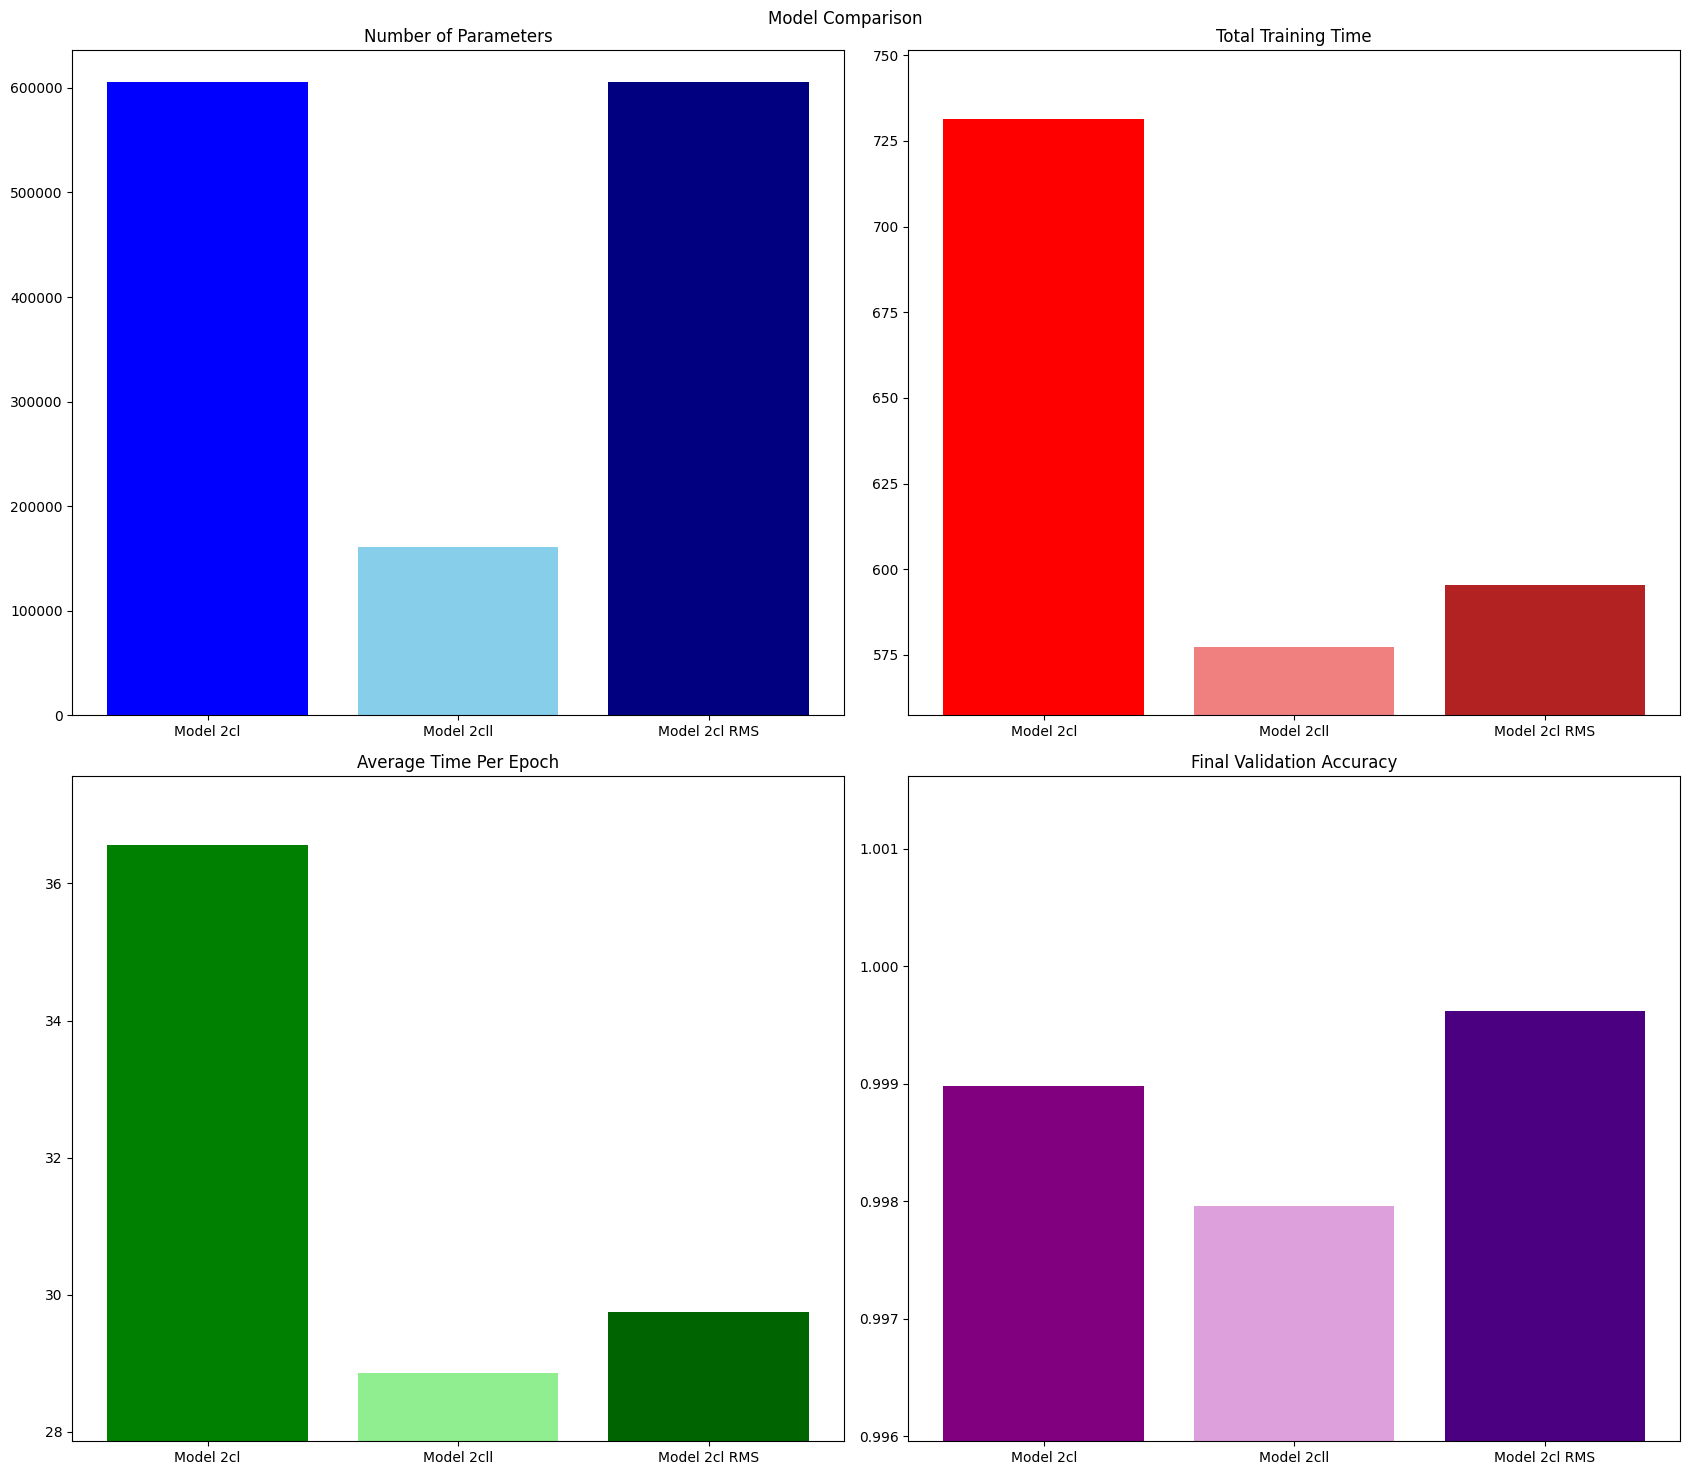

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(17, 15))
fig.suptitle('Model Comparison')

# Number of parameters
ax[0,0].bar(comparison_df['Model'], comparison_df['Parameters'], color=['blue', 'skyblue', 'navy'])
ax[0,0].set_title('Number of Parameters')

# Total training time
ax[0,1].bar(comparison_df['Model'], comparison_df['Total Training Time (s)'], color=['red', 'lightcoral', 'firebrick'])
ax[0,1].set_title('Total Training Time')

time_min = comparison_df['Total Training Time (s)'].min()
time_max = comparison_df['Total Training Time (s)'].max()
time_margin = 20
ax[0,1].set_ylim(time_min - time_margin, time_max + time_margin)

# Average epoch time
ax[1,0].bar(comparison_df['Model'], comparison_df['Average Epoch Time (s)'], color=['green', 'lightgreen', 'darkgreen'])
ax[1,0].set_title('Average Time Per Epoch')

epoch_min = comparison_df['Average Epoch Time (s)'].min()
epoch_max = comparison_df['Average Epoch Time (s)'].max()
epoch_margin = 1
ax[1,0].set_ylim(epoch_min - epoch_margin, epoch_max + epoch_margin)

# Final validation accuracy
ax[1,1].bar(comparison_df['Model'], comparison_df['Final Val Accuracy'], color=['purple', 'plum', 'indigo'])
ax[1,1].set_title('Final Validation Accuracy')

val_min = comparison_df['Final Val Accuracy'].min()
val_max = comparison_df['Final Val Accuracy'].max()
val_margin = 0.002
ax[1,1].set_ylim(val_min - val_margin, val_max + val_margin)

plt.tight_layout()
plt.show()

relative parameters and time to Model 2cl

In [ ]:
reference_params = comparison_df.loc[comparison_df['Model'] == 'Model 2cl', 'Parameters'].iloc[0]
reference_time = comparison_df.loc[comparison_df['Model'] == 'Model 2cl', 'Total Training Time (s)'].iloc[0]

comparison_df['Parameters Relative to Model 2cl'] = comparison_df['Parameters'] / reference_params
comparison_df['Training Time Relative to Model 2cl'] = comparison_df['Total Training Time (s)'] / reference_time

comparison_df

,Model,Parameters,Total Training Time (s),Average Epoch Time (s),Final Val Accuracy,Parameters Relative to Model 2cl,Training Time Relative to Model 2cl
0,Model 2cl,605643,731.452765,36.563526,0.998979,1.000000,1.000000
1,Model 2cll,160507,577.356464,28.860501,0.997959,0.265019,0.789328
2,Model 2cl RMS,605643,595.239774,29.751171,0.999617,1.000000,0.813777


This code compares the final models in terms of model size, training time, and validation accuracy

In [ ]:
param_diff_2cl_vs_2cll = model2cl.count_params() - model2cll.count_params()  # how many more parameters Model 2cl has than Model 2cll
time_diff_2cl_vs_2cll = timer2cl.total_time - timer2cll.total_time  # how much longer Model 2cl trained than Model 2cll
acc_diff_2cl_vs_2cll = history2cl.history['val_accuracy'][-1] - history2cll.history['val_accuracy'][-1]  # final validation accuracy difference

param_diff_2cl_vs_RMS = model2cl.count_params() - model2cl_RMS.count_params()  # how many more parameters Model 2cl has than Model 2cl RMS
time_diff_2cl_vs_RMS = timer2cl.total_time - timer2cl_RMS.total_time  # how much longer Model 2cl trained than Model 2cl RMS
acc_diff_2cl_vs_RMS = history2cl.history['val_accuracy'][-1] - history2cl_RMS.history['val_accuracy'][-1]  # final validation accuracy difference

print("Parameter difference (Model 2cl - Model 2cll):", param_diff_2cl_vs_2cll)
print("Total training time difference in seconds (Model 2cl - Model 2cll):", round(time_diff_2cl_vs_2cll, 2))
print("Final validation accuracy difference (Model 2cl - Model 2cll):", round(acc_diff_2cl_vs_2cll, 4))

print()

print("Parameter difference (Model 2cl - Model 2cl RMS):", param_diff_2cl_vs_RMS)
print("Total training time difference in seconds (Model 2cl - Model 2cl RMS):", round(time_diff_2cl_vs_RMS, 2))
print("Final validation accuracy difference (Model 2cl - Model 2cl RMS):", round(acc_diff_2cl_vs_RMS, 4))

Parameter difference (Model 2cl - Model 2cll): 445136
Total training time difference in seconds (Model 2cl - Model 2cll): 154.1
Final validation accuracy difference (Model 2cl - Model 2cll): 0.001

Parameter difference (Model 2cl - Model 2cl RMS): 0
Total training time difference in seconds (Model 2cl - Model 2cl RMS): 136.21
Final validation accuracy difference (Model 2cl - Model 2cl RMS): -0.0006


Prediction and Evaluation

Here we use accuracy, classification report, confusion matrix and some class-wise plots to check the performance of the model.


Preparation of true and predicted labels for first models

In [ ]:
y_test_true = np.argmax(Y_test, axis=1) if len(Y_test.shape) > 1 else Y_test

y_pred_prob_2 = model2.predict(X_test)
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

y_pred_prob_2cl = model2cl.predict(X_test)
y_pred_2cl = np.argmax(y_pred_prob_2cl, axis=1)

y_pred_prob_2cll = model2cll.predict(X_test)
y_pred_2cll = np.argmax(y_pred_prob_2cll, axis=1)

y_pred_prob_2cl_RMS = model2cl_RMS.predict(X_test)
y_pred_2cl_RMS = np.argmax(y_pred_prob_2cl_RMS, axis=1)

y_pred_prob_res = model2cl_RMS_res.predict(X_test)
y_pred_res = np.argmax(y_pred_prob_res, axis=1)

y_pred_prob_inception = model2cl_RMS_inception.predict(X_test)
y_pred_inception = np.argmax(y_pred_prob_inception, axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step


This function prints the main accuracy summary for one model

In [ ]:
def print_model_accuracy(model, history, model_name, X_test, Y_test):
    y_test_true = np.argmax(Y_test, axis=1) if len(Y_test.shape) > 1 else Y_test
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print(
        f'{model_name}\n'
        f'- Accuracy achieved on test set: {accuracy_score(y_test_true, y_pred) * 100:.2f}%\n'
        f'- Final training accuracy: {history.history["accuracy"][-1] * 100:.2f}%\n'
        f'- Final validation accuracy: {history.history["val_accuracy"][-1] * 100:.2f}%\n'
    )

This code box is printing them

In [108]:
print_model_accuracy(model2, history2, 'Model 2', X_test, Y_test)
print_model_accuracy(model2cl, history2cl, 'Model 2cl', X_test, Y_test)
print_model_accuracy(model2cll, history2cll, 'Model 2cll', X_test, Y_test)
print_model_accuracy(model2cl_RMS, history2cl_RMS, 'Model 2cl RMS', X_test, Y_test)
print_model_accuracy(model2cl_RMS_res, history2cl_RMS_res, 'Model 2cl RMS ResNet', X_test, Y_test)
print_model_accuracy(model2cl_RMS_inception, history2cl_RMS_inception, 'Model 2cl RMS Inception', X_test, Y_test)


Model 2
- Accuracy achieved on test set: 97.30%
- Final training accuracy: 98.15%
- Final validation accuracy: 99.63%

Model 2cl
- Accuracy achieved on test set: 98.26%
- Final training accuracy: 99.19%
- Final validation accuracy: 99.90%

Model 2cll
- Accuracy achieved on test set: 98.08%
- Final training accuracy: 98.20%
- Final validation accuracy: 99.80%

Model 2cl RMS
- Accuracy achieved on test set: 98.74%
- Final training accuracy: 99.47%
- Final validation accuracy: 99.96%

Model 2cl RMS ResNet
- Accuracy achieved on test set: 97.34%
- Final training accuracy: 98.79%
- Final validation accuracy: 99.55%

Model 2cl RMS Inception
- Accuracy achieved on test set: 97.24%
- Final training accuracy: 97.24%
- Final validation accuracy: 99.55%



This table was done for the report 

In [165]:
# true labels
y_true = np.argmax(Y_test, axis=1)

models = [
    ("Model 2", model2, history2, 1_721_035),
    ("Model 2cl", model2cl, history2cl, 605_643),
    ("Model 2cll", model2cll, history2cll, 160_507),
    ("Model 2cl RMS", model2cl_RMS, history2cl_RMS, 605_643),
    ("RMS ResNet", model2cl_RMS_res, history2cl_RMS_res, 617_291),
    ("RMS Inception", model2cl_RMS_inception, history2cl_RMS_inception, 104_283),
]

rows = []

for name, model, history, params in models:
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    test_acc = accuracy_score(y_true, y_pred) * 100
    train_acc = history.history["accuracy"][-1] * 100
    val_acc = history.history["val_accuracy"][-1] * 100

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    rows.append({
        "Model": name,
        "Test": round(test_acc, 2),
        "Train": round(train_acc, 2),
        "Val.": round(val_acc, 2),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4)
    })

combined_results = pd.DataFrame(rows)
combined_results

,Model,Test,Train,Val.,Macro F1,Weighted F1
0,Model 2,97.30,98.15,99.63,0.9568,0.9725
1,Model 2cl,98.26,99.19,99.90,0.9696,0.9822
2,Model 2cll,98.08,98.20,99.80,0.9651,0.9806
3,Model 2cl RMS,98.74,99.47,99.96,0.9780,0.9872
4,RMS ResNet,97.34,98.79,99.55,0.9615,0.9734
5,RMS Inception,97.24,97.24,99.55,0.9513,0.9722


I will proceed further only with the models that have the highest test accuracy top 3

This function prints a detailed class-level evaluation(precisonm recall, f1 score and support) report for one model.

In [114]:
def print_classification_report(y_true, y_pred, model_name):
    num_classes = len(class_names)

    print(f'\nClassification report - {model_name}:\n')
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=[class_names[i] for i in range(num_classes)],
        zero_division=0
    ))

This prints it

In [115]:
print_classification_report(y_test_true, y_pred_2cl, 'Model 2cl')
print_classification_report(y_test_true, y_pred_2cll, 'Model 2cll')
print_classification_report(y_test_true, y_pred_2cl_RMS, 'Model 2cl RMS')


Classification report - Model 2cl:

                      precision    recall  f1-score   support

    Speed limit (20)       0.98      1.00      0.99        60
    Speed limit (30)       0.98      1.00      0.99       720
    Speed limit (50)       0.98      1.00      0.99       750
    Speed limit (60)       0.98      0.98      0.98       450
    Speed limit (70)       1.00      0.98      0.99       660
    Speed limit (80)       0.99      0.97      0.98       630
 End speed limit(80)       1.00      0.87      0.93       150
   Speed limit (100)       1.00      0.99      0.99       450
   Speed limit (120)       0.98      0.99      0.99       450
          No passing       0.99      1.00      0.99       480
    No passing >3.5t       1.00      1.00      1.00       660
        Right-of-way       0.93      0.97      0.95       420
       Priority road       0.98      1.00      0.99       690
               Yield       1.00      1.00      1.00       720
                Stop       0.99 

This code creates confusion matrices for the three final models

In [116]:
num_classes = len(class_names)

cm_2cl = confusion_matrix(y_test_true, y_pred_2cl, labels=list(range(num_classes)))
cm_2cll = confusion_matrix(y_test_true, y_pred_2cll, labels=list(range(num_classes)))
cm_2cl_RMS = confusion_matrix(y_test_true, y_pred_2cl_RMS, labels=list(range(num_classes)))

This code block prints it

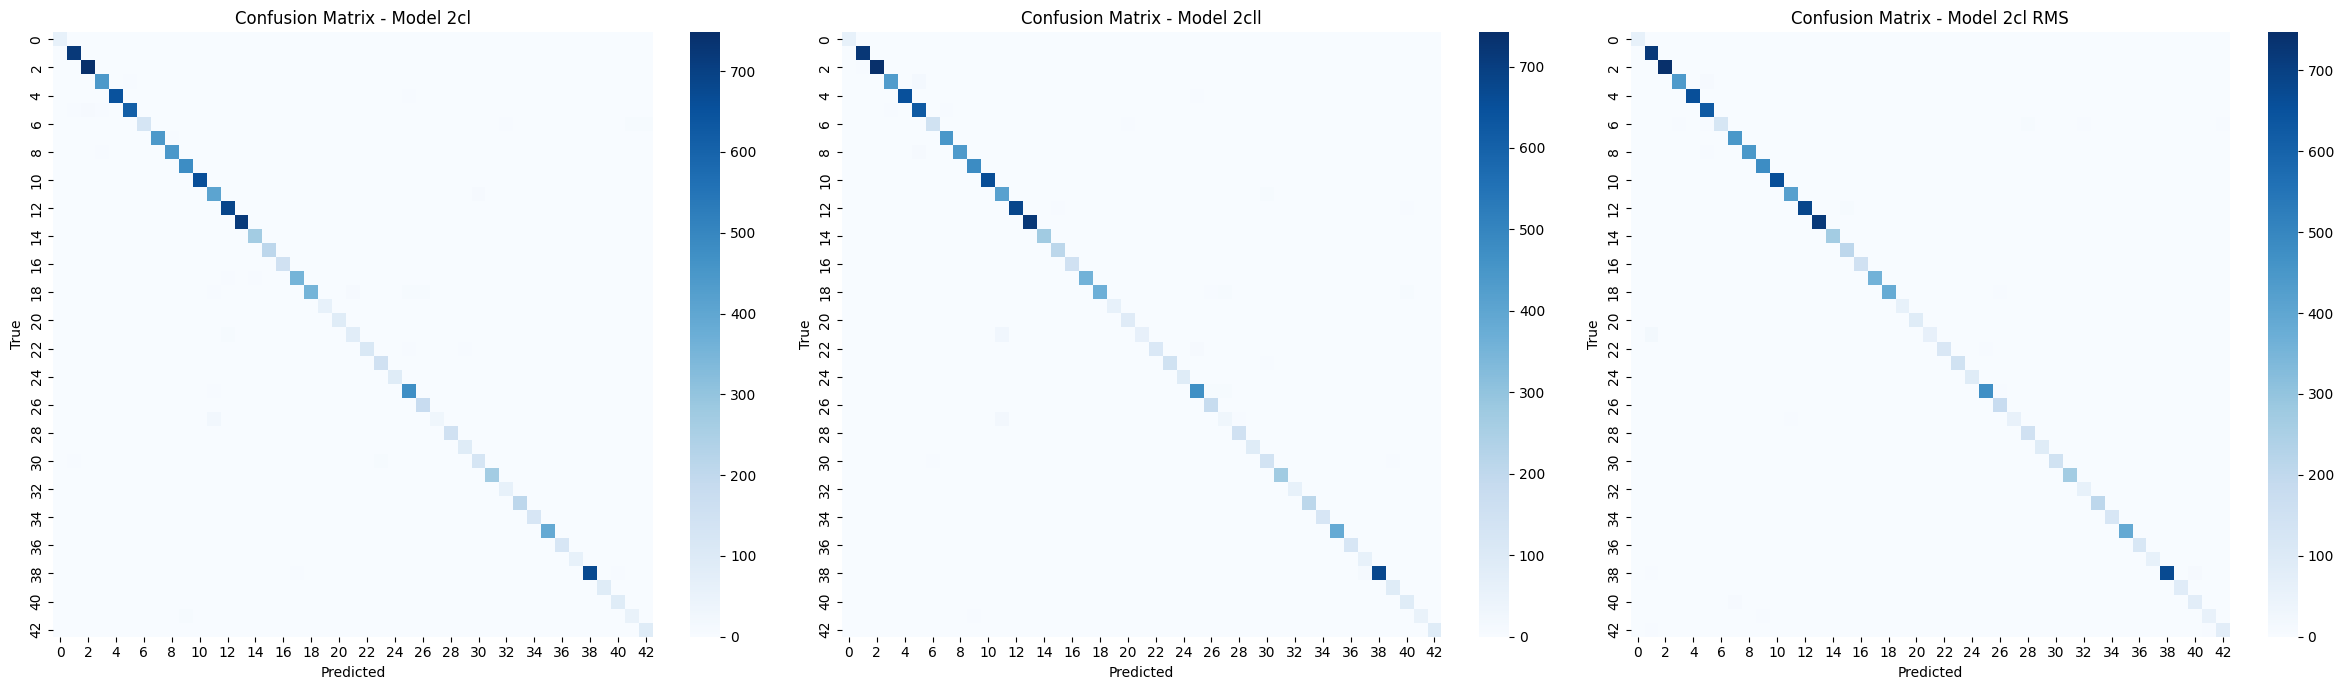

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(cm_2cl, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Model 2cl')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_2cll, cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - Model 2cll')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

sns.heatmap(cm_2cl_RMS, cmap='Blues', ax=axes[2])
axes[2].set_title('Confusion Matrix - Model 2cl RMS')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()


This function help plot the normalised confusion matrices

In [121]:
def plot_confusion_matrix_normalized(y_true, y_pred, model_name):
    num_classes = len(class_names)
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        normalize='true'
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', vmin=0, vmax=1)
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Then we print them using the previous function

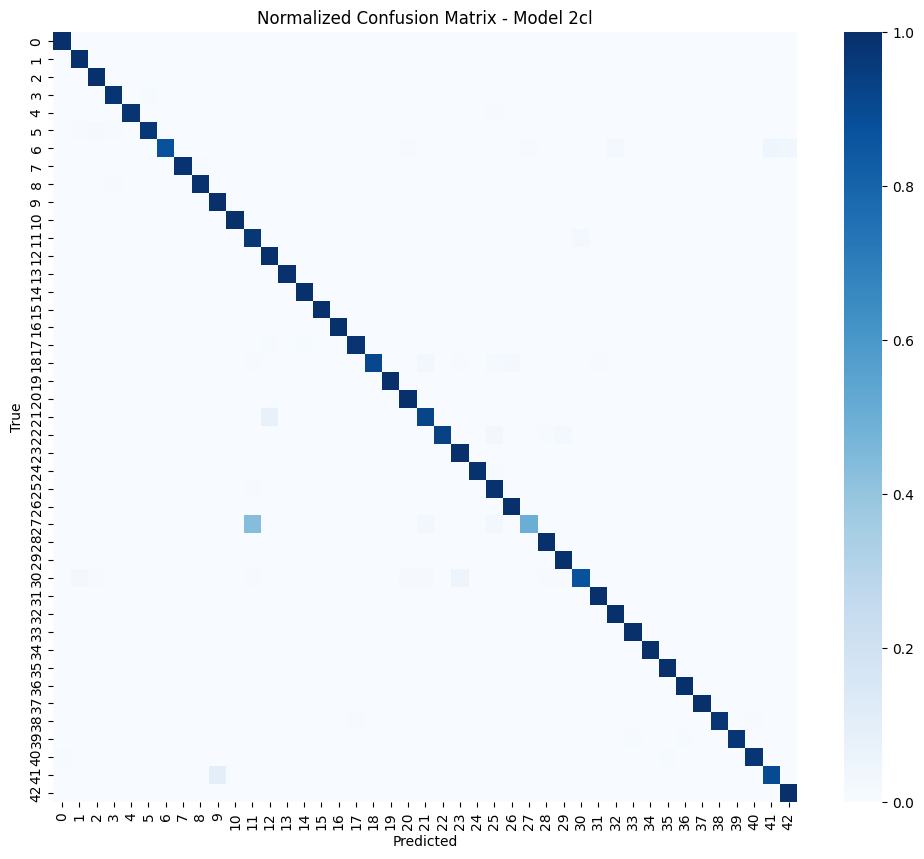

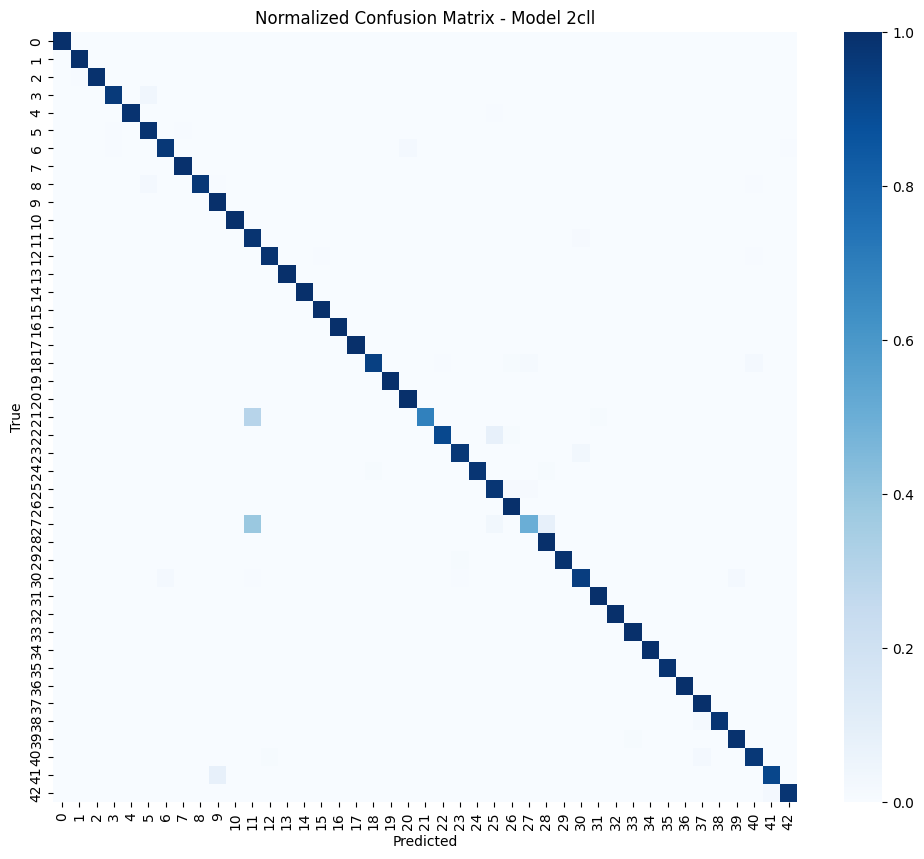

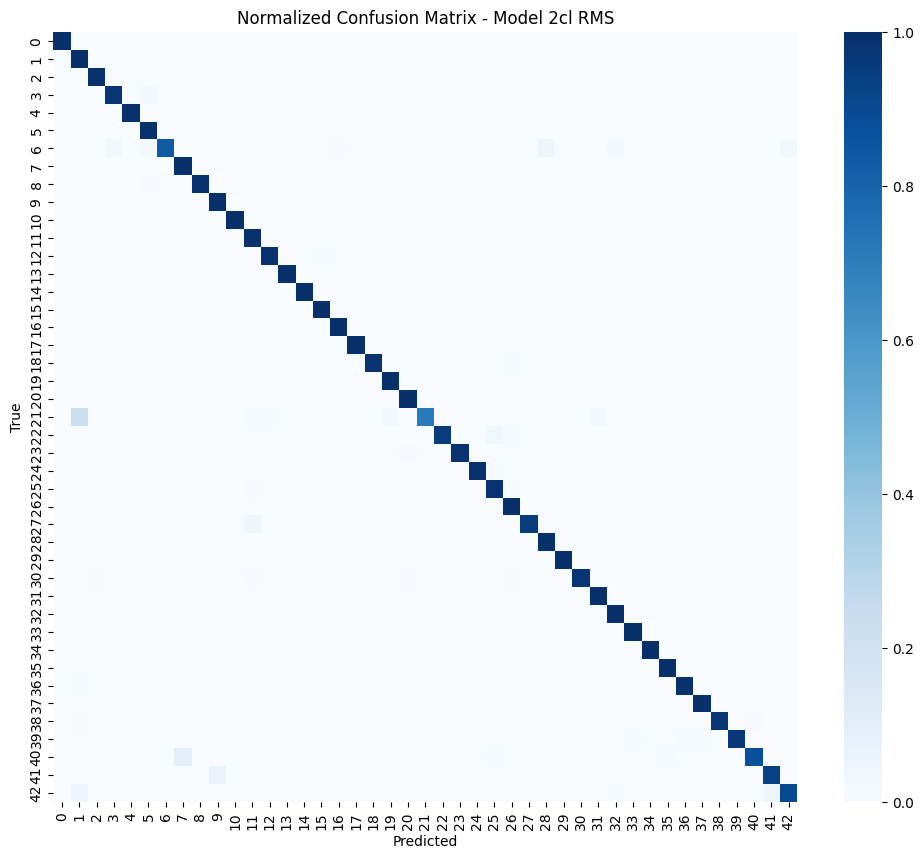

In [122]:
plot_confusion_matrix_normalized(y_test_true, y_pred_2cl, 'Model 2cl')
plot_confusion_matrix_normalized(y_test_true, y_pred_2cll, 'Model 2cll')
plot_confusion_matrix_normalized(y_test_true, y_pred_2cl_RMS, 'Model 2cl RMS')


This creates classification-report dataframes for the final selected models

In [ ]:
def get_report_df(y_true, y_pred, model_name):
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=[class_names[i] for i in range(num_classes)],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose().iloc[:-3, :]
    report_df = report_df.reset_index().rename(columns={"index": "Class"})
    report_df["Model"] = model_name

    return report_df
df_report_2cl = get_report_df(y_test_true, y_pred_2cl, "Model 2cl")
df_report_2cll = get_report_df(y_test_true, y_pred_2cll, "Model 2cll")
df_report_2cl_RMS = get_report_df(y_test_true, y_pred_2cl_RMS, "Model 2cl RMS")


This plots the f1, precison, recall for each class

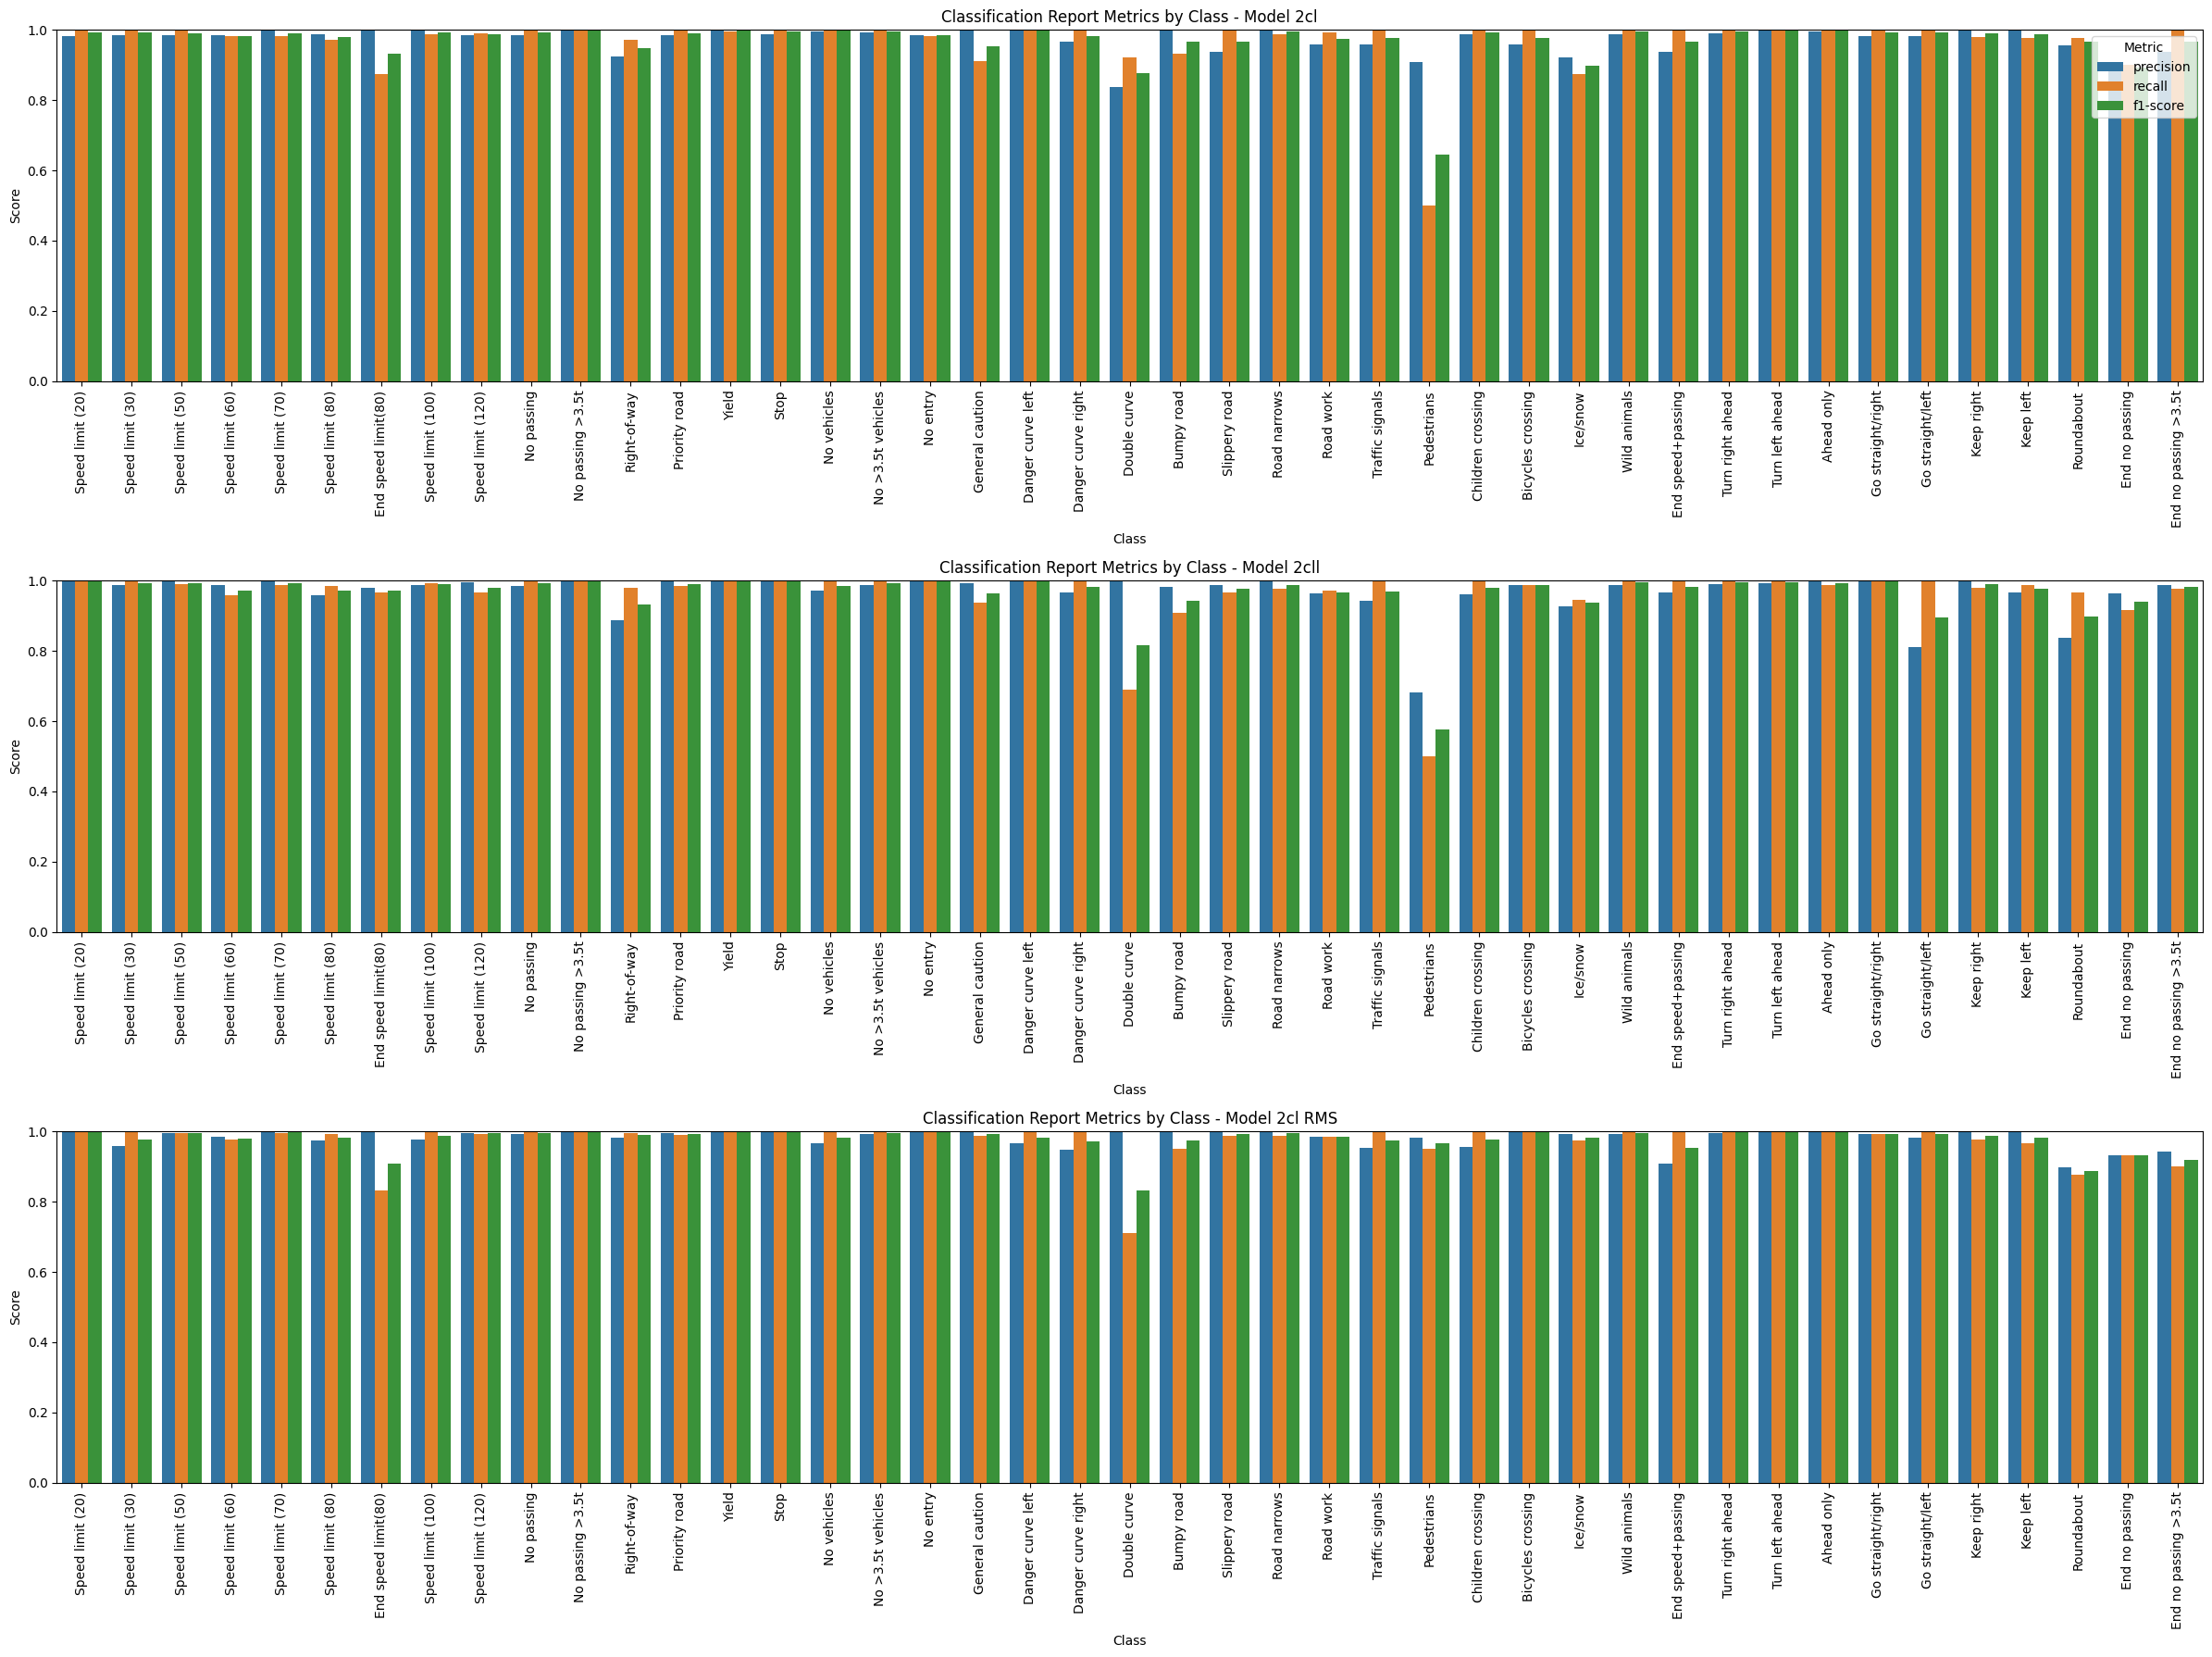

In [158]:
# Plot precision, recall and F1-score for each class
def plot_classification_report_bars(df_report, model_name, ax, show_legend=True):
    df_melt = df_report.melt(
        id_vars=["Class", "Model"],
        value_vars=["precision", "recall", "f1-score"],
        var_name="Metric",
        value_name="Score"
    )

    sns.barplot(
        data=df_melt,
        x="Class",
        y="Score",
        hue="Metric",
        ax=ax
    )
    ax.set_title(f"Classification Report Metrics by Class - {model_name}")
    ax.set_ylabel("Score")
    ax.set_xlabel("Class")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=90)

    if not show_legend and ax.legend_ is not None:
        ax.legend_.remove()
fig, axes = plt.subplots(3, 1, figsize=(24, 18))

plot_classification_report_bars(df_report_2cl, "Model 2cl", axes[0], show_legend=True)
plot_classification_report_bars(df_report_2cll, "Model 2cll", axes[1], show_legend=False)
plot_classification_report_bars(df_report_2cl_RMS, "Model 2cl RMS", axes[2], show_legend=False)

plt.tight_layout()
plt.show()

This function plots class-level precision, recall and F1-score as heatmaps

In [ ]:
def plot_classification_report_heatmap(df_report, model_name, ax):
    sns.heatmap(df_report[['precision', 'recall', 'f1-score']], cmap='YlGnBu', cbar=True, ax=ax)
    ax.set_title(f'Classification Report Heatmap - {model_name}')
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Classes')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

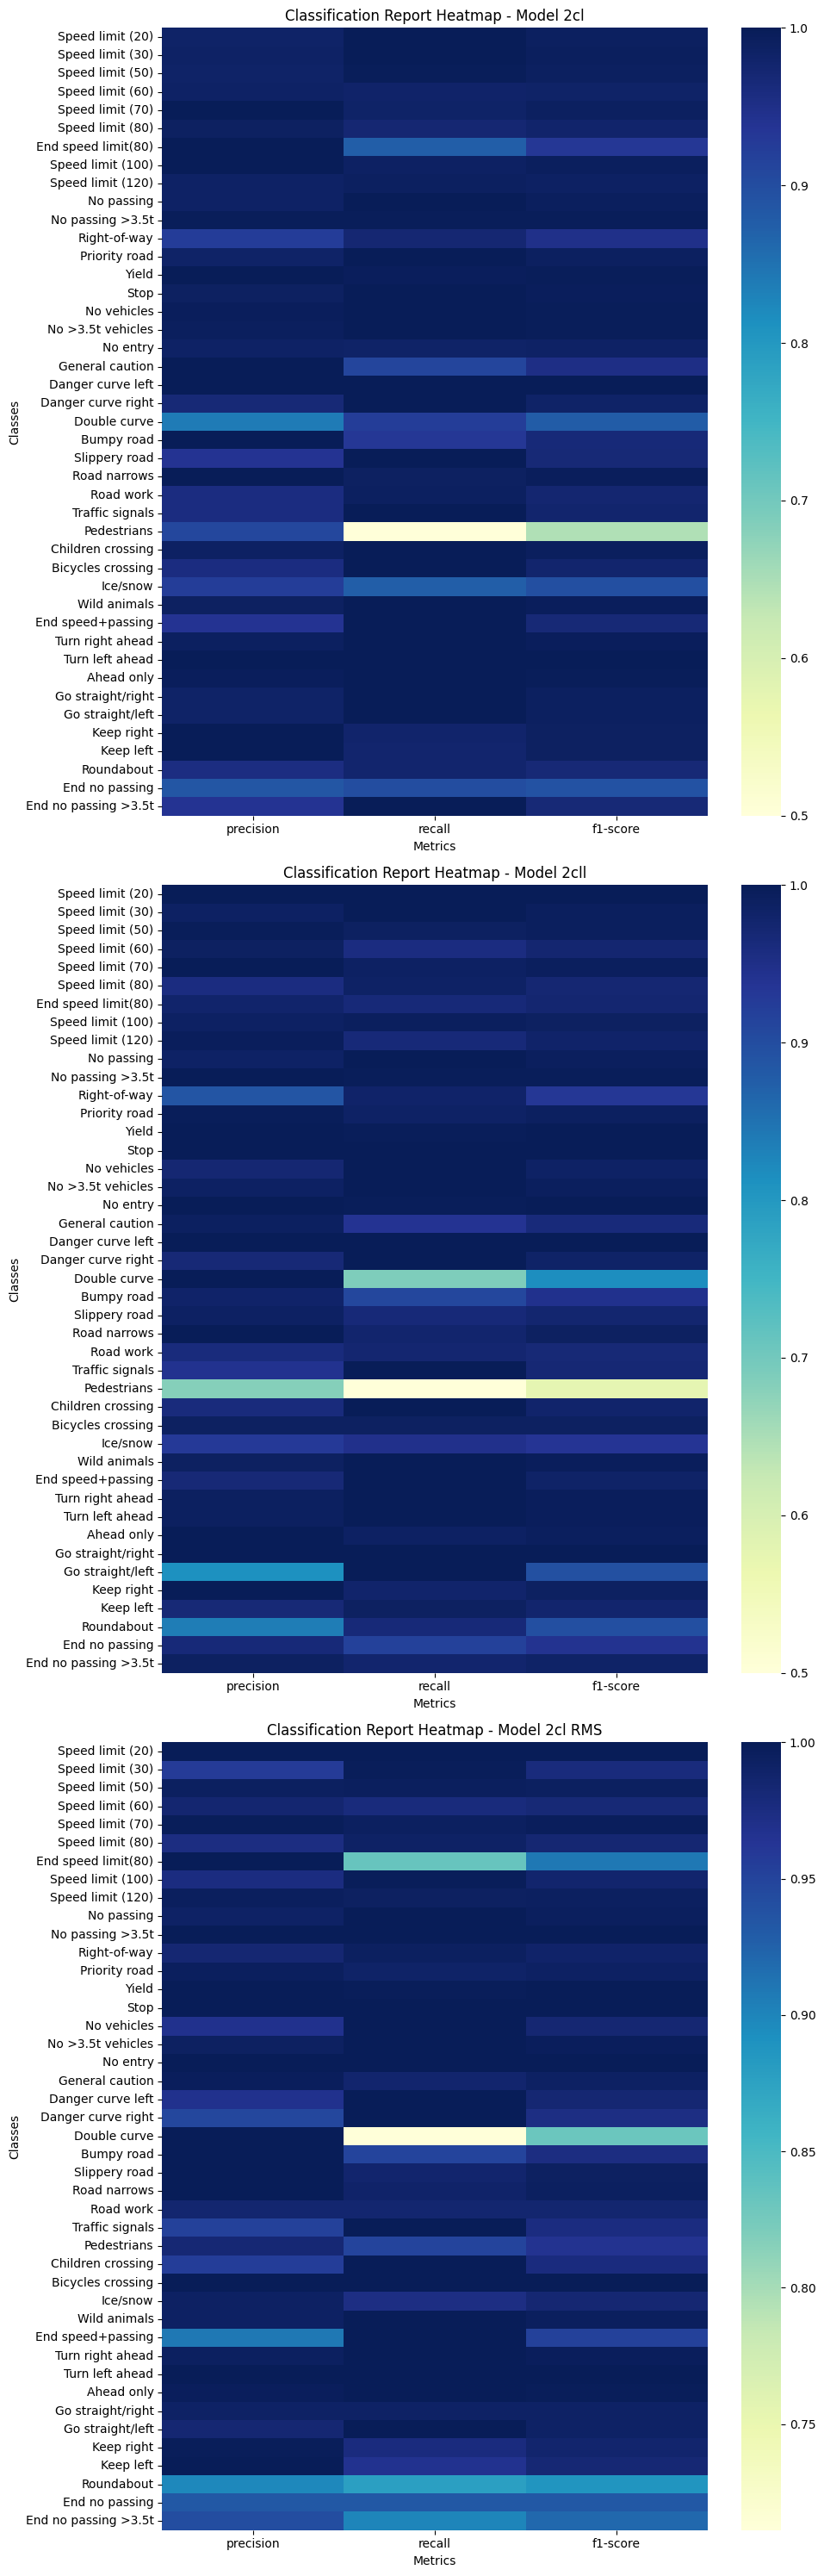

In [131]:
fig, axes = plt.subplots(3, 1, figsize=(10, 30))

plot_classification_report_heatmap(df_report_2cl, 'Model 2cl', axes[0])
plot_classification_report_heatmap(df_report_2cll, 'Model 2cll', axes[1])
plot_classification_report_heatmap(df_report_2cl_RMS, 'Model 2cl RMS', axes[2])

plt.tight_layout()
plt.show()


This code does the same thing, but it orders them horizontally and with only one legend (this code was did only to save the image for the report and to save space there)

In [161]:
def plot_classification_report_heatmap(df_report, model_name, ax, cbar=False, cbar_ax=None):
    heatmap_data = df_report[['precision', 'recall', 'f1-score']]

    sns.heatmap(
        heatmap_data,
        annot=False,
        cmap='YlGnBu',
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax
    )

    ax.set_title(f'Classification Report Heatmap - {model_name}')
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Classes')


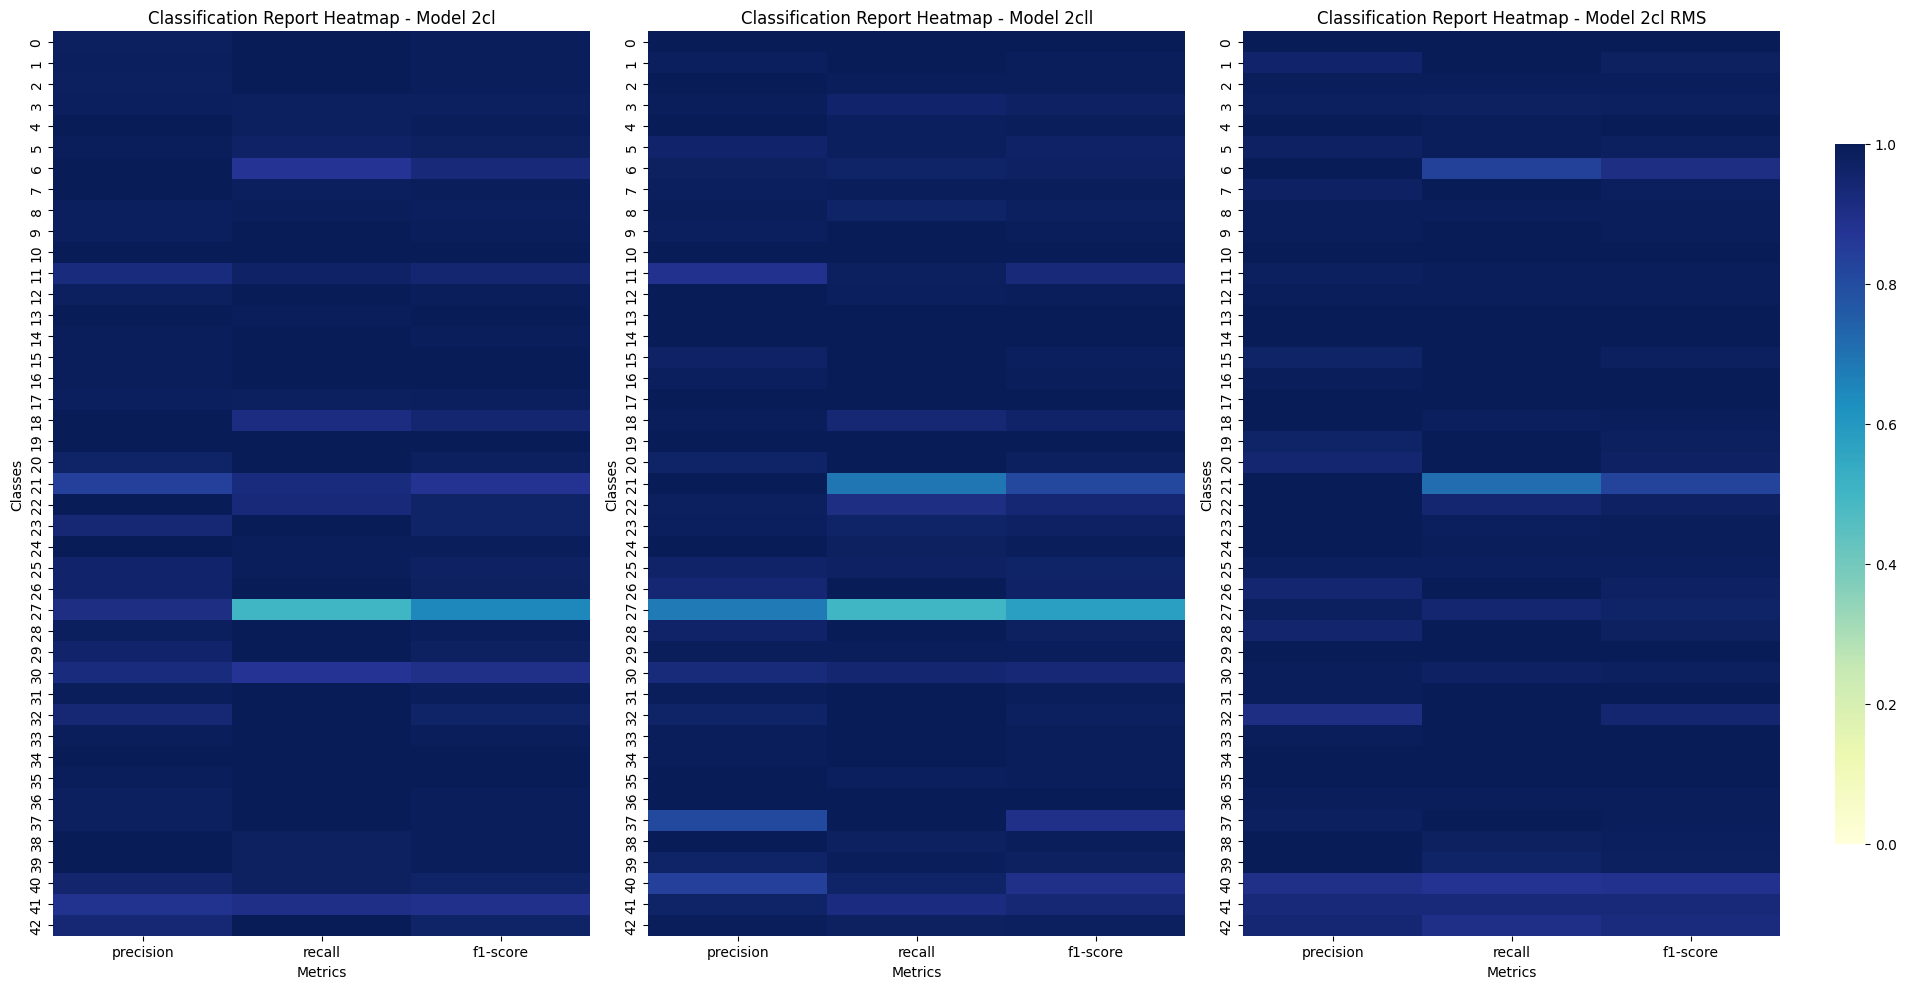

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# add one shared colorbar axis on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])

plot_classification_report_heatmap(df_report_2cl, 'Model 2cl', axes[0], cbar=False)
plot_classification_report_heatmap(df_report_2cll, 'Model 2cll', axes[1], cbar=False)
plot_classification_report_heatmap(df_report_2cl_RMS, 'Model 2cl RMS', axes[2], cbar=True, cbar_ax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()



This code shows a small visual sample of the model’s test predictions.

In [ ]:
sample_total = min(9, len(X_test))
sample_indices = random.sample(range(len(X_test)), sample_total)

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for ax in axes:
    ax.axis('off')

for plot_index, sample_index in enumerate(sample_indices):
    ax = axes[plot_index]
    ax.imshow(X_test[sample_index])
    true_idx = y_test_true[sample_index]
    pred_idx = y_pred_1[sample_index]
    confidence = np.max(y_pred_prob_1[sample_index])
    title_color = 'green' if pred_idx == true_idx else 'red'
    ax.set_title(f'P: {class_names[pred_idx]}\nT: {class_names[true_idx]}\nConf: {confidence:.2f}',
                 color=title_color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


This is a reusable version of the previous sample-prediction plot, but it is useful for qualitative error analysis. It lets you visually check whether the model’s predictions make sense on real test images

In [ ]:
sample_total = min(9, len(X_test))
sample_indices = random.sample(range(len(X_test)), sample_total)

def plot_sample_predictions(X_test, y_true, y_pred, y_pred_prob, model_name, sample_indices):
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    for ax in axes:
        ax.axis('off')

    for plot_index, sample_index in enumerate(sample_indices):
        ax = axes[plot_index]
        ax.imshow(X_test[sample_index])

        true_idx = y_true[sample_index]
        pred_idx = y_pred[sample_index]
        confidence = np.max(y_pred_prob[sample_index])

        title_color = 'green' if pred_idx == true_idx else 'red'
        ax.set_title(
            f'P: {class_names[pred_idx]}\nT: {class_names[true_idx]}\nConf: {confidence:.2f}',
            color=title_color,
            fontsize=8
        )
        ax.axis('off')

    fig.suptitle(f'Sample Predictions - {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

This plots them to see exactly

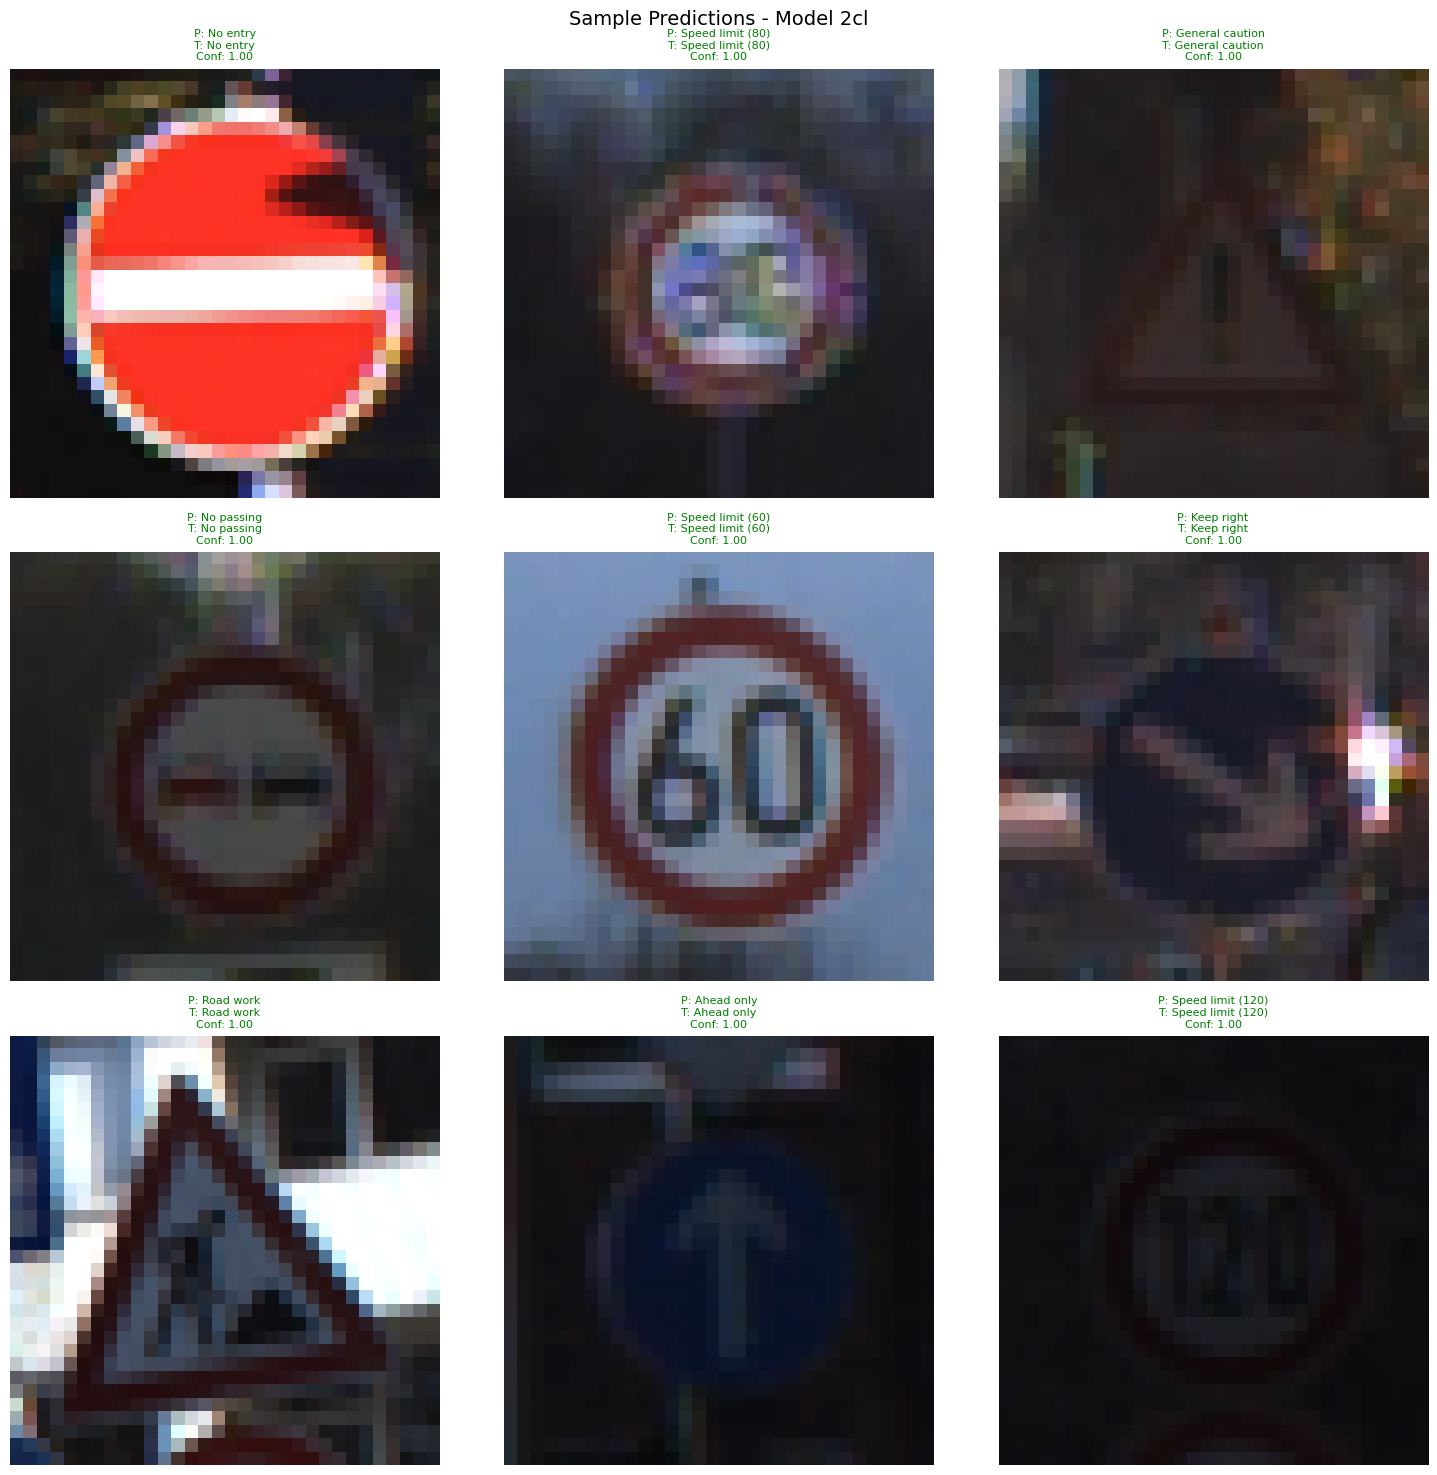

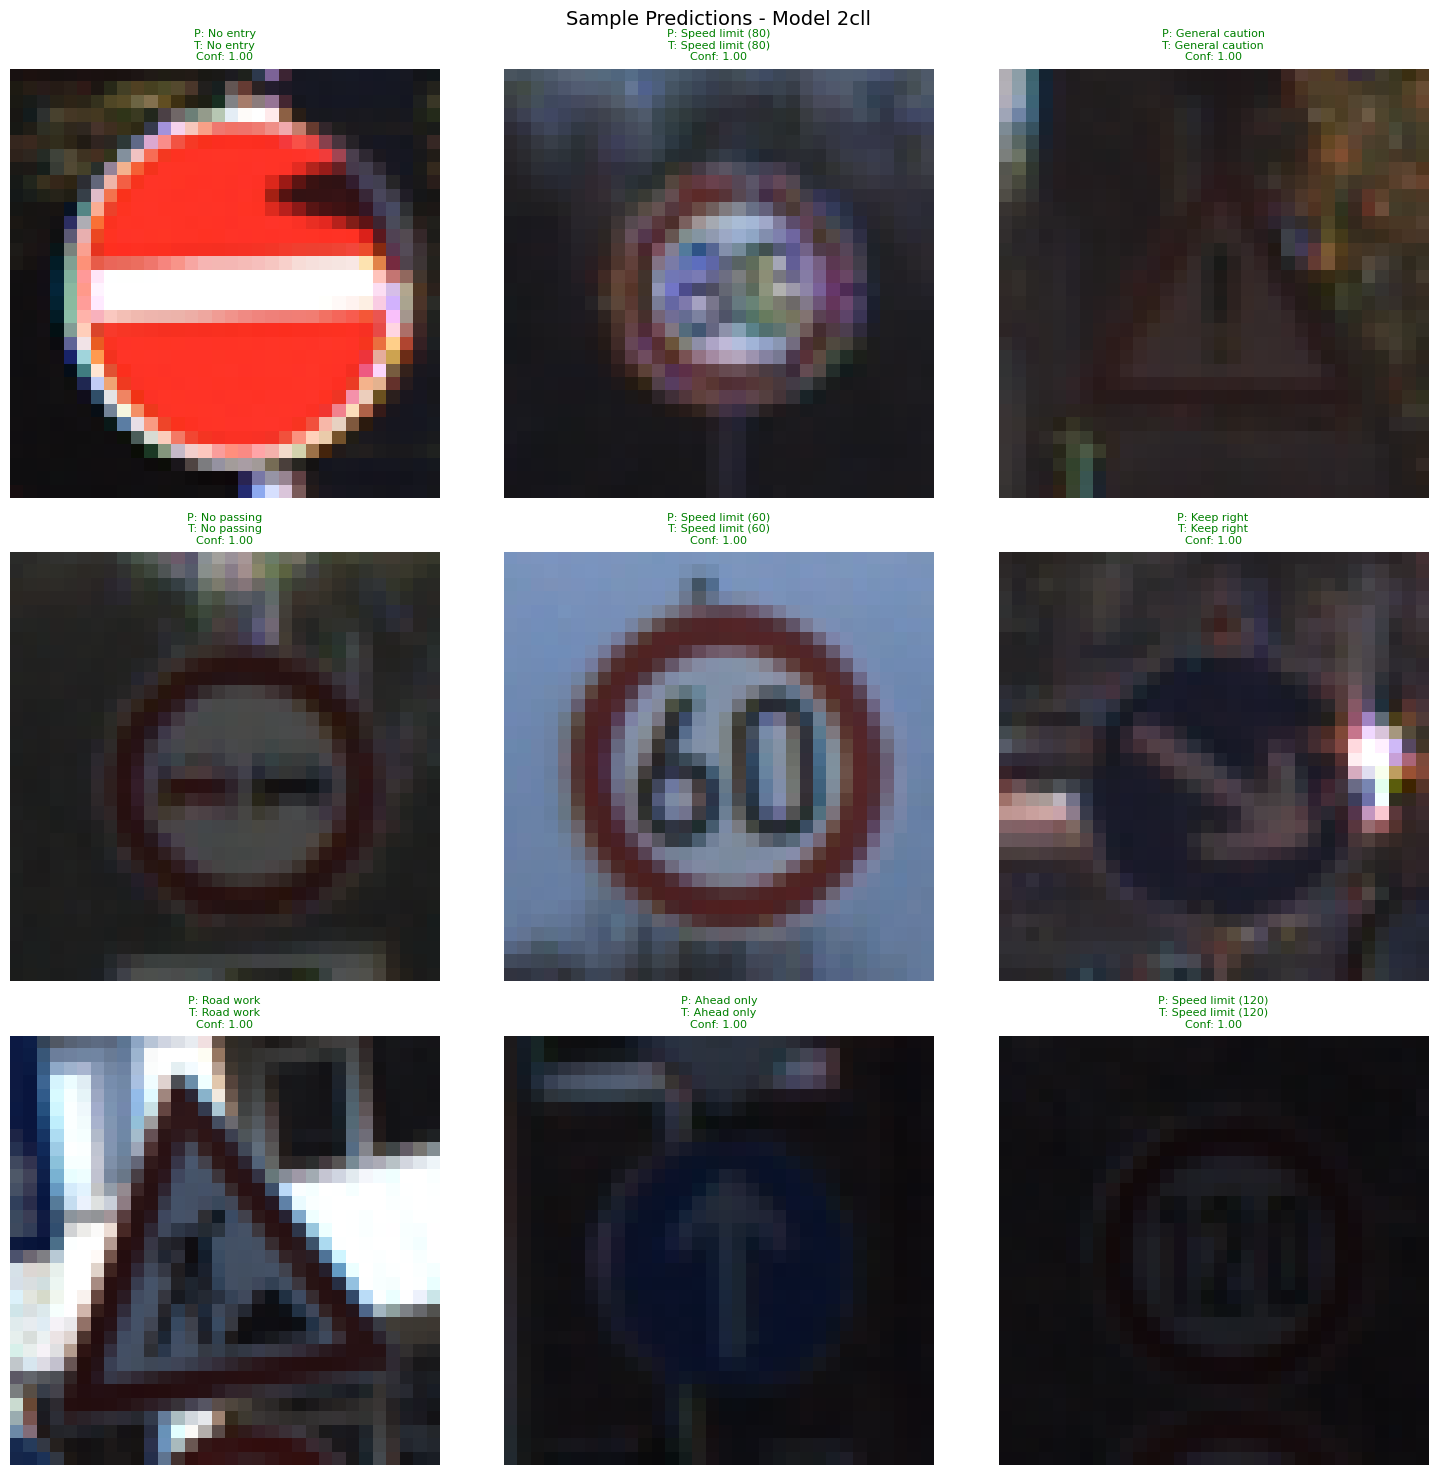

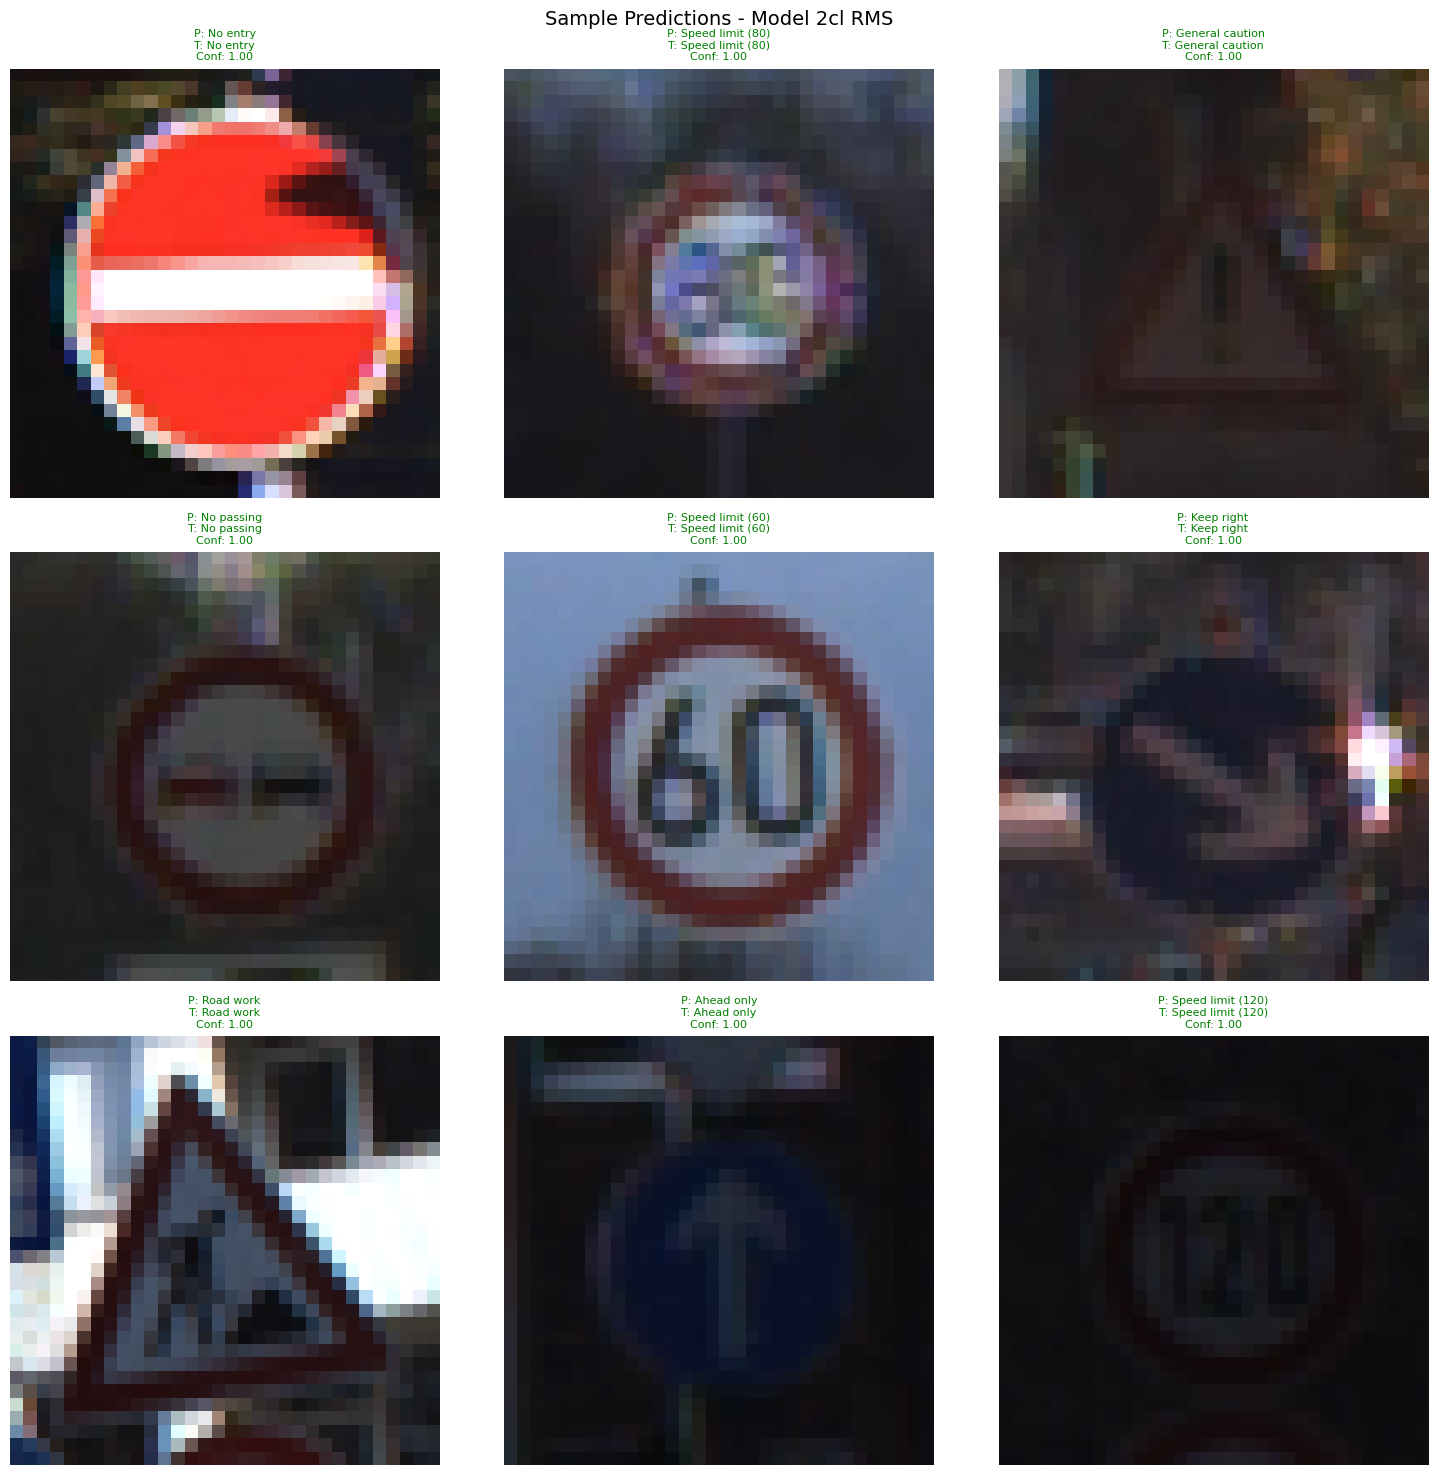

In [135]:
plot_sample_predictions(X_test, y_test_true, y_pred_2cl, y_pred_prob_2cl, 'Model 2cl', sample_indices)
plot_sample_predictions(X_test, y_test_true, y_pred_2cll, y_pred_prob_2cll, 'Model 2cll', sample_indices)
plot_sample_predictions(X_test, y_test_true, y_pred_2cl_RMS, y_pred_prob_2cl_RMS, 'Model 2cl RMS', sample_indices)

# Thank You